In [13]:
#!pip install arch

In [14]:
#!pip install rpy2

In [ ]:
#!pip install pydynpd

In [168]:
#import subprocess
#import sys

#print("="*70)
#print("УСТАНОВКА ПАКЕТА linearmodels")
#print("="*70)

#try:
    #subprocess.check_call([sys.executable, "-m", "pip", "install", "linearmodels", "-q"])
    #print("✓ Пакет linearmodels успешно установлен")
#except Exception as e:
   # print(f"✗ Ошибка при установке: {e}")

# Проверка импорта
#try:
   # from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
    #print("✓ Импорт linearmodels успешен")
#except ImportError as e:
    #print(f"✗ Ошибка импорта: {e}")

УСТАНОВКА ПАКЕТА linearmodels
✓ Пакет linearmodels успешно установлен
✓ Импорт linearmodels успешен


In [743]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import arch.unitroot as au
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import friedmanchisquare
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.tsa.ardl import ARDL, ardl_select_order
import sys
import os
os.environ['RPY2_CFFI_MODE'] = 'ABI'
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson
import itertools
import math
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from scipy.stats import chi2, f
from statsmodels.tsa.x13 import x13_arima_analysis
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, globalenv
from rpy2.robjects.packages import importr, isinstalled
from rpy2.robjects.conversion import localconverter
import rpy2.rinterface_lib.callbacks
import os

In [744]:
###############################
    #ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
###############################
df_reg = pd.read_excel('База данных_рег и фед показатели.xlsx', skiprows=1, sheet_name = 'data')
df_RF = pd.read_excel('База данных_рег и фед показатели.xlsx', skiprows=1, sheet_name = 'data_RF')
households_structure = pd.read_excel('База_соц эконом неоднор регионов.xlsx', skiprows=1, sheet_name = 'Фин пол ДХ')
households_loans = pd.read_excel('База_соц эконом неоднор регионов.xlsx', sheet_name = 'КЖН (рейтинг)')
funds_coefficient = pd.read_excel('База_соц эконом неоднор регионов.xlsx', skiprows=2, sheet_name = 'Коэф фондов')

In [745]:
# Преобразование даты 
df_RF['Date'] = pd.to_datetime(df_RF['Date'])
df_RF = df_RF.sort_values('Date')
df_reg['Date'] = pd.to_datetime(df_reg['Date'])
df_reg = df_reg.sort_values(['Num_reg','Date'])

In [746]:
df_reg.head()

,Num_reg,Region,Date,D_top5_rozn,Cred_nagr,Zakred,Zadolg_Fl,Zadolg_Mort,Zadolg_ConsCred,Zadolg_Fl_mom,...,New_Loans_Progr_DOMRF_mom,New_Loans_Progr_mom,Int_Rate_FL,Int_Rate_Mort,Int_Rate_ConsCred,Int_Rate_Progr_DOMRF,Int_Rate_Progr,Fin_Dostup,LTV_proksi,Credit_impulse
0,1,Белгородская область,2019-02-01,0.720458,0.327789,45.661946,1.252168e+08,43448108.04,81768732.08,1.008396,...,NaN,NaN,13.637133,9.822596,14.919927,5.714816,NaN,24.878034,0.727030,-2.177079
1,1,Белгородская область,2019-03-01,0.721863,0.332653,46.108548,1.268473e+08,44177731.36,82669591.94,1.302566,...,-50.982514,NaN,13.764491,10.119091,15.090566,5.688207,NaN,25.004848,0.674074,0.715653
2,1,Белгородская область,2019-04-01,0.724760,0.336535,46.483680,1.288264e+08,44889934.26,83936427.82,1.561441,...,-65.329715,NaN,13.988365,10.431156,15.022465,5.503984,NaN,24.937820,0.347733,1.734442
3,1,Белгородская область,2019-05-01,0.724868,0.341271,47.069180,1.315857e+08,45651657.65,85934076.07,2.141982,...,220.452622,NaN,13.975779,10.629171,14.943737,5.496568,NaN,24.870805,0.677991,2.897391
4,1,Белгородская область,2019-06-01,0.724590,0.342186,47.580388,1.339479e+08,46227839.22,87720098.33,1.794755,...,40.154704,NaN,14.197338,10.697008,15.138499,5.278560,NaN,24.803802,0.655120,2.214858


In [747]:
df_RF.head()

,Num_reg,Region,Date,CAR_Indicator,D_Progr_mort,ROISFIX,exc_rate,exc_rate_diff,Bonds_Rate_Correct_5Y,Inflation_Expectations,Nominal_Percent_Rate,Ent_conf_ind_mining,Ent_conf_ind_manufactoring,Covid_dum,Sank_dum
0,0,РОССИЯ,2019-02-01,0.146150,0.013333,7.652000,65.810525,-0.702019,0.274500,10.362319,6.5,0,-2,0,0
1,0,РОССИЯ,2019-03-01,0.146823,0.014805,7.611500,65.092257,-0.718268,0.292500,10.144295,6.5,1,-2,0,0
2,0,РОССИЯ,2019-04-01,0.146778,0.017586,7.630000,64.603105,-0.489152,0.316818,9.004132,6.5,3,-2,0,0
3,0,РОССИЯ,2019-05-01,0.145500,0.019362,7.635556,64.818706,0.215601,0.295714,9.416996,6.5,1,-1,0,0
4,0,РОССИЯ,2019-06-01,0.144882,0.027592,7.524737,64.169050,-0.649656,0.197895,9.280142,6.5,1,-1,0,0


In [748]:
###############################
# Подсчет ожидаемого уровня инфляции за 12 месяцев
###############################

def calculate_expected_inflation_12m(df, date_col='Date', 
                                     inflation_col='Inflation_Expectations'):
    """
    Расчет ожидаемой инфляции на 12 месяцев вперед
    
    Если данные на следующий год отсутствуют (последние 12 месяцев),
    используются значения текущего года в качестве прокси
    """
    df_calc = df.copy()

    df_calc['Month'] = df_calc[date_col].dt.month
    df_calc['Year'] = df_calc[date_col].dt.year

    # i_1 = количество месяцев до конца текущего года
    df_calc['i_1'] = 12 - df_calc['Month'] + 1
    
    # i_2 = количество месяцев до конца следующего года
    df_calc['i_2'] = 12 + df_calc['i_1']
    
    print(df_calc[['Date', 'Month', 'i_1', 'i_2']].head(10).to_string())

    # Ожидаемая инфляция на конец текущего года
    df_calc['pi_current_year'] = df_calc[inflation_col]
    
    # Ожидаемая инфляция на конец следующего года
    df_calc['pi_next_year'] = df_calc[inflation_col].shift(-12)
    
    # Если нет данных на следующий год, используем значение текущего года в качестве прокси
    df_calc['pi_next_year'] = df_calc['pi_next_year'].fillna(df_calc['pi_current_year'])
    
    print(df_calc[[date_col, 'pi_current_year', 'pi_next_year']].head(15).to_string())

    # Расчет ожидаемой инфляции на 12 месяцев
    df_calc['Expected_Inflation_12m'] = (
        df_calc['pi_current_year'] + 
        (12 - df_calc['i_1']) * (df_calc['pi_next_year'] - df_calc['pi_current_year']) / 12
    )
    
    return df_calc

In [749]:
df_RF = calculate_expected_inflation_12m(
                df_RF,
                date_col='Date',
                inflation_col='Inflation_Expectations')
df_RF = df_RF.drop(['i_1', 'i_2'], axis=1)

        Date  Month  i_1  i_2
0 2019-02-01      2   11   23
1 2019-03-01      3   10   22
2 2019-04-01      4    9   21
3 2019-05-01      5    8   20
4 2019-06-01      6    7   19
5 2019-07-01      7    6   18
6 2019-08-01      8    5   17
7 2019-09-01      9    4   16
8 2019-10-01     10    3   15
9 2019-11-01     11    2   14
         Date  pi_current_year  pi_next_year
0  2019-02-01        10.362319      8.150424
1  2019-03-01        10.144295      7.855319
2  2019-04-01         9.004132      7.845972
3  2019-05-01         9.416996      8.881323
4  2019-06-01         9.280142      9.262617
5  2019-07-01         9.344961      9.262617
6  2019-08-01         9.304511      9.262617
7  2019-09-01         9.033333      9.262617
8  2019-10-01         8.740602      9.643911
9  2019-11-01         8.468619     10.122776
10 2019-12-01         8.115546     11.327586
11 2020-01-01         8.887833     10.482833
12 2020-02-01         8.150424      9.862550
13 2020-03-01         7.855319     10.06

In [750]:
df_RF.tail()

,Num_reg,Region,Date,CAR_Indicator,D_Progr_mort,ROISFIX,exc_rate,exc_rate_diff,Bonds_Rate_Correct_5Y,Inflation_Expectations,Nominal_Percent_Rate,Ent_conf_ind_mining,Ent_conf_ind_manufactoring,Covid_dum,Sank_dum,Month,Year,pi_current_year,pi_next_year,Expected_Inflation_12m
76,0,РОССИЯ,2025-06-01,0.135517,0.784009,20.065789,78.667861,-1.536970,-0.000500,13.100000,8.0,0,2,0,1,6,2025,13.100000,13.100000,13.100000
77,0,РОССИЯ,2025-07-01,0.139986,0.803585,18.681739,78.772404,0.104543,0.115652,12.674419,8.0,0,0,0,1,7,2025,12.674419,12.674419,12.674419
78,0,РОССИЯ,2025-08-01,0.132801,0.810183,17.728095,80.127786,1.355382,0.188095,12.713483,8.0,-1,0,0,1,8,2025,12.713483,12.713483,12.713483
79,0,РОССИЯ,2025-09-01,0.132940,0.776143,16.821818,82.970805,2.843018,0.104545,13.250000,8.0,-2,-2,0,1,9,2025,13.250000,13.250000,13.250000
80,0,РОССИЯ,2025-10-01,0.133273,0.732748,16.687143,81.010305,-1.960500,-0.196667,12.150000,8.0,-3,-2,0,1,10,2025,12.150000,12.150000,12.150000


In [751]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ДАННЫЕ
###############################
descriptive_df = df_RF[[
    'ROISFIX',
    'Expected_Inflation_12m',
    'Nominal_Percent_Rate',
    'Ent_conf_ind_mining',
    'Ent_conf_ind_manufactoring'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ДАННЫЕ
                            Среднее  Медиана  ст. откл.   Мин.   Макс.
ROISFIX                      10.666    7.630      5.781  4.141  22.114
Expected_Inflation_12m       11.527   11.632      1.572  8.223  17.288
Nominal_Percent_Rate          6.562    6.500      0.857  5.500   8.000
Ent_conf_ind_mining          -0.222    0.000      2.156 -6.000   3.000
Ent_conf_ind_manufactoring   -0.346   -1.000      3.399 -9.000   5.000


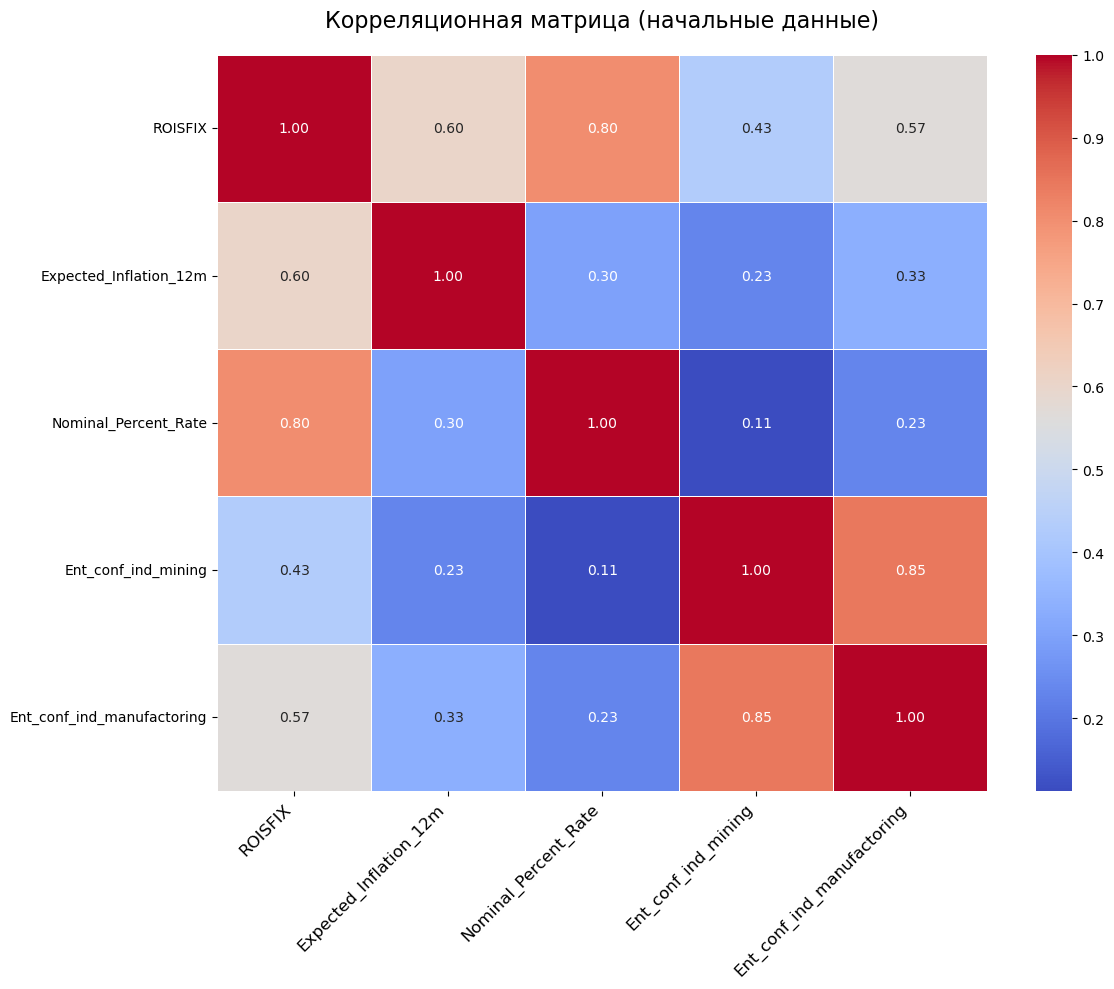

In [752]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ИСХОДНЫЕ ДАННЫЕ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (начальные данные)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [753]:
###############################
    #VIF-анализ - начальные данные
###############################

vif_variables = [
    'ROISFIX',
    'Expected_Inflation_12m',
    'Nominal_Percent_Rate',
    'Ent_conf_ind_mining',
    'Ent_conf_ind_manufactoring'
]
df_vif = df_RF[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ДАННЫЕ")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ДАННЫЕ
                  Variable      VIF
                   ROISFIX 8.158937
      Nominal_Percent_Rate 4.535009
Ent_conf_ind_manufactoring 4.486045
       Ent_conf_ind_mining 3.700143
    Expected_Inflation_12m 1.984513


In [754]:
##############################
# Тест Фридмана на сезонность
##############################

variables_for_analysis = [
    ('ROISFIX', 'Ключевая ставка (ROISFIX)'),
    ('Expected_Inflation_12m', 'Ожидаемая инфляция на 12м'),
    ('Nominal_Percent_Rate', 'Номинальная ставка'),
    ('Ent_conf_ind_mining', 'Индекс уверенности (добыча)'),
    ('Ent_conf_ind_manufactoring', 'Индекс уверенности (обработка)')
]

def friedman_seasonality_test(df, date_col='Date', value_col='Variable', 
                              test_name=None):

    df_test = df.copy()
    df_test['Month'] = df_test[date_col].dt.month
    df_test['Year'] = df_test[date_col].dt.year
    
    # Перевод в таблицу: года × месяцы
    pivot_data = df_test.pivot(index='Year', columns='Month', values=value_col)
    
    # Удаляем строки с NaN (неполные годы)
    pivot_data = pivot_data.dropna()
    
    # Проверяем достаточность данных
    if len(pivot_data) < 3:
        print(f"{test_name}: Недостаточно лет ({len(pivot_data)}), минимум 3")
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': np.nan,
            'p_value': np.nan,
            'has_seasonality': np.nan,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': 'Недостаточно данных'
        }
    
    try:
        # Тест Фридмана
        stat, p_value = friedmanchisquare(*[pivot_data[m].values for m in pivot_data.columns])
        
        # Определяем наличие сезонности
        has_seasonality = p_value < 0.05
        
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': stat,
            'p_value': p_value,
            'has_seasonality': has_seasonality,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': None
        }
    
    except Exception as e:
        print(f"Ошибка для {test_name}: {str(e)}")
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': np.nan,
            'p_value': np.nan,
            'has_seasonality': np.nan,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': str(e)
        }



In [755]:
# Применяем тест

friedman_results = []

for var_col, var_name in variables_for_analysis:
    if var_col in df_RF.columns:
        result = friedman_seasonality_test(df_RF, date_col='Date', 
                                          value_col=var_col, 
                                          test_name=var_name)
        if result:
            friedman_results.append(result)

# Сохраняем результаты Фридмана
friedman_summary = pd.DataFrame([
    {
        'Variable': r['variable'],
        'Chi_Squared': r['chi_squared'],
        'P_Value': r['p_value'],
        'Has_Seasonality': r['has_seasonality'],
        'N_Years': r['n_years'],
        'N_Months': r['n_months']
    } 
    for r in friedman_results
])

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА")
print("="*80)
print(friedman_summary.to_string(index=False))

    



РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                      Variable  Chi_Squared  P_Value  Has_Seasonality  N_Years  N_Months
     Ключевая ставка (ROISFIX)     4.456963 0.954598            False        5        12
     Ожидаемая инфляция на 12м    23.861538 0.013330             True        5        12
            Номинальная ставка    11.863422 0.373996            False        5        12
   Индекс уверенности (добыча)    21.098503 0.032365             True        5        12
Индекс уверенности (обработка)    27.583969 0.003747             True        5        12


[Ent_conf_ind_mining] Период: 2019-02, наблюдений: 81
[Ent_conf_ind_mining] Сезонная корректировка выполнена
[Ent_conf_ind_mining] Снижение волатильности: 8.6%
[Ent_conf_ind_manufactoring] Период: 2019-02, наблюдений: 81
[Ent_conf_ind_manufactoring] Сезонная корректировка выполнена
[Ent_conf_ind_manufactoring] Снижение волатильности: 5.8%

ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ В DF_RF
Ent_conf_ind_mining_adj: 81 не-NaN значений
Ent_conf_ind_mining_trend: 81 не-NaN значений
Ent_conf_ind_mining_seasonal: 81 не-NaN значений
Ent_conf_ind_manufactoring_adj: 81 не-NaN значений
Ent_conf_ind_manufactoring_trend: 81 не-NaN значений
Ent_conf_ind_manufactoring_seasonal: 81 не-NaN значений

Всего добавлено столбцов: 6

СВОДКА РЕЗУЛЬТАТОВ СЕЗОННОЙ КОРРЕКЦИИ
                    Переменная Снижение волатильности До корректировки После корректировки
   Индекс уверенности (добыча)                   8.6%           2.1564              1.9712
Индекс уверенности (обработка)                   5.8%           3.3991 

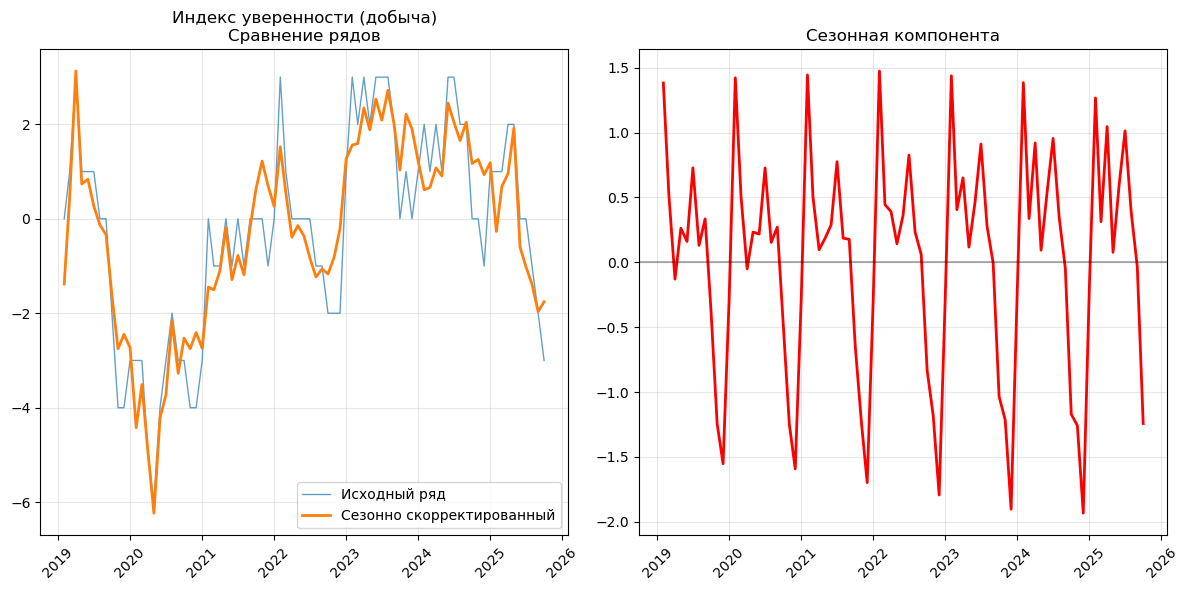

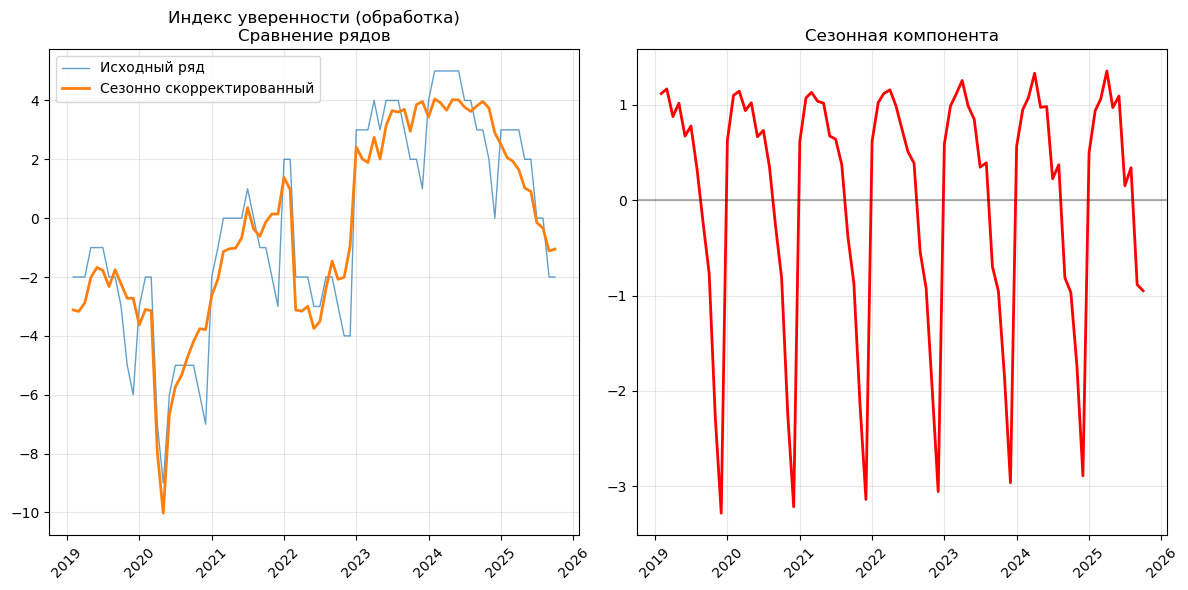

Все скорректированные ряды добавлены в df_RF
Столбцы с суффиксами: _adj, _trend, _seasonal


In [756]:
# Путь к бинарнику X-13
X13_PATH = 'C:\\Program Files (x86)\\x13as'   # либо каталог с бинарником, либо сам бинарник [web:2][web:8]

# Проверка, что бинарник доступен
if not os.path.exists(X13_PATH):
    raise FileNotFoundError(f"X-13 binary not found at {X13_PATH}")

# Если X13_PATH — полный путь к бинарнику, берем его директорию для x12path
x13_dir = X13_PATH if os.path.isdir(X13_PATH) else os.path.dirname(X13_PATH)

# Переменные для сезонной корректировки
x13_variables = {
     #'Expected_Inflation_12m': 'Ожидаемая инфляция (12м)',
    'Ent_conf_ind_mining': 'Индекс уверенности (добыча)',
    'Ent_conf_ind_manufactoring': 'Индекс уверенности (обработка)'
}

os.makedirs("x13_logs", exist_ok=True)

for col, name in x13_variables.items():
    try:
        # Подготовка данных
        series_data = df_RF[['Date', col]].copy().dropna()

        if len(series_data) < 24:
            print(f"[{col}] Недостаточно данных ({len(series_data)} наблюдений). Пропуск.")
            continue

        # Устанавливаем Date как индекс и приводим к месячной частоте (start of month)
        temp_df = series_data.set_index('Date').asfreq('MS').dropna()

        if len(temp_df) < 24:
            print(f"[{col}] Менее 24 наблюдений после asfreq/NA. Пропуск.")
            continue

        print(f"[{col}] Период: {temp_df.index[0].year}-{temp_df.index[0].month:02d}, "
              f"наблюдений: {len(temp_df)}")

        # Вектор значений как pandas.Series с DatetimeIndex
        ts = temp_df[col]

        # Запуск X-13 (аналог seasonal::seas с SEATS)
        # По умолчанию statsmodels использует X-11; для полной эквивалентности
        # с SEATS могут потребоваться кастомные спецификации, но базовая декомпозиция
        # (seasadj, trend, irregular) доступна сразу. [web:2][web:8]
        res = x13_arima_analysis(
            endog=ts,
            x12path=x13_dir,
            prefer_x13=True,
            outlier=True,
            trading=False,
            print_stdout=False
        )

        # Компоненты (названия полей см. в документации statsmodels.X13ArimaAnalysisResult) [web:2][web:8]
        # seasadj: seasonally adjusted
        # trend: trend-cycle
        # irregular: остаток; сезонная компонента = исходный ряд - seasadj
        adj = res.seasadj
        trend = res.trend
        seas = ts - adj

        # Приведение к общему датафрейму
        df_RF.set_index('Date', inplace=True)

        # Создаем столбцы и заполняем только на пересечении индексов
        common_index = df_RF.index.intersection(ts.index)

        df_RF.loc[common_index, f'{col}_adj'] = adj.reindex(common_index)
        df_RF.loc[common_index, f'{col}_trend'] = trend.reindex(common_index)
        df_RF.loc[common_index, f'{col}_seasonal'] = seas.reindex(common_index)

        # Возвращаем индекс Date в столбец (если нужно)
        df_RF.reset_index(inplace=True)

        # Расчет эффективности (снижение волатильности)
        mask = ~df_RF[f'{col}_adj'].isna()
        if mask.any():
            original_std = df_RF.loc[mask, col].std()
            adj_std = df_RF.loc[mask, f'{col}_adj'].std()
            reduction = 100 * (1 - adj_std / original_std) if original_std > 0 else 0

            print(f"[{col}] Сезонная корректировка выполнена")
            print(f"[{col}] Снижение волатильности: {reduction:.1f}%")

    except Exception as e:
        print(f"[{col}] Ошибка: {e}")


# === ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ ===
print("\n" + "="*60)
print("ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ В DF_RF")
print("="*60)

added_columns = []
for col in x13_variables.keys():
    for suffix in ['_adj', '_trend', '_seasonal']:
        new_col = f'{col}{suffix}'
        if new_col in df_RF.columns:
            added_columns.append(new_col)
            non_na_count = df_RF[new_col].notna().sum()
            print(f"{new_col}: {non_na_count} не-NaN значений")

print(f"\nВсего добавлено столбцов: {len(added_columns)}")

# === СВОДКА РЕЗУЛЬТАТОВ ===
print("\n" + "="*60)
print("СВОДКА РЕЗУЛЬТАТОВ СЕЗОННОЙ КОРРЕКЦИИ")
print("="*60)

results_summary = []
for col, name in x13_variables.items():
    adj_col = f'{col}_adj'
    if adj_col in df_RF.columns:
        mask = ~df_RF[adj_col].isna()
        if mask.any():
            original_data = df_RF.loc[mask, col]
            adj_data = df_RF.loc[mask, adj_col]

            original_std = original_data.std()
            adj_std = adj_data.std()
            reduction = 100 * (1 - adj_std / original_std) if original_std > 0 else 0

            results_summary.append({
                'Переменная': name,
                'Снижение волатильности': f"{reduction:.1f}%",
                'До корректировки': f"{original_std:.4f}",
                'После корректировки': f"{adj_std:.4f}"
            })

if results_summary:
    summary_df = pd.DataFrame(results_summary)
    print(summary_df.to_string(index=False))

# === ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ===
print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*60)

for col, name in x13_variables.items():
    adj_col = f'{col}_adj'
    if adj_col in df_RF.columns:
        plot_data = df_RF[['Date', col, adj_col]].dropna(subset=[adj_col])

        if len(plot_data) > 0:
            plt.figure(figsize=(12, 6))

            plt.subplot(1, 2, 1)
            plt.plot(plot_data['Date'], plot_data[col],
                     label='Исходный ряд', alpha=0.7, linewidth=1)
            plt.plot(plot_data['Date'], plot_data[adj_col],
                     label='Сезонно скорректированный', linewidth=2)
            plt.title(f'{name}\nСравнение рядов')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.xticks(rotation=45)

            plt.subplot(1, 2, 2)
            seasonal_col = f'{col}_seasonal'
            if seasonal_col in df_RF.columns:
                seasonal_data = df_RF[['Date', seasonal_col]].dropna(subset=[seasonal_col])
                plt.plot(seasonal_data['Date'], seasonal_data[seasonal_col],
                         color='red', linewidth=2)
                plt.title('Сезонная компонента')
                plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
                plt.grid(alpha=0.3)
                plt.xticks(rotation=45)

            plt.tight_layout()
            plt.show()

print("Все скорректированные ряды добавлены в df_RF")
print("Столбцы с суффиксами: _adj, _trend, _seasonal")

In [757]:
df_RF.head()

,Date,Num_reg,Region,CAR_Indicator,D_Progr_mort,ROISFIX,exc_rate,exc_rate_diff,Bonds_Rate_Correct_5Y,Inflation_Expectations,...,Year,pi_current_year,pi_next_year,Expected_Inflation_12m,Ent_conf_ind_mining_adj,Ent_conf_ind_mining_trend,Ent_conf_ind_mining_seasonal,Ent_conf_ind_manufactoring_adj,Ent_conf_ind_manufactoring_trend,Ent_conf_ind_manufactoring_seasonal
0,2019-02-01,0,РОССИЯ,0.146150,0.013333,7.652000,65.810525,-0.702019,0.274500,10.362319,...,2019,10.362319,8.150424,10.177994,-1.382376,0.881282,1.382376,-3.118780,-3.161703,1.118780
1,2019-03-01,0,РОССИЯ,0.146823,0.014805,7.611500,65.092257,-0.718268,0.292500,10.144295,...,2019,10.144295,7.855319,9.762799,0.479521,0.865987,0.520479,-3.167966,-2.871824,1.167966
2,2019-04-01,0,РОССИЯ,0.146778,0.017586,7.630000,64.603105,-0.489152,0.316818,9.004132,...,2019,9.004132,7.845972,8.714592,3.129961,0.828293,-0.129961,-2.877533,-2.571156,0.877533
3,2019-05-01,0,РОССИЯ,0.145500,0.019362,7.635556,64.818706,0.215601,0.295714,9.416996,...,2019,9.416996,8.881323,9.238438,0.737152,0.748407,0.262848,-2.018658,-2.289942,1.018658
4,2019-06-01,0,РОССИЯ,0.144882,0.027592,7.524737,64.169050,-0.649656,0.197895,9.280142,...,2019,9.280142,9.262617,9.272840,0.839312,0.604160,0.160688,-1.672649,-2.049704,0.672649


In [758]:
##############################
# Тест Фридмана для рядов, скорректированных на сезонность
##############################

variables_for_analysis = [
    ('Ent_conf_ind_mining_adj', 'Индекс уверенности (добыча)'),
    ('Ent_conf_ind_manufactoring_adj', 'Индекс уверенности (обработка)')
]

def friedman_seasonality_test(df, date_col='Date', value_col='Variable', 
                              test_name=None):

    df_test = df.copy()
    df_test['Month'] = df_test[date_col].dt.month
    df_test['Year'] = df_test[date_col].dt.year
    
    # Перевод в таблицу: года × месяцы
    pivot_data = df_test.pivot(index='Year', columns='Month', values=value_col)
    
    # Удаляем строки с NaN (неполные годы)
    pivot_data = pivot_data.dropna()
    
    # Проверяем достаточность данных
    if len(pivot_data) < 3:
        print(f"{test_name}: Недостаточно лет ({len(pivot_data)}), минимум 3")
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': np.nan,
            'p_value': np.nan,
            'has_seasonality': np.nan,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': 'Недостаточно данных'
        }
    
    try:
        # Тест Фридмана
        stat, p_value = friedmanchisquare(*[pivot_data[m].values for m in pivot_data.columns])
        
        # Определяем наличие сезонности
        has_seasonality = p_value < 0.05
        
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': stat,
            'p_value': p_value,
            'has_seasonality': has_seasonality,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': None
        }
    
    except Exception as e:
        print(f"Ошибка для {test_name}: {str(e)}")
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': np.nan,
            'p_value': np.nan,
            'has_seasonality': np.nan,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': str(e)
        }



In [759]:
# Применяем тест

friedman_results = []

for var_col, var_name in variables_for_analysis:
    if var_col in df_RF.columns:
        result = friedman_seasonality_test(df_RF, date_col='Date', 
                                          value_col=var_col, 
                                          test_name=var_name)
        if result:
            friedman_results.append(result)

# Сохраняем результаты Фридмана
friedman_summary = pd.DataFrame([
    {
        'Variable': r['variable'],
        'Chi_Squared': r['chi_squared'],
        'P_Value': r['p_value'],
        'Has_Seasonality': r['has_seasonality'],
        'N_Years': r['n_years'],
        'N_Months': r['n_months']
    } 
    for r in friedman_results
])

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА")
print("="*60)
print(friedman_summary.to_string(index=False))

    



РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                      Variable  Chi_Squared  P_Value  Has_Seasonality  N_Years  N_Months
   Индекс уверенности (добыча)     7.492308 0.757930            False        5        12
Индекс уверенности (обработка)    10.692308 0.469389            False        5        12



РАСЧЕТ ИНДЕКСА ПРЕДПРИНИМАТЕЛЬСКОЙ УВЕРЕННОСТИ

Корреляция итогового индекса с компонентами:
  Итоговый - Добыча: 0.9244
  Итоговый - Обработка: 0.9781


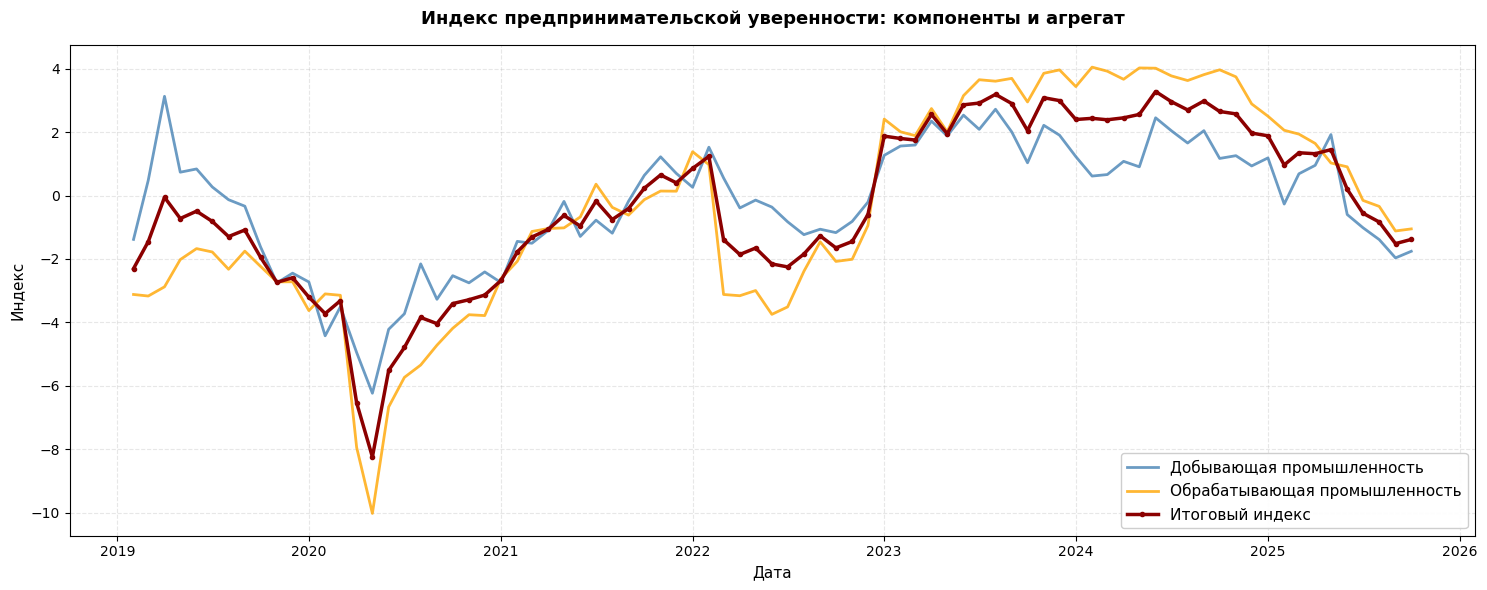

In [760]:
print("\n" + "="*60)
print("РАСЧЕТ ИНДЕКСА ПРЕДПРИНИМАТЕЛЬСКОЙ УВЕРЕННОСТИ")
print("="*60)

# Веса по доле в структуре промышленности РФ (2023 г.)
weights = {
    'mining': 0.47,              # Добывающая промышленность: 47%
    'manufacturing': 0.53        # Обрабатывающая промышленность: 53%
}

mining_col = 'Ent_conf_ind_mining_adj'
manuf_col = 'Ent_conf_ind_manufactoring_adj'

# Проверяем доступность
mining_available = mining_col in df_RF.columns
manuf_available = manuf_col in df_RF.columns


if mining_available and manuf_available:
    # Берем скорректированные данные
    mining_series = df_RF[mining_col].copy()
    manuf_series = df_RF[manuf_col].copy()
    
    # Расчет взвешенного среднего
    df_RF['Ent_conf_ind_total'] = (
        weights['mining'] * mining_series + 
        weights['manufacturing'] * manuf_series
    )    

# Корреляция итогового индекса с компонентами
corr_total_mining = df_RF['Ent_conf_ind_total'].corr(mining_series)
corr_total_manuf = df_RF['Ent_conf_ind_total'].corr(manuf_series)

print(f"\nКорреляция итогового индекса с компонентами:")
print(f"  Итоговый - Добыча: {corr_total_mining:.4f}")
print(f"  Итоговый - Обработка: {corr_total_manuf:.4f}")


fig, ax1 = plt.subplots(figsize=(15, 6))

# График: Компоненты и итоговый индекс
ax1.plot(df_RF['Date'], mining_series, 
         label='Добывающая промышленность', linewidth=2, alpha=0.8, color='steelblue')
ax1.plot(df_RF['Date'], manuf_series, 
         label='Обрабатывающая промышленность', linewidth=2, alpha=0.8, color='orange')
ax1.plot(df_RF['Date'], df_RF['Ent_conf_ind_total'], 
         label='Итоговый индекс', 
         linewidth=2.5, color='darkred', linestyle='-', marker='o', markersize=3)

ax1.set_title('Индекс предпринимательской уверенности: компоненты и агрегат', 
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.95)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylabel('Индекс', fontsize=11)
ax1.set_xlabel('Дата', fontsize=11)
ax1.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

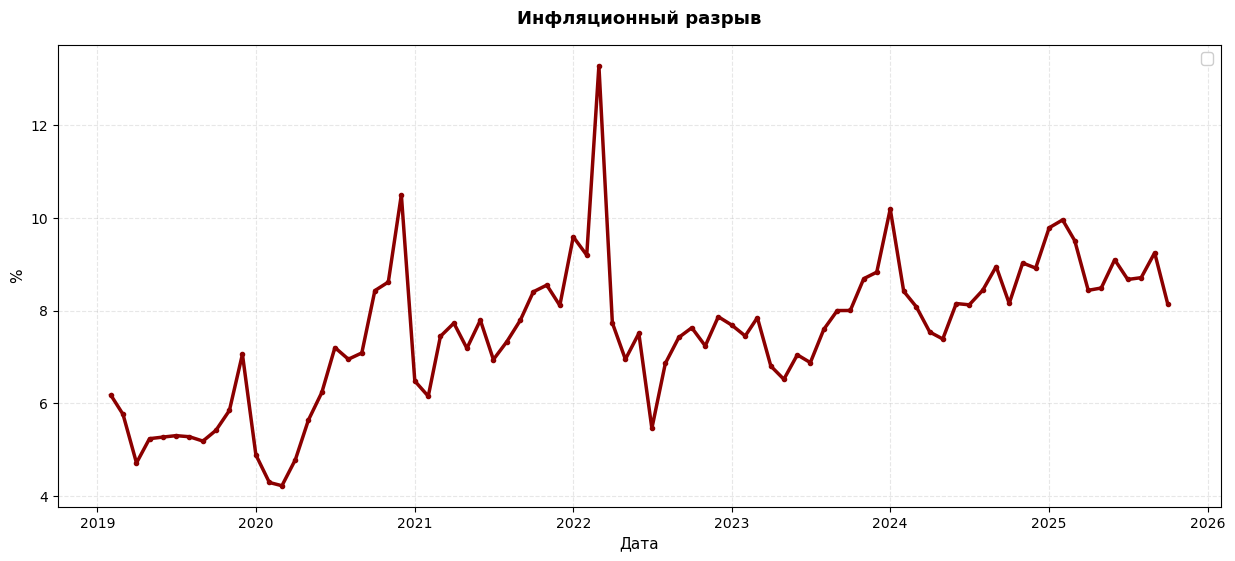

In [761]:
target_inflation = 4.0
df_RF['Inflation_gap'] =  df_RF['Expected_Inflation_12m'] - target_inflation

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df_RF['Date'], df_RF['Inflation_gap'], 
         linewidth=2.5, color='darkred', linestyle='-', marker='o', markersize=3)
ax1.set_title('Инфляционный разрыв', 
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.95)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylabel('%', fontsize=11)
ax1.set_xlabel('Дата', fontsize=11)
ax1.tick_params(axis='both', labelsize=10)

In [762]:
df_taylor = df_RF[['Date','ROISFIX', 'Inflation_gap', 'Nominal_Percent_Rate', 'Ent_conf_ind_total', 'Expected_Inflation_12m']]
df_taylor.head()

,Date,ROISFIX,Inflation_gap,Nominal_Percent_Rate,Ent_conf_ind_total,Expected_Inflation_12m
0,2019-02-01,7.652000,6.177994,6.5,-2.302670,10.177994
1,2019-03-01,7.611500,5.762799,6.5,-1.453647,9.762799
2,2019-04-01,7.630000,4.714592,6.5,-0.054011,8.714592
3,2019-05-01,7.635556,5.238438,6.5,-0.723427,9.238438
4,2019-06-01,7.524737,5.272840,6.5,-0.492028,9.272840



РЕЗУЛЬТАТЫ ТЕСТА ЛЬЮИНГА-БОКСА

1. Ставка ROISFIX
   Тип данных: Исходный
   Наблюдения: 81
   Тестовые лаги: 19
   Ljung-Box статистика: 534.328
   P-значение: 0.000000
   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)
   Ключевые лаги:
     Лаг  1: p=0.000000 ✗
     Лаг  3: p=0.000000 ✗
     Лаг  6: p=0.000000 ✗
     Лаг 12: p=0.000000 ✗

2. Инфляционный разрыв
   Тип данных: Исходный
   Наблюдения: 81
   Тестовые лаги: 19
   Ljung-Box статистика: 170.392
   P-значение: 0.000000
   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)
   Ключевые лаги:
     Лаг  1: p=0.000000 ✗
     Лаг  3: p=0.000000 ✗
     Лаг  6: p=0.000000 ✗
     Лаг 12: p=0.000000 ✗

3. Нейтральная ставка
   Тип данных: Исходный
   Наблюдения: 81
   Тестовые лаги: 19
   Ljung-Box статистика: 407.368
   P-значение: 0.000000
   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)
   Ключевые лаги:
     Лаг  1: p=0.000000 ✗
     Лаг  3: p=0.000000 ✗
     Лаг  6: p=0.000000 ✗
     Лаг 12: p=0.000000 ✗

4. Индекс уверенности
   Тип данных: Исходный
   

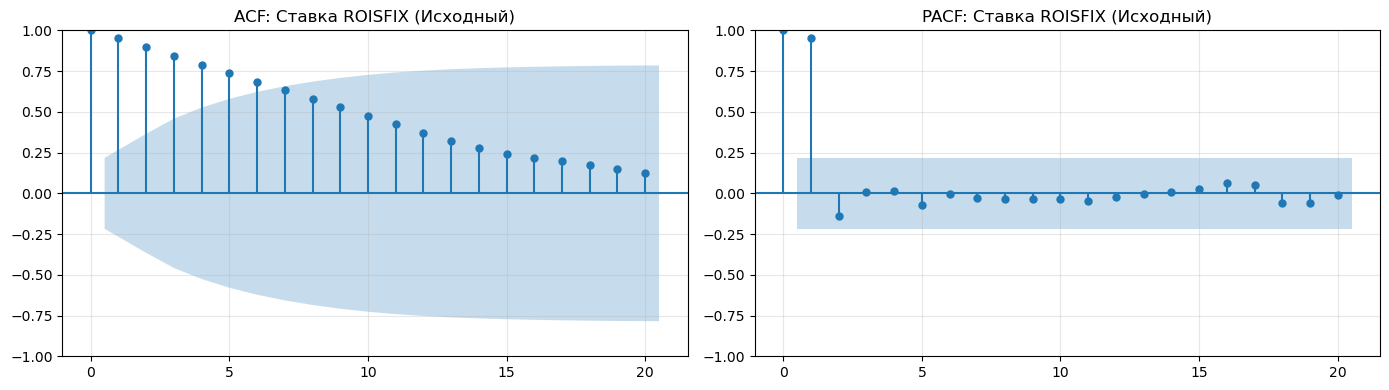

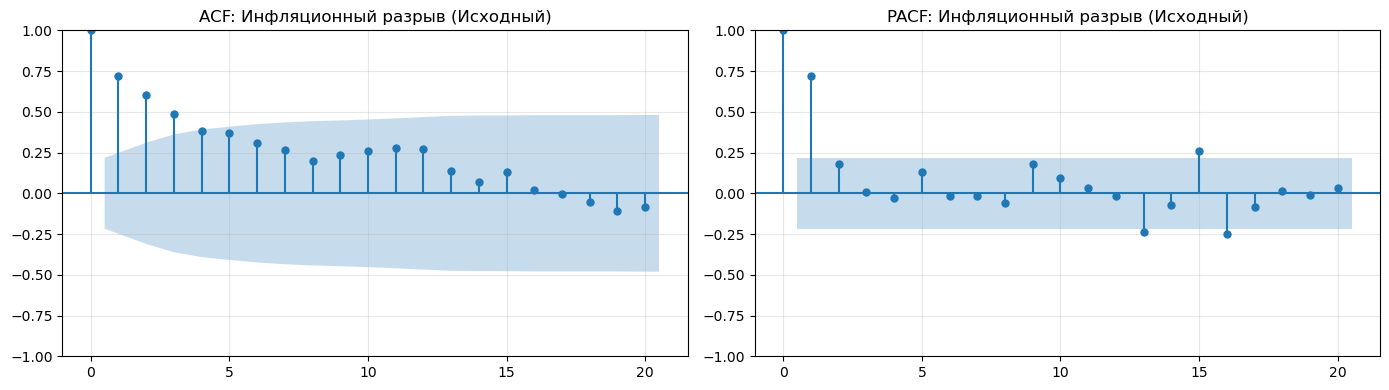

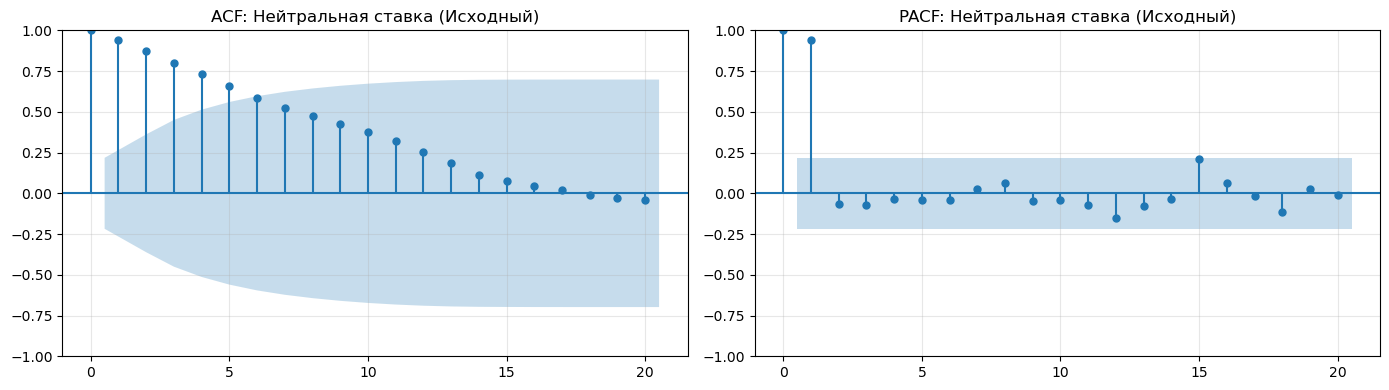

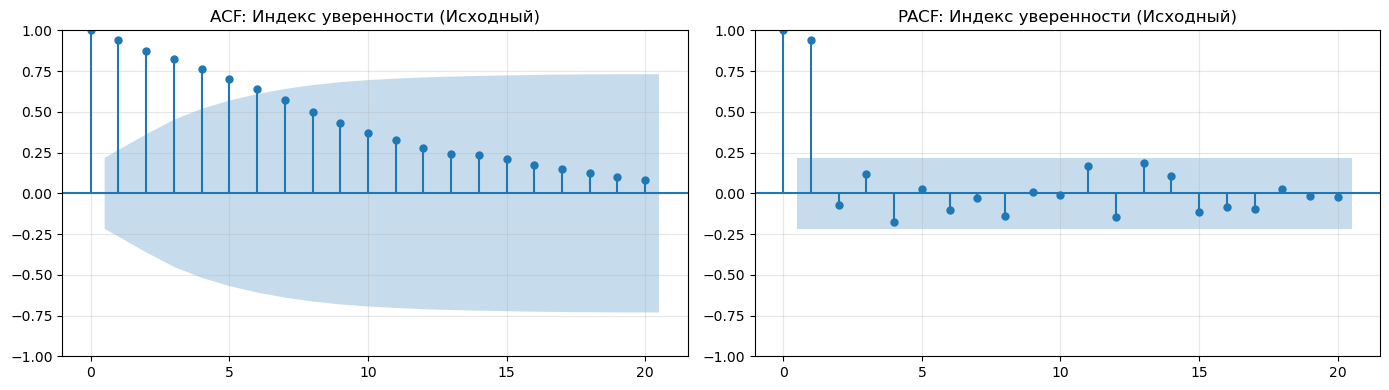

In [763]:
###############################
# Тест Льюинга-Бокса до перехода к разностям
###############################

# === ПЕРЕМЕННЫЕ ДЛЯ ТЕСТА ===
test_variables = {
    'ROISFIX': 'Ставка ROISFIX',
    'Inflation_gap': 'Инфляционный разрыв',
    'Nominal_Percent_Rate': 'Нейтральная ставка',
    'Ent_conf_ind_total': 'Индекс уверенности'
}

# === ФУНКЦИЯ 1: Определяет какой ряд использовать (adj или исходный) ===
def get_series_for_test(df, col_name):
    """
    Проверяет наличие скорректированного ряда (_adj).
    Если есть → возвращает его, иначе возвращает исходный.
    
    Returns:
    --------
    tuple: (series, source_type)
        series : pd.Series - временной ряд
        source_type : str - "Сезонно-скорректированный" или "Исходный"
    """
    
    adj_col = f'{col_name}_adj'
    
    # Проверяем наличие adj столбца и его наполненность
    if adj_col in df.columns:
        adj_series = df[adj_col].dropna()
        if len(adj_series) > 0:
            return adj_series, "Сезонно-скорректированный"
    
    # Если adj не существует или пуст - берем исходный
    original_series = df[col_name].dropna()
    return original_series, "Исходный"

# === ФУНКЦИЯ 2: Тест Льюинга-Бокса ===
def optimized_ljung_box_test(series, name, source_type, max_lags=None):
    """
    Тест Льюинга-Бокса с автоматическим подбором лагов
    
    Parameters:
    -----------
    series : pd.Series или array-like
        Временной ряд для тестирования
    name : str
        Название переменной
    source_type : str
        "Сезонно-скорректированный" или "Исходный"
    max_lags : int, optional
        Максимальное количество лагов
    
    Returns:
    --------
    dict : результаты теста
    """
    
    if len(series) < 30:
        lags = min(10, len(series) - 1)
    else:
        # Автоматический подбор лагов: sqrt(n) + 10 для месячных данных
        lags = min(int(np.sqrt(len(series))) + 10, len(series) - 1)
    
    if max_lags:
        lags = min(lags, max_lags)
    
    # Минимальное количество лагов для теста
    lags = max(5, lags)
    
    try:
        # Основной тест на выбранных лагах
        result = acorr_ljungbox(series, lags=[lags], return_df=True)
        lb_stat = result['lb_stat'].iloc[0]
        lb_pvalue = result['lb_pvalue'].iloc[0]
        
        # Дополнительно проверяем несколько ключевых лагов
        key_lags = [1, 3, 6, 12]
        key_results = []
        
        for lag in key_lags:
            if lag <= lags:
                res = acorr_ljungbox(series, lags=[lag], return_df=True)
                key_results.append({
                    'lag': lag,
                    'pvalue': res['lb_pvalue'].iloc[0]
                })
        
        return {
            'name': name,
            'source_type': source_type,
            'n_obs': len(series),
            'test_lags': lags,
            'lb_statistic': lb_stat,
            'p_value': lb_pvalue,
            'is_white_noise': lb_pvalue > 0.05,
            'key_lags_results': key_results,
            'series': series  # для визуализации
        }
    
    except Exception as e:
        print(f"Ошибка в тесте для {name} ({source_type}): {e}")
        return None

# === ОСНОВНОЙ АНАЛИЗ ===


ljungbox_results = []
problematic_series = []

for col, name in test_variables.items():
    if col not in df_taylor.columns:
        print(f"✗ {name}: столбец '{col}' не найден в df_taylor")
        continue
    
    # Определяем какой ряд использовать
    series, source_type = get_series_for_test(df_taylor, col)
    
    if len(series) < 10:
        print(f"✗ {name}: недостаточно данных (n={len(series)})")
        continue
    
    # Выполняем тест
    result = optimized_ljung_box_test(series, name, source_type)
    
    if result:
        ljungbox_results.append(result)

# === ВЫВОД РЕЗУЛЬТАТОВ ===

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ ТЕСТА ЛЬЮИНГА-БОКСА")
print("="*70)

if ljungbox_results:
    for i, result in enumerate(ljungbox_results, 1):
        print(f"\n{i}. {result['name']}")
        print(f"   Тип данных: {result['source_type']}")
        print(f"   Наблюдения: {result['n_obs']}")
        print(f"   Тестовые лаги: {result['test_lags']}")
        print(f"   Ljung-Box статистика: {result['lb_statistic']:.3f}")
        print(f"   P-значение: {result['p_value']:.6f}")
        
        if result['is_white_noise']:
            print(f"   ✓ ОСТАТКИ БЕЗ АВТОКОРРЕЛЯЦИИ (p > 0.05)")
        else:
            print(f"   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)")
            problematic_series.append(result)
        
        # Ключевые лаги
        print(f"   Ключевые лаги:")
        for key_res in result['key_lags_results']:
            sig_mark = "✓" if key_res['pvalue'] > 0.05 else "✗"
            print(f"     Лаг {key_res['lag']:2d}: p={key_res['pvalue']:.6f} {sig_mark}")

# === СВОДНАЯ ТАБЛИЦА ===

if ljungbox_results:
    print("\n" + "="*70)
    print("СВОДНАЯ ТАБЛИЦА")
    print("="*70)
    
    summary_data = []
    for result in ljungbox_results:
        # Подсчитываем количество значимых лагов из ключевых
        sig_lags = sum(1 for res in result['key_lags_results'] if res['pvalue'] < 0.05)
        total_lags = len(result['key_lags_results'])
        
        # Определяем статус
        if result['is_white_noise']:
            status = "✓ OK"
        elif sig_lags <= 2:
            status = "⚠ Приемлемо"
        else:
            status = "✗ Проблема"
        
        summary_data.append({
            'Переменная': result['name'],
            'Тип данных': result['source_type'],
            'N': result['n_obs'],
            'P-значение': f"{result['p_value']:.6f}",
            'Значимые лаги': f"{sig_lags}/{total_lags}",
            'Статус': status
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

# === ВИЗУАЛИЗАЦИЯ ACF/PACF ДЛЯ ПРОБЛЕМНЫХ РЯДОВ ===

print("\n" + "="*70)
print("ВИЗУАЛИЗАЦИЯ ACF/PACF")
print("="*70)

# Визуализируем только для проблемных рядов
if problematic_series:
    for result in problematic_series:
        col_name = None
        for col, name in test_variables.items():
            if name == result['name']:
                col_name = col
                break
        
        if col_name:
            series = result['series']
            
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            
            # ACF
            plot_acf(series, lags=min(20, len(series)-1), ax=axes[0], alpha=0.05)
            axes[0].set_title(f'ACF: {result["name"]} ({result["source_type"]})')
            axes[0].grid(alpha=0.3)
            
            # PACF
            plot_pacf(series, lags=min(20, len(series)-1), ax=axes[1], alpha=0.05)
            axes[1].set_title(f'PACF: {result["name"]} ({result["source_type"]})')
            axes[1].grid(alpha=0.3)
            
            plt.tight_layout()
            plt.show()
else:
    print("\n✓ Нет проблемных рядов - все переменные имеют приемлемый уровень автокорреляции!")

In [764]:
###############################
    #Тесты на стационарность до перехода к разностям
###############################
variables_to_test = [
    'ROISFIX',
    'Inflation_gap',
    'Nominal_Percent_Rate',
    'Ent_conf_ind_total',
    'Expected_Inflation_12m'
]

df_test = df_taylor[variables_to_test]

def stationarity_tests(series, name):
    series_clean = series.dropna()
    #ADF
    try:
        adf_result = adfuller(series_clean, autolag = 'BIC')
        adf_stat = adf_result[0]
        adf_pvalue = adf_result[1]
        adf_critical_one = adf_result[4]['1%']
        adf_critical_five = adf_result[4]['5%']
        adf_critical_ten = adf_result[4]['10%']
        adf_stationary = adf_pvalue < 0.05
    except Exception as e:
        adf_stat, adf_pvalue, adf_critical_one, adf_critical_five, adf_critical_ten, adf_stationary = (
            np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
        )

    #KPSS
    try:
        kpss_result = kpss(series_clean, regression='c', nlags='auto')
        kpss_stat = kpss_result[0]
        kpss_pvalue = kpss_result[1]
        kpss_critical_one = kpss_result[3]['1%']
        kpss_critical_five = kpss_result[3]['5%']
        kpss_critical_ten = kpss_result[3]['10%']
        kpss_stationary = kpss_pvalue > 0.05  # H0: stationary
    except:
        kpss_stat, kpss_pvalue, kpss_critical_one, kpss_critical_five, kpss_critical_ten, kpss_stationary = (
            np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
        )
  #DF-GLS
    try:
        DF_GLS_result = au.DFGLS(series_clean, trend='c', max_lags = 2, method = 'bic')
        DF_GLS_stat = DF_GLS_result.stat
        DF_GLS_pvalue = DF_GLS_result.pvalue
        DF_GLS_critical_one =  DF_GLS_result.critical_values['1%']
        DF_GLS_critical_five = DF_GLS_result.critical_values['5%']
        DF_GLS_critical_ten = DF_GLS_result.critical_values['10%']
        DF_GLS_stationary = DF_GLS_pvalue < 0.05  
    except:
        DF_GLS_stat, DF_GLS_pvalue, DF_GLS_critical_one, DF_GLS_critical_five, DF_GLS_critical_ten, DF_GLS_stationary = (
            np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
        )  
    return {
        'Variable': name,
        #ADF
        'ADF_Statistic': adf_stat,
        'ADF_p_value': adf_pvalue,
        'ADF_Critical_1%': adf_critical_one,
        'ADF_Critical_5%': adf_critical_five,
        'ADF_Critical_10%': adf_critical_ten,
        'ADF_Stationary': adf_stationary,
        #KPSS
        'KPSS_Statistic': kpss_stat,
        'KPSS_p_value': kpss_pvalue,
        'KPSS_Critical_1%': kpss_critical_one,
        'KPSS_Critical_5%': kpss_critical_five,
        'KPSS_Critical_10%': kpss_critical_ten,
        'KPSS_Stationary': kpss_stationary,
        # DF-GLS
        'DF_GLS_Statistic': DF_GLS_stat,
        'DF_GLS_p_value': DF_GLS_pvalue,
        'DF_GLS_Critical_1%': DF_GLS_critical_one,
        'DF_GLS_Critical_5%': DF_GLS_critical_five,
        'DF_GLS_Critical_10%': DF_GLS_critical_ten,
        'DF_GLS_Stationary': DF_GLS_stationary
    }
stationarity_results = []
for var in df_test.columns:
    result = stationarity_tests(df_test[var], var)
    stationarity_results.append(result)

stationarity_df = pd.DataFrame(stationarity_results)
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ НА СТАЦИОНАРНОСТЬ ДЛЯ НАЧАЛЬНЫХ ДАННЫХ")
print("="*60)
print(stationarity_df.to_string())


РЕЗУЛЬТАТЫ ТЕСТОВ НА СТАЦИОНАРНОСТЬ ДЛЯ НАЧАЛЬНЫХ ДАННЫХ
                 Variable  ADF_Statistic  ADF_p_value  ADF_Critical_1%  ADF_Critical_5%  ADF_Critical_10%  ADF_Stationary  KPSS_Statistic  KPSS_p_value  KPSS_Critical_1%  KPSS_Critical_5%  KPSS_Critical_10%  KPSS_Stationary  DF_GLS_Statistic  DF_GLS_p_value  DF_GLS_Critical_1%  DF_GLS_Critical_5%  DF_GLS_Critical_10%  DF_GLS_Stationary
0                 ROISFIX      -1.068025     0.727653        -3.514869        -2.898409         -2.586439           False        1.081903      0.010000             0.739             0.463              0.347            False         -0.896841        0.336382            -2.79971           -2.178904            -1.868043              False
1           Inflation_gap      -3.594486     0.005867        -3.514869        -2.898409         -2.586439            True        0.873649      0.010000             0.739             0.463              0.347            False         -3.134413        0.001820         

In [765]:
###############################
    #Логарифмирование + приведение к первым разностям
###############################
log_vars = {
    'ROISFIX': 'log_ROISFIX',
    'Nominal_Percent_Rate': 'log_Nominal_Percent_Rate'
}

df_log = df_taylor[['Date'] + list(log_vars.keys())].copy()

for var, log_name in log_vars.items():
    if (df_taylor[var] > 0).all():
        df_log[log_name] = np.log(df_taylor[var])
            
# Не логарифмируем т.к. в % и есть значения <0
no_log_vars = ['Inflation_gap', 'Ent_conf_ind_total', 'Expected_Inflation_12m']
df_log['Inflation_gap'] = df_taylor['Inflation_gap']
df_log['Expected_Inflation_12m'] = df_taylor['Expected_Inflation_12m']
df_log['Ent_conf_ind_total'] = df_taylor['Ent_conf_ind_total']

df_diff = df_log.copy()

# Первая разность логарифмов
for log_name in df_log.columns[1:]:
    if log_name.startswith('log_'):
        diff_name = f"D_{log_name}"
        df_diff[diff_name] = df_log[log_name].diff()

# Первая разность не log
for var in no_log_vars:
    if var in df_log.columns:
        diff_name = f"D_{var}"
        df_diff[diff_name] = df_log[var].diff()

columns_to_keep = ['Date'] + [f"D_{name}" for name in df_log.columns[1:] if name.startswith('log_')] + [f"D_{var}" for var in no_log_vars]
df_diff = df_diff[columns_to_keep]

df_diff = df_diff.dropna()
df_diff.head()

,Date,D_log_ROISFIX,D_log_Nominal_Percent_Rate,D_Inflation_gap,D_Ent_conf_ind_total,D_Expected_Inflation_12m
1,2019-03-01,-0.005307,0.0,-0.415195,0.849023,-0.415195
2,2019-04-01,0.002428,0.0,-1.048207,1.399637,-1.048207
3,2019-05-01,0.000728,0.0,0.523846,-0.669417,0.523846
4,2019-06-01,-0.014620,0.0,0.034402,0.231400,0.034402
5,2019-07-01,-0.024679,0.0,0.030949,-0.322945,0.030949


In [766]:
###############################
    #Тесты на стационарность для I(1) переменных
###############################
diff_vars = [col for col in df_diff.columns if col.startswith('D_')]
stationarity_results_diff = []


for var in diff_vars:
    result = stationarity_tests(df_diff[var], var)
    stationarity_results_diff.append(result)

stationarity_df_diff = pd.DataFrame(stationarity_results_diff)
print(stationarity_df_diff.to_string())

                     Variable  ADF_Statistic   ADF_p_value  ADF_Critical_1%  ADF_Critical_5%  ADF_Critical_10%  ADF_Stationary  KPSS_Statistic  KPSS_p_value  KPSS_Critical_1%  KPSS_Critical_5%  KPSS_Critical_10%  KPSS_Stationary  DF_GLS_Statistic  DF_GLS_p_value  DF_GLS_Critical_1%  DF_GLS_Critical_5%  DF_GLS_Critical_10%  DF_GLS_Stationary
0               D_log_ROISFIX      -6.339717  2.773957e-08        -3.515977        -2.898886         -2.586694            True        0.112802           0.1             0.739             0.463              0.347             True         -6.347527    2.443406e-09           -2.802369           -2.181474            -1.870699               True
1  D_log_Nominal_Percent_Rate      -8.362377  2.801063e-13        -3.515977        -2.898886         -2.586694            True        0.160941           0.1             0.739             0.463              0.347             True         -8.403775    1.010118e-13           -2.802369           -2.181474            

In [767]:
df_taylor = df_diff.copy()


РЕЗУЛЬТАТЫ ТЕСТА ЛЬЮИНГА-БОКСА

1. Логарифм I(1) ставки ROISFIX
   Тип данных: Исходный
   Наблюдения: 80
   Тестовые лаги: 18
   Ljung-Box статистика: 21.609
   P-значение: 0.249820
   ✓ ОСТАТКИ БЕЗ АВТОКОРРЕЛЯЦИИ (p > 0.05)
   Ключевые лаги:
     Лаг  1: p=0.004225 ✗
     Лаг  3: p=0.033955 ✗
     Лаг  6: p=0.176830 ✓
     Лаг 12: p=0.589119 ✓

2. I(1) инфляционный разрыв
   Тип данных: Исходный
   Наблюдения: 80
   Тестовые лаги: 18
   Ljung-Box статистика: 38.886
   P-значение: 0.002952
   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)
   Ключевые лаги:
     Лаг  1: p=0.004237 ✗
     Лаг  3: p=0.041771 ✗
     Лаг  6: p=0.082247 ✓
     Лаг 12: p=0.066056 ✓

3. Логарифм I(1) нейтральной ставки
   Тип данных: Исходный
   Наблюдения: 80
   Тестовые лаги: 18
   Ljung-Box статистика: 19.826
   P-значение: 0.342713
   ✓ ОСТАТКИ БЕЗ АВТОКОРРЕЛЯЦИИ (p > 0.05)
   Ключевые лаги:
     Лаг  1: p=0.661021 ✓
     Лаг  3: p=0.946313 ✓
     Лаг  6: p=0.956794 ✓
     Лаг 12: p=0.887406 ✓

4. I(1) индекс ув

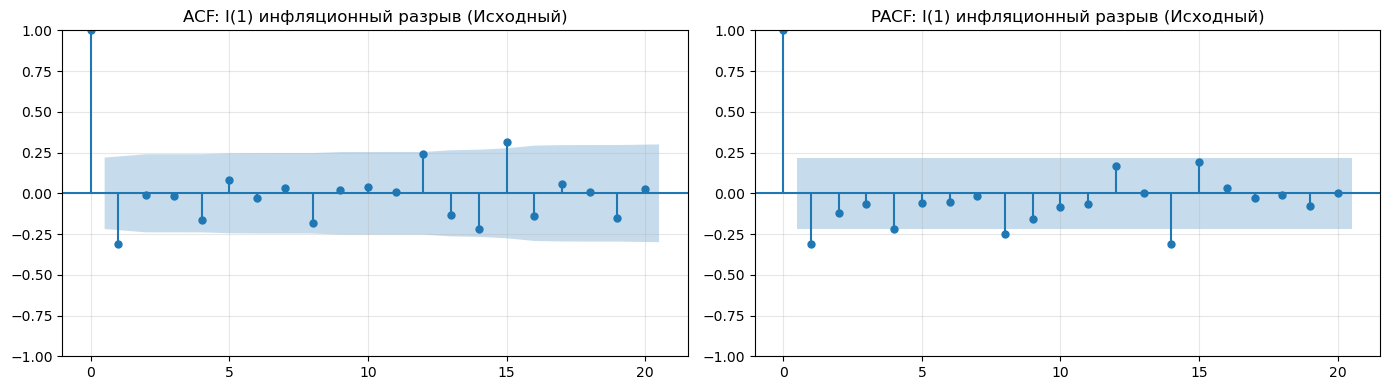

In [768]:
###############################
# Тест Льюинга-Бокса для I(1) переменных
###############################

# === ПЕРЕМЕННЫЕ ДЛЯ ТЕСТА ===
test_variables = {
    'D_log_ROISFIX': 'Логарифм I(1) ставки ROISFIX',
    'D_Inflation_gap': 'I(1) инфляционный разрыв',
    'D_log_Nominal_Percent_Rate': 'Логарифм I(1) нейтральной ставки',
    'D_Ent_conf_ind_total': 'I(1) индекс уверенности'
}

# === ФУНКЦИЯ 1: Определяет какой ряд использовать (adj или исходный) ===
def get_series_for_test(df, col_name):
    """
    Проверяет наличие скорректированного ряда (_adj).
    Если есть → возвращает его, иначе возвращает исходный.
    
    Returns:
    --------
    tuple: (series, source_type)
        series : pd.Series - временной ряд
        source_type : str - "Сезонно-скорректированный" или "Исходный"
    """
    
    adj_col = f'{col_name}_adj'
    
    # Проверяем наличие adj столбца и его наполненность
    if adj_col in df.columns:
        adj_series = df[adj_col].dropna()
        if len(adj_series) > 0:
            return adj_series, "Сезонно-скорректированный"
    
    # Если adj не существует или пуст - берем исходный
    original_series = df[col_name].dropna()
    return original_series, "Исходный"

# === ФУНКЦИЯ 2: Тест Льюинга-Бокса ===
def optimized_ljung_box_test(series, name, source_type, max_lags=None):
    """
    Тест Льюинга-Бокса с автоматическим подбором лагов
    
    Parameters:
    -----------
    series : pd.Series или array-like
        Временной ряд для тестирования
    name : str
        Название переменной
    source_type : str
        "Сезонно-скорректированный" или "Исходный"
    max_lags : int, optional
        Максимальное количество лагов
    
    Returns:
    --------
    dict : результаты теста
    """
    
    if len(series) < 30:
        lags = min(10, len(series) - 1)
    else:
        # Автоматический подбор лагов: sqrt(n) + 10 для месячных данных
        lags = min(int(np.sqrt(len(series))) + 10, len(series) - 1)
    
    if max_lags:
        lags = min(lags, max_lags)
    
    # Минимальное количество лагов для теста
    lags = max(5, lags)
    
    try:
        # Основной тест на выбранных лагах
        result = acorr_ljungbox(series, lags=[lags], return_df=True)
        lb_stat = result['lb_stat'].iloc[0]
        lb_pvalue = result['lb_pvalue'].iloc[0]
        
        # Дополнительно проверяем несколько ключевых лагов
        key_lags = [1, 3, 6, 12]
        key_results = []
        
        for lag in key_lags:
            if lag <= lags:
                res = acorr_ljungbox(series, lags=[lag], return_df=True)
                key_results.append({
                    'lag': lag,
                    'pvalue': res['lb_pvalue'].iloc[0]
                })
        
        return {
            'name': name,
            'source_type': source_type,
            'n_obs': len(series),
            'test_lags': lags,
            'lb_statistic': lb_stat,
            'p_value': lb_pvalue,
            'is_white_noise': lb_pvalue > 0.05,
            'key_lags_results': key_results,
            'series': series  # для визуализации
        }
    
    except Exception as e:
        print(f"Ошибка в тесте для {name} ({source_type}): {e}")
        return None

# === ОСНОВНОЙ АНАЛИЗ ===


ljungbox_results = []
problematic_series = []

for col, name in test_variables.items():
    if col not in df_taylor.columns:
        print(f"✗ {name}: столбец '{col}' не найден в df_taylor")
        continue
    
    # Определяем какой ряд использовать
    series, source_type = get_series_for_test(df_taylor, col)
    
    if len(series) < 10:
        print(f"✗ {name}: недостаточно данных (n={len(series)})")
        continue
    
    # Выполняем тест
    result = optimized_ljung_box_test(series, name, source_type)
    
    if result:
        ljungbox_results.append(result)

# === ВЫВОД РЕЗУЛЬТАТОВ ===

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ ТЕСТА ЛЬЮИНГА-БОКСА")
print("="*70)

if ljungbox_results:
    for i, result in enumerate(ljungbox_results, 1):
        print(f"\n{i}. {result['name']}")
        print(f"   Тип данных: {result['source_type']}")
        print(f"   Наблюдения: {result['n_obs']}")
        print(f"   Тестовые лаги: {result['test_lags']}")
        print(f"   Ljung-Box статистика: {result['lb_statistic']:.3f}")
        print(f"   P-значение: {result['p_value']:.6f}")
        
        if result['is_white_noise']:
            print(f"   ✓ ОСТАТКИ БЕЗ АВТОКОРРЕЛЯЦИИ (p > 0.05)")
        else:
            print(f"   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)")
            problematic_series.append(result)
        
        # Ключевые лаги
        print(f"   Ключевые лаги:")
        for key_res in result['key_lags_results']:
            sig_mark = "✓" if key_res['pvalue'] > 0.05 else "✗"
            print(f"     Лаг {key_res['lag']:2d}: p={key_res['pvalue']:.6f} {sig_mark}")

# === СВОДНАЯ ТАБЛИЦА ===

if ljungbox_results:
    print("\n" + "="*70)
    print("СВОДНАЯ ТАБЛИЦА")
    print("="*70)
    
    summary_data = []
    for result in ljungbox_results:
        # Подсчитываем количество значимых лагов из ключевых
        sig_lags = sum(1 for res in result['key_lags_results'] if res['pvalue'] < 0.05)
        total_lags = len(result['key_lags_results'])
        
        # Определяем статус
        if result['is_white_noise']:
            status = "✓ OK"
        elif sig_lags <= 2:
            status = "⚠ Приемлемо"
        else:
            status = "✗ Проблема"
        
        summary_data.append({
            'Переменная': result['name'],
            'Тип данных': result['source_type'],
            'N': result['n_obs'],
            'P-значение': f"{result['p_value']:.6f}",
            'Значимые лаги': f"{sig_lags}/{total_lags}",
            'Статус': status
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

# === ВИЗУАЛИЗАЦИЯ ACF/PACF ДЛЯ ПРОБЛЕМНЫХ РЯДОВ ===

print("\n" + "="*70)
print("ВИЗУАЛИЗАЦИЯ ACF/PACF")
print("="*70)

# Визуализируем только для проблемных рядов
if problematic_series:
    for result in problematic_series:
        col_name = None
        for col, name in test_variables.items():
            if name == result['name']:
                col_name = col
                break
        
        if col_name:
            series = result['series']
            
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            
            # ACF
            plot_acf(series, lags=min(20, len(series)-1), ax=axes[0], alpha=0.05)
            axes[0].set_title(f'ACF: {result["name"]} ({result["source_type"]})')
            axes[0].grid(alpha=0.3)
            
            # PACF
            plot_pacf(series, lags=min(20, len(series)-1), ax=axes[1], alpha=0.05)
            axes[1].set_title(f'PACF: {result["name"]} ({result["source_type"]})')
            axes[1].grid(alpha=0.3)
            
            plt.tight_layout()
            plt.show()
else:
    print("\n✓ Нет проблемных рядов - все переменные имеют приемлемый уровень автокорреляции!")

In [769]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ОБРАБОТАННЫЕ ДАННЫЕ
###############################
descriptive_df = df_taylor[[
    'D_log_ROISFIX',
    'D_Inflation_gap',
    'D_log_Nominal_Percent_Rate',
    'D_Ent_conf_ind_total'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ОБРАБОТАННЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ОБРАБОТАННЫЕ ДАННЫЕ
                            Среднее  Медиана  ст. откл.   Мин.  Макс.
D_log_ROISFIX                 0.010    0.000      0.116 -0.298  0.741
D_Inflation_gap               0.025    0.138      1.176 -5.551  4.088
D_log_Nominal_Percent_Rate    0.003    0.000      0.041 -0.167  0.241
D_Ent_conf_ind_total          0.011    0.058      0.843 -3.219  2.726


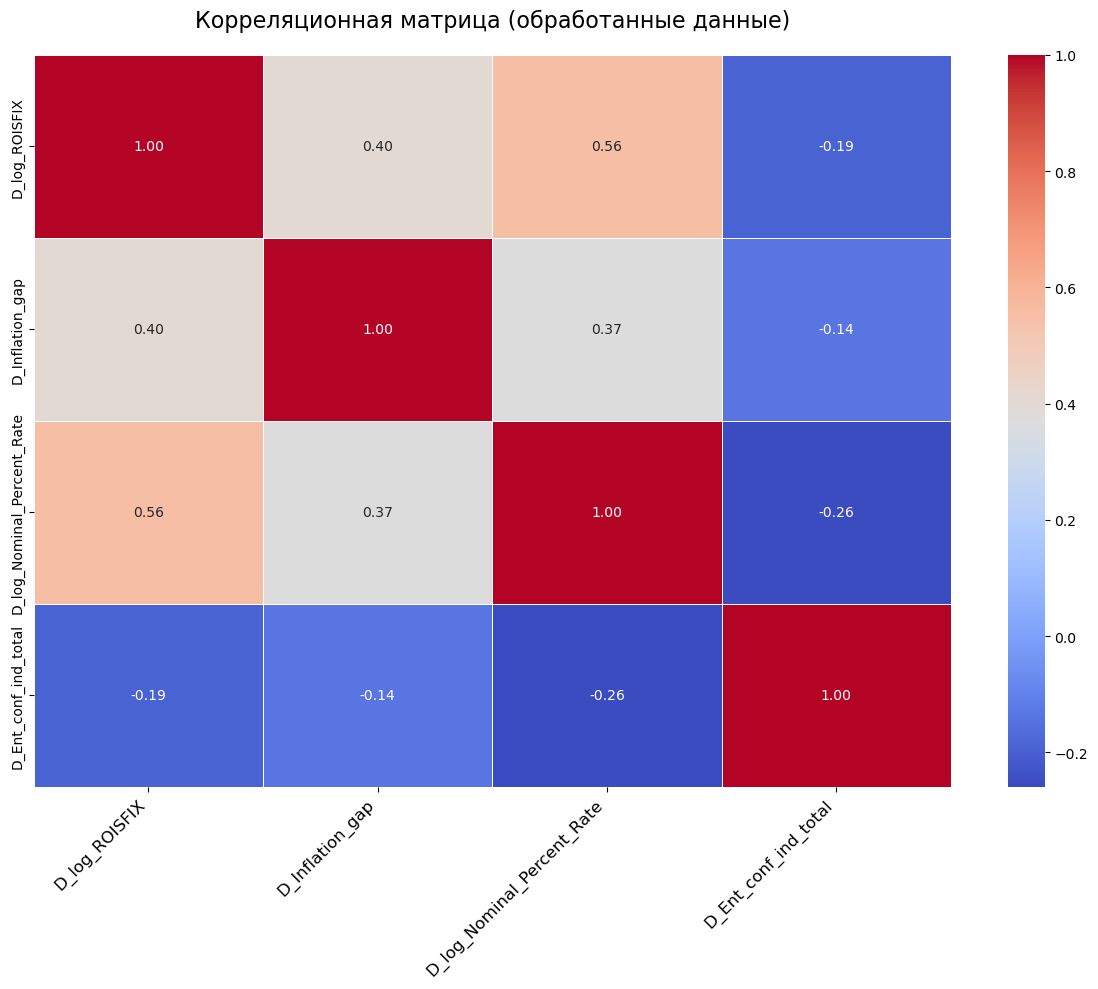

In [770]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ОБРАБОТАННЫЕ ДАННЫЕ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (обработанные данные)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [771]:
###############################
    #VIF-анализ - обработанные данные
###############################

vif_variables = [
    'D_log_ROISFIX',
    'D_Inflation_gap',
    'D_log_Nominal_Percent_Rate',
    'D_Ent_conf_ind_total'
]
df_vif = df_taylor[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ОБРАБОТАННЫЕ ДАННЫЕ")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ОБРАБОТАННЫЕ ДАННЫЕ
                  Variable      VIF
D_log_Nominal_Percent_Rate 1.555392
             D_log_ROISFIX 1.554556
           D_Inflation_gap 1.241706
      D_Ent_conf_ind_total 1.076955


In [772]:
###############################
    #Тест Йохансена на поиск коинтегрирующего соотношения
###############################
print("\n" + "="*60)
print("ТЕСТ ЙОХАНСЕНА")
print("="*60)

# === ДАННЫЕ В УРОВНЯХ ===
df_johansen = df_RF[['ROISFIX', 'Inflation_gap', 'Nominal_Percent_Rate', 'Ent_conf_ind_total']].dropna()

print(f"\nДанные: {len(df_johansen)} наблюдений")
print(f"Период: {df_RF['Date'].min()} - {df_RF['Date'].max()}")

# === ТЕСТ ЙОХАНСЕНА ===
print("\n" + "="*60)
print("Тестирование на коинтеграцию используемых временных рядов")
print("Результаты проведения теста Йохансена на поиск коинтегрирующего соотношения")
print("Статистика Trace Value")
print("="*60)

johansen = coint_johansen(df_johansen, det_order=0, k_ar_diff=1)

# Таблица результатов Trace test
print(f"\n{'r':<6} {'Test':<10} {'10%':<10} {'5%':<10} {'1%':<10} {'Result':<15}")
print("-"*60)

rank = 0
k = len(df_johansen.columns)

for r in range(k):
    stat = johansen.lr1[r]
    crit_10 = johansen.cvt[r, 0]
    crit_5 = johansen.cvt[r, 1]
    crit_1 = johansen.cvt[r, 2]
    
    # ПРАВИЛЬНАЯ логика определения ранга:
    # H0: ранг коинтеграции <= r
    # H1: ранг коинтеграции > r
    
    if stat > crit_5:
        result_text = "✓ Reject H0"
    else:
        result_text = "✗ Accept H0"
        rank = r
        break
else:
    # Если отвергли все гипотезы (для всех r от 0 до k-1), то ранг = k
    rank = k

print(f"{r:<6} {stat:<10.2f} {crit_10:<10.2f} {crit_5:<10.2f} {crit_1:<10.2f} {result_text:<15}")

# ВЫВОДИМ ВСЕ СТРОКИ ТАБЛИЦЫ ДЛЯ ПРОЗРАЧНОСТИ
for r_display in range(k):
    if r_display != r:  
        stat_display = johansen.lr1[r_display]
        crit_10_display = johansen.cvt[r_display, 0]
        crit_5_display = johansen.cvt[r_display, 1]
        crit_1_display = johansen.cvt[r_display, 2]
        
        if stat_display > crit_5_display:
            result_text_display = "✓ Reject H0"
        else:
            result_text_display = "✗ Accept H0"
            
        print(f"{r_display:<6} {stat_display:<10.2f} {crit_10_display:<10.2f} {crit_5_display:<10.2f} {crit_1_display:<10.2f} {result_text_display:<15}")

print(f"\n→ Ранг коинтеграции: r = {rank}")

# === ЛИНЕЙНАЯ КОМБИНАЦИЯ ИССЛЕДУЕМЫХ РЯДОВ ===
print("\n" + "="*60)
print("Линейная комбинация исследуемых рядов")
print("="*60)

if rank > 0:
    # Нормализуем первый собственный вектор (коинтеграционный вектор)
    beta = johansen.evec[:, 0].copy()
    beta = beta / beta[0]

    print(f"\nКоинтеграционный вектор (β):")
    print(f"(долгосрочное равновесное соотношение)\n")

    # Названия переменных как в таблице
    var_display_names = [
        'Key_Rate_t',
        'Inflation_Expectations_12m_t', 
        'Output_Gap_t',
        'Neutral_Rate_t'
    ]

    for i, display_name in enumerate(var_display_names):
        coef = beta[i]
        print(f"{display_name:<35} {coef:>15.7f}")
else:
    print("\nКоинтеграционные векторы не найдены")


ТЕСТ ЙОХАНСЕНА

Данные: 81 наблюдений
Период: 2019-02-01 00:00:00 - 2025-10-01 00:00:00

Тестирование на коинтеграцию используемых временных рядов
Результаты проведения теста Йохансена на поиск коинтегрирующего соотношения
Статистика Trace Value

r      Test       10%        5%         1%         Result         
------------------------------------------------------------
1      23.90      27.07      29.80      35.46      ✗ Accept H0    
0      49.67      44.49      47.85      54.68      ✓ Reject H0    
2      13.91      13.43      15.49      19.93      ✗ Accept H0    
3      5.56       2.71       3.84       6.63       ✓ Reject H0    

→ Ранг коинтеграции: r = 1

Линейная комбинация исследуемых рядов

Коинтеграционный вектор (β):
(долгосрочное равновесное соотношение)

Key_Rate_t                                1.0000000
Inflation_Expectations_12m_t             -1.5582988
Output_Gap_t                             -3.0954933
Neutral_Rate_t                           -1.0512742


In [773]:
###############################
    #Подготовка финального датасета (добавляем дамми, лаги и прозведения)
###############################

df_taylor['Covid_dum'] = df_RF['Covid_dum']
df_taylor['Sank_dum'] = df_RF['Sank_dum']
df_taylor['L1_D_Inflation_gap'] = df_taylor['D_Inflation_gap'].shift(1)
df_taylor['L1_D_Ent_conf_ind_total'] = df_taylor['D_Ent_conf_ind_total'].shift(1)
df_taylor['L1_D_log_Nominal_Percent_Rate'] = df_taylor['D_log_Nominal_Percent_Rate'].shift(1)  
df_taylor['L1_D_log_ROISFIX'] = df_taylor['D_log_ROISFIX'].shift(1)

df_taylor = df_taylor.dropna()
df_taylor.head()

,Date,D_log_ROISFIX,D_log_Nominal_Percent_Rate,D_Inflation_gap,D_Ent_conf_ind_total,D_Expected_Inflation_12m,Covid_dum,Sank_dum,L1_D_Inflation_gap,L1_D_Ent_conf_ind_total,L1_D_log_Nominal_Percent_Rate,L1_D_log_ROISFIX
2,2019-04-01,0.002428,0.0,-1.048207,1.399637,-1.048207,0,0,-0.415195,0.849023,0.0,-0.005307
3,2019-05-01,0.000728,0.0,0.523846,-0.669417,0.523846,0,0,-1.048207,1.399637,0.0,0.002428
4,2019-06-01,-0.014620,0.0,0.034402,0.231400,0.034402,0,0,0.523846,-0.669417,0.0,0.000728
5,2019-07-01,-0.024679,0.0,0.030949,-0.322945,0.030949,0,0,0.034402,0.231400,0.0,-0.014620
6,2019-08-01,-0.029715,0.0,-0.023716,-0.477790,-0.023716,0,0,0.030949,-0.322945,0.0,-0.024679


In [774]:
###############################
# Тест White и Breusch-Pagan на гетероскедастичность
###############################
print("\n" + "="*60)
print("ТЕСТЫ НА ГЕТЕРОСКЕДАСТИЧНОСТЬ: WHITE И BREUSCH-PAGAN")
print("="*60)

# Подготавливаем данные для регрессии
X = sm.add_constant(df_taylor[['D_Inflation_gap', 'D_log_Nominal_Percent_Rate', 'D_Ent_conf_ind_total']])
y = df_taylor['D_log_ROISFIX']

# Строим базовую модель OLS
model_ols = sm.OLS(y, X).fit()

# Получаем остатки
residuals = model_ols.resid

print("\nРегрессионная модель:")
print(f"Зависимая переменная: D_log_ROISFIX")
print(f"Количество наблюдений: {len(y)}")
print(f"R-squared: {model_ols.rsquared:.4f}")

# === ТЕСТ BREUSCH-PAGAN ===
print("\n" + "-"*60)
print("ТЕСТ BREUSCH-PAGAN")
print("-"*60)
print("H0: Гомоскедастичность (константная дисперсия)")
print("H1: Гетероскедастичность (переменная дисперсия)\n")

bp_stat, bp_pvalue, bp_f_stat, bp_f_pvalue = het_breuschpagan(residuals, X)

print(f"LM-статистика Breusch-Pagan: {bp_stat:.4f}")
print(f"P-значение (LM): {bp_pvalue:.6f}")
print(f"F-статистика: {bp_f_stat:.4f}")
print(f"P-значение (F): {bp_f_pvalue:.6f}")

if bp_pvalue < 0.05:
    print("\n ОТКЛОНЯЕМ H0: ОБНАРУЖЕНА ГЕТЕРОСКЕДАСТИЧНОСТЬ (p < 0.05)")
else:
    print("\n ПРИНИМАЕМ H0: НЕТ ЗНАЧИМОЙ ГЕТЕРОСКЕДАСТИЧНОСТИ (p > 0.05)")

# === ТЕСТ WHITE ===
print("\n" + "-"*80)
print("ТЕСТ WHITE")
print("-"*80)
print("H0: Гомоскедастичность (константная дисперсия)")
print("H1: Гетероскедастичность (переменная дисперсия)\n")

white_stat, white_pvalue, white_df, white_fitted = het_white(residuals, X)

print(f"LM-статистика White: {white_stat:.4f}")
print(f"P-значение: {white_pvalue:.6f}")
print(f"Степени свободы: {white_df}")

if white_pvalue < 0.05:
    print("\n ОТКЛОНЯЕМ H0: ОБНАРУЖЕНА ГЕТЕРОСКЕДАСТИЧНОСТЬ (p < 0.05)")
else:
    print("\n ПРИНИМАЕМ H0: НЕТ ЗНАЧИМОЙ ГЕТЕРОСКЕДАСТИЧНОСТИ (p > 0.05)")

# === СВОДНАЯ ТАБЛИЦА ===
print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)

summary_heteroscedasticity = pd.DataFrame({
    'Тест': ['Breusch-Pagan (LM)', 'Breusch-Pagan (F)', 'White'],
    'Статистика': [f"{bp_stat:.4f}", f"{bp_f_stat:.4f}", f"{white_stat:.4f}"],
    'P-значение': [f"{bp_pvalue:.6f}", f"{bp_f_pvalue:.6f}", f"{white_pvalue:.6f}"],
    'Вывод': [
        ' Гетероскедастичность' if bp_pvalue < 0.05 else ' Гомоскедастичность',
        ' Гетероскедастичность' if bp_f_pvalue < 0.05 else ' Гомоскедастичность',
        ' Гетероскедастичность' if white_pvalue < 0.05 else ' Гомоскедастичность'
    ]
})

print(summary_heteroscedasticity.to_string(index=False))


ТЕСТЫ НА ГЕТЕРОСКЕДАСТИЧНОСТЬ: WHITE И BREUSCH-PAGAN

Регрессионная модель:
Зависимая переменная: D_log_ROISFIX
Количество наблюдений: 79
R-squared: 0.3566

------------------------------------------------------------
ТЕСТ BREUSCH-PAGAN
------------------------------------------------------------
H0: Гомоскедастичность (константная дисперсия)
H1: Гетероскедастичность (переменная дисперсия)

LM-статистика Breusch-Pagan: 1.8803
P-значение (LM): 0.597618
F-статистика: 0.6095
P-значение (F): 0.610888

 ПРИНИМАЕМ H0: НЕТ ЗНАЧИМОЙ ГЕТЕРОСКЕДАСТИЧНОСТИ (p > 0.05)

--------------------------------------------------------------------------------
ТЕСТ WHITE
--------------------------------------------------------------------------------
H0: Гомоскедастичность (константная дисперсия)
H1: Гетероскедастичность (переменная дисперсия)

LM-статистика White: 48.4462
P-значение: 0.000000
Степени свободы: 12.156261923118606

 ОТКЛОНЯЕМ H0: ОБНАРУЖЕНА ГЕТЕРОСКЕДАСТИЧНОСТЬ (p < 0.05)

СВОДНАЯ ТАБЛИЦА РЕЗУ

In [775]:
###############################
# ИНТЕРПРЕТАЦИЯ КЛЮЧЕВЫХ КОЭФФИЦИЕНТОВ
###############################

def extract_ardl_coefficients(result, y_name, print_results=True):
    """
    Извлекает ключевые коэффициенты из ARDL модели:
    - α (alpha): реакция на инфляцию
    - μ (mu): реакция на уверенность
    - γ (gamma): коэффициент инерции (лаг зависимой переменной)
    """
    params = result.params
    pvalues = result.pvalues
    
    coeffs = {
        'alpha': None,
        'mu': None,
        'gamma': None,
        'alpha_pval': None,
        'mu_pval': None,
        'gamma_pval': None
    }
    
    # Извлечение альфа (инфляция)
    if 'D_Inflation_gap' in params.index:
        coeffs['alpha'] = params['D_Inflation_gap']
        coeffs['alpha_pval'] = pvalues['D_Inflation_gap']
    
    # Извлечение мю (уверенность)
    if 'D_Ent_conf_ind_total' in params.index:
        coeffs['mu'] = params['D_Ent_conf_ind_total']
        coeffs['mu_pval'] = pvalues['D_Ent_conf_ind_total']
    
    # Извлечение гамма (лаг зависимой переменной)
    # Ищем по паттерну: y_lag.1, L.y, D_log_ROISFIX.L1, etc.
    lag_patterns = [
    f'{y_name}.L1',
    f'L.{y_name}',
    f'{y_name}_lag',
    f'{y_name}_lag.1',
    f'{y_name}_L1',
    f'L1_{y_name}',
    ]
    
    for pattern in lag_patterns:
        if pattern in params.index:
            coeffs['gamma'] = params[pattern]
            coeffs['gamma_pval'] = pvalues[pattern]
            coeffs['gamma_name'] = pattern
            break
    
    # Вывод результатов
    if print_results:
        print("\n" + "="*60)
        print("ИНТЕРПРЕТАЦИЯ КЛЮЧЕВЫХ КОЭФФИЦИЕНТОВ ARDL")
        print("="*60)
        
        # α - реакция на инфляцию
        if coeffs['alpha'] is not None:
            alpha_sr = coeffs['alpha']
            alpha_pval = coeffs['alpha_pval']
            sig_alpha = "***" if alpha_pval < 0.01 else ("**" if alpha_pval < 0.05 else "*" if alpha_pval < 0.1 else "")
            print(f"\nα (АЛЬФА) - краткосрочная реакция на инфляцию:")
            print(f"  Значение: {alpha_sr:.6f} {sig_alpha}")
            print(f"  P-value: {alpha_pval:.6f}")
            print(f"  Интерпретация: На 1% рост инфляции, ставка {'растет' if alpha_sr > 0 else 'падает'} на {abs(alpha_sr):.4f}%")
            if alpha_pval < 0.05:
                print(f"  Статистическая значимость: Значима (p < 0.05)")
            else:
                print(f"  Статистическая значимость: Незначима (p > 0.05)")
        else:
            print("\n α (альфа) не найдена в модели")
        
        # μ - реакция на уверенность
        if coeffs['mu'] is not None:
            mu_sr = coeffs['mu']
            mu_pval = coeffs['mu_pval']
            sig_mu = "***" if mu_pval < 0.01 else ("**" if mu_pval < 0.05 else "*" if mu_pval < 0.1 else "")
            print(f"\nμ (МЮ) - краткосрочная реакция на разрыв выпуска:")
            print(f"  Значение: {mu_sr:.6f} {sig_mu}")
            print(f"  P-value: {mu_pval:.6f}")
            print(f"  Интерпретация: На 1 пункт рост уверенности (прокси разрыва выпуска), ставка {'растет' if mu_sr > 0 else 'падает'} на {abs(mu_sr):.4f}%")
            if mu_pval < 0.05:
                print(f"  Статистическая значимость: Значима (p < 0.05)")
            else:
                print(f"  Статистическая значимость: Незначима (p > 0.05)")
        else:
            print("\n μ (мю) не найдена в модели")
        
        # γ - инерция (лагированная ставка)
        if coeffs['gamma'] is not None:
            gamma = coeffs['gamma']
            gamma_pval = coeffs['gamma_pval']
            speed_adj = 1 - gamma
            sig_gamma = "***" if gamma_pval < 0.01 else ("**" if gamma_pval < 0.05 else "*" if gamma_pval < 0.1 else "")
            
            print(f"\nγ (ГАММА) - коэффициент инерции (лаг зависимой переменной):")
            print(f"  Переменная: {coeffs.get('gamma_name', 'неизвестно')}")
            print(f"  Значение: {gamma:.6f} {sig_gamma}")
            print(f"  P-value: {gamma_pval:.6f}")
            
            print(f"\n  Интерпретация:")
            print(f"    - Инерция системы: {gamma:.4f} (доля предыдущего периода)")
            print(f"    - Скорость адаптации к равновесию: {speed_adj:.4f}")
            print(f"    - На каждый период корректируется: {speed_adj*100:.2f}% отклонения")
            
            if 0 < gamma < 1:
                print(f"    - Модель СТАБИЛЬНА (динамическое равновесие)")
            elif gamma >= 1:
                print(f"    -  Модель НЕСТАБИЛЬНА (взрывной процесс)")
            elif gamma < 0:
                print(f"    - ОТРИЦАТЕЛЬНАЯ инерция (колебания вокруг равновесия)")
        else:
            print("\n γ (гамма) не найдена в модели")
    
    return coeffs

In [776]:
###############################
# МОДЕЛЬ 1: БАЗОВАЯ (без dummy)
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 1: БАЗОВАЯ ARDL (1, 0, 0, 0) БЕЗ DUMMY")
print("="*60)

formula1 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate + 
            D_Ent_conf_ind_total
            """

model1 = ols(formula1, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model1.summary())
coeffs = extract_ardl_coefficients(model1, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 1: БАЗОВАЯ ARDL (1, 0, 0, 0) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.443
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     6.524
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           0.000149
Time:                        16:53:06   Log-Likelihood:                 81.292
No. Observations:                  79   AIC:                            -152.6
Df Residuals:                      74   BIC:                            -140.7
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

In [777]:
###############################
# МОДЕЛЬ 2: с дамми для 2022 и для ковида
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 2: ARDL (1, 0, 0, 0) С DUMMY")
print("="*60)

formula2 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate + 
            D_Ent_conf_ind_total +
            Sank_dum +
            Covid_dum
            """

model2 = ols(formula2, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model2.summary())
coeffs = extract_ardl_coefficients(model2, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 2: ARDL (1, 0, 0, 0) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.443
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     5.176
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           0.000179
Time:                        16:53:06   Log-Likelihood:                 81.347
No. Observations:                  79   AIC:                            -148.7
Df Residuals:                      72   BIC:                            -132.1
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [778]:
###############################
# МОДЕЛЬ 3: с лагаом inf_gap разрыва без дамми 
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 3: ARDL (1, 1, 0, 0) БЕЗ DUMMY ")
print("="*60)

formula3 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap +
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total
            """

model3 = ols(formula3, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model3.summary())
coeffs = extract_ardl_coefficients(model3, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 3: ARDL (1, 1, 0, 0) БЕЗ DUMMY 
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.462
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     5.657
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           0.000183
Time:                        16:53:06   Log-Likelihood:                 82.663
No. Observations:                  79   AIC:                            -153.3
Df Residuals:                      73   BIC:                            -139.1
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

In [779]:
###############################
# МОДЕЛЬ 4: с лагом inf_gap разрыва с дамми 
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 4: ARDL (1, 1, 0, 0) С DUMMY ")
print("="*60)



formula4 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap +
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            Sank_dum +
            Covid_dum
            """

model4 = ols(formula4, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model4.summary())
coeffs = extract_ardl_coefficients(model4, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 4: ARDL (1, 1, 0, 0) С DUMMY 
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.462
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     4.595
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           0.000280
Time:                        16:53:06   Log-Likelihood:                 82.695
No. Observations:                  79   AIC:                            -149.4
Df Residuals:                      71   BIC:                            -130.4
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

In [780]:
###############################
# МОДЕЛЬ 5: ARDL с лагом r* без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 5: ARDL (1, 0, 1, 0) БЕЗ DUMMY")
print("="*60)

formula5 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total 
            """

model5 = ols(formula5, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model5.summary())
coeffs = extract_ardl_coefficients(model5, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 5: ARDL (1, 0, 1, 0) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.517
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     10.39
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           1.50e-07
Time:                        16:53:06   Log-Likelihood:                 86.919
No. Observations:                  79   AIC:                            -161.8
Df Residuals:                      73   BIC:                            -147.6
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [781]:
###############################
# МОДЕЛЬ 6: ARDL с лагом r* С дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 6: ARDL (1, 0, 1, 0) С DUMMY")
print("="*60)

formula6 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            Sank_dum +
            Covid_dum
            """

model6 = ols(formula6, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model6.summary())
coeffs = extract_ardl_coefficients(model6, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 6: ARDL (1, 0, 1, 0) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     7.648
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           7.34e-07
Time:                        16:53:06   Log-Likelihood:                 87.008
No. Observations:                  79   AIC:                            -158.0
Df Residuals:                      71   BIC:                            -139.1
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

In [782]:
###############################
# МОДЕЛЬ 7: ARDL с лагом y_gap БЕЗ дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 7: ARDL (1, 0, 0, 1) БЕЗ DUMMY")
print("="*60)

formula7 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total
            """

model7 = ols(formula7, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model6.summary())
coeffs = extract_ardl_coefficients(model6, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 7: ARDL (1, 0, 0, 1) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     7.648
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           7.34e-07
Time:                        16:53:06   Log-Likelihood:                 87.008
No. Observations:                  79   AIC:                            -158.0
Df Residuals:                      71   BIC:                            -139.1
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [783]:
###############################
# МОДЕЛЬ 8: ARDL с лагом y_gap с дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 8: ARDL (1, 0, 0, 1) С DUMMY")
print("="*60)

formula8 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model8 = ols(formula8, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model8.summary())
coeffs = extract_ardl_coefficients(model8, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 8: ARDL (1, 0, 0, 1) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.417
Method:                 Least Squares   F-statistic:                     6.297
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           9.27e-06
Time:                        16:53:06   Log-Likelihood:                 83.234
No. Observations:                  79   AIC:                            -150.5
Df Residuals:                      71   BIC:                            -131.5
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [784]:
###############################
# МОДЕЛЬ 9: ARDL с лагом inf_gap и r* без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 9: ARDL (1, 1, 1, 0) БЕЗ DUMMY")
print("="*60)

formula9 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap+
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate+
            D_Ent_conf_ind_total
            """

model9 = ols(formula9, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model9.summary())
coeffs = extract_ardl_coefficients(model9, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 9: ARDL (1, 1, 1, 0) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     12.66
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           1.07e-09
Time:                        16:53:06   Log-Likelihood:                 89.852
No. Observations:                  79   AIC:                            -165.7
Df Residuals:                      72   BIC:                            -149.1
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [785]:
###############################
# МОДЕЛЬ 10: ARDL с лагом inf_gap и r* с дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 10: ARDL (1, 1, 1, 0) С DUMMY")
print("="*60)

formula10 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap+
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate+
            D_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model10 = ols(formula10, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model10.summary())
coeffs = extract_ardl_coefficients(model10, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 10: ARDL (1, 1, 1, 0) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.553
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     10.02
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           3.48e-09
Time:                        16:53:06   Log-Likelihood:                 90.024
No. Observations:                  79   AIC:                            -162.0
Df Residuals:                      70   BIC:                            -140.7
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

In [786]:
###############################
# МОДЕЛЬ 11: ARDL с лагом inf_gap и y_gap без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 11: ARDL (1, 1, 0, 1) БЕЗ DUMMY")
print("="*60)

formula11 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap +
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total
            """

model11 = ols(formula11, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model11.summary())
coeffs = extract_ardl_coefficients(model11, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 11: ARDL (1, 1, 0, 1) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     7.599
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           2.46e-06
Time:                        16:53:06   Log-Likelihood:                 84.743
No. Observations:                  79   AIC:                            -155.5
Df Residuals:                      72   BIC:                            -138.9
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

In [787]:
###############################
# МОДЕЛЬ 12: ARDL с лагом inf_gap и y_gap с дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 12: ARDL (1, 1, 0, 1) С DUMMY")
print("="*60)

formula12 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap +
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model12 = ols(formula12, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model12.summary())
coeffs = extract_ardl_coefficients(model12, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 12: ARDL (1, 1, 0, 1) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.431
Method:                 Least Squares   F-statistic:                     6.686
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           1.80e-06
Time:                        16:53:06   Log-Likelihood:                 84.750
No. Observations:                  79   AIC:                            -151.5
Df Residuals:                      70   BIC:                            -130.2
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

In [788]:
###############################
# МОДЕЛЬ 13: ARDL с лагом r* и y_gap без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 13: ARDL (1, 0, 1, 1) БЕЗ DUMMY")
print("="*60)

formula13 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total
            """

model13 = ols(formula13, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model13.summary())
coeffs = extract_ardl_coefficients(model11, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 13: ARDL (1, 0, 1, 1) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.492
Method:                 Least Squares   F-statistic:                     11.39
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           6.52e-09
Time:                        16:53:06   Log-Likelihood:                 88.107
No. Observations:                  79   AIC:                            -162.2
Df Residuals:                      72   BIC:                            -145.6
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

In [789]:
###############################
# МОДЕЛЬ 14: ARDL с лагом inf_gap и y_gap с дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 14: ARDL (1, 0, 1, 1) С DUMMY")
print("="*60)

formula14 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model14 = ols(formula14, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model14.summary())
coeffs = extract_ardl_coefficients(model14, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 14: ARDL (1, 0, 1, 1) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.479
Method:                 Least Squares   F-statistic:                     9.016
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           2.05e-08
Time:                        16:53:06   Log-Likelihood:                 88.225
No. Observations:                  79   AIC:                            -158.5
Df Residuals:                      70   BIC:                            -137.1
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

In [790]:
###############################
# МОДЕЛЬ 15: ARDL с лагами всех переменных без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 15: ARDL (1, 1, 1, 1) БЕЗ DUMMY")
print("="*60)

formula15 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total 
            """

model15 = ols(formula15, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model15.summary())
coeffs = extract_ardl_coefficients(model15, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 15: ARDL (1, 1, 1, 1) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.523
Method:                 Least Squares   F-statistic:                     14.09
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           2.57e-11
Time:                        16:53:06   Log-Likelihood:                 91.116
No. Observations:                  79   AIC:                            -166.2
Df Residuals:                      71   BIC:                            -147.3
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

In [791]:
###############################
# МОДЕЛЬ 16: ARDL ARDL с лагами всех переменных и дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 16: ARDL (1, 1, 1, 1) С DUMMY")
print("="*60)

formula16 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model16 = ols(formula16, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model16.summary())
coeffs = extract_ardl_coefficients(model16, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 16: ARDL (1, 1, 1, 1) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.568
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     13.96
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           1.70e-12
Time:                        16:53:06   Log-Likelihood:                 91.345
No. Observations:                  79   AIC:                            -162.7
Df Residuals:                      69   BIC:                            -139.0
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

In [792]:
###############################
# СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ
###############################


print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)

models = [model1, model2, model3, model4,
          model5, model6, model7, model8,
          model9, model10, model11, model12,
          model13, model14, model15, model16]
model_names = ['Model 1/(1,0,0,0)', 'Model 2/(1,0,0,0)D', 
               'Model 3/(1,1,0,0)', 'Model 4/(1,1,0,0)D', 
               'Model 5/(1,0,1,0)', 'Model 6/(1,0,1,0)D',
               'Model 7/(1,0,0,1)', 'Model 8/(1,0,0,1)D',
               'Model 9/(1,1,1,0)', 'Model 10/(1,1,1,0)D', 
               'Model 11/(1,1,0,1)', 'Model 12/(1,1,0,1)D', 
               'Model 13/(1,0,1,1)', 'Model 14/(1,0,1,1)D',
               'Model 15/(1,1,1,1)', 'Model 16/(1,1,1,1)D'
              ]

comparison_data = {
    'Model': model_names,
    'R²': [m.rsquared for m in models],
    'Adj-R²': [m.rsquared_adj for m in models],
    'AIC': [m.aic for m in models],
    'BIC': [m.bic for m in models],
    'F-stat': [m.fvalue for m in models],
    'N': [len(m.resid) for m in models]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


СРАВНЕНИЕ МОДЕЛЕЙ
              Model       R²   Adj-R²         AIC         BIC    F-stat  N
  Model 1/(1,0,0,0) 0.442626 0.412498 -152.583702 -140.736463  6.524041 79
 Model 2/(1,0,0,0)D 0.443399 0.397016 -148.693307 -132.107172  5.176147 79
  Model 3/(1,1,0,0) 0.461641 0.424767 -153.325830 -139.109143  5.657261 79
 Model 4/(1,1,0,0)D 0.462073 0.409038 -149.389222 -130.433639  4.594690 79
  Model 5/(1,0,1,0) 0.516638 0.483531 -161.838878 -147.622190 10.386683 79
 Model 6/(1,0,1,0)D 0.517726 0.470178 -158.016941 -139.061358  7.647867 79
  Model 7/(1,0,0,1) 0.469155 0.432796 -154.436216 -140.219529  8.203375 79
 Model 8/(1,0,0,1)D 0.469372 0.417057 -150.468506 -131.512923  6.296599 79
  Model 9/(1,1,1,0) 0.551229 0.513831 -165.704778 -149.118643 12.656854 79
Model 10/(1,1,1,0)D 0.553173 0.502107 -162.047813 -140.722782 10.017382 79
 Model 11/(1,1,0,1) 0.489257 0.446695 -155.485870 -138.899735  7.598867 79
Model 12/(1,1,0,1)D 0.489348 0.430988 -151.499977 -130.174946  6.686050 79
 Model

In [793]:
###############################
# ВЫБОР ЛУЧШЕЙ МОДЕЛИ
###############################

print("\n" + "="*60)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по BIC)")
print("="*60)

bic_values = [m.bic for m in models]
best_idx = np.argmin(bic_values)
best_model = models[best_idx]
best_name = model_names[best_idx]

print(f"\n Оптимальная модель: {best_name}")
print(f"  BIC = {best_model.bic:.4f}")

###############################
# КЛЮЧЕВЫЕ КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ
###############################

print("\n" + "="*60)
print("КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ")
print("="*60)

params = best_model.params
pvalues = best_model.pvalues
tvalues = best_model.tvalues

print(f"\nПараметры модели {best_name}:\n")

for param_name in params.index:
    value = params[param_name]
    pval = pvalues[param_name]
    tstat = tvalues[param_name]
    
    # Значимость
    if pval < 0.01:
        sig = "***"
    elif pval < 0.05:
        sig = "**"
    elif pval < 0.1:
        sig = "*"
    else:
        sig = ""
    
    print(f"{param_name:40s}: {value:10.6f} {sig:3s}  (t={tstat:7.3f}, p={pval:.4f})")
coeffs = extract_ardl_coefficients(model5, y_name='D_log_ROISFIX', print_results=True)


ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по BIC)

 Оптимальная модель: Model 9/(1,1,1,0)
  BIC = -149.1186

КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ

Параметры модели Model 9/(1,1,1,0):

Intercept                               :   0.003712      (t=  0.446, p=0.6557)
L1_D_log_ROISFIX                        :   0.438642 ***  (t=  5.059, p=0.0000)
D_Inflation_gap                         :   0.034649 **   (t=  2.331, p=0.0198)
L1_D_Inflation_gap                      :   0.021241 **   (t=  1.968, p=0.0490)
D_log_Nominal_Percent_Rate              :   1.033757 *    (t=  1.895, p=0.0581)
L1_D_log_Nominal_Percent_Rate           :  -1.040863 ***  (t= -2.708, p=0.0068)
D_Ent_conf_ind_total                    :  -0.003811      (t= -0.368, p=0.7128)

ИНТЕРПРЕТАЦИЯ КЛЮЧЕВЫХ КОЭФФИЦИЕНТОВ ARDL

α (АЛЬФА) - краткосрочная реакция на инфляцию:
  Значение: 0.031412 **
  P-value: 0.036196
  Интерпретация: На 1% рост инфляции, ставка растет на 0.0314%
  Статистическая значимость: Значима (p < 0.05)

μ (МЮ) - краткосрочная реакция на разры

In [794]:
###############################
# Добавляем взаимодействие дамми и разрыва по выпуску
###############################
df_taylor['D_Ent_conf_ind_total_Sank'] = df_taylor['D_Ent_conf_ind_total'] * df_taylor['Sank_dum']

In [795]:
###############################
# МОДЕЛЬ 17: ARDL с лагом inf_gap и r* без дамми со взаимодействием dummy_sank и y_gap
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 17: ARDL (1, 1, 1, 0) БЕЗ DUMMY С ВЗАИМОДЕЙСТВИЕМ DUMMY_SANK И Y_GAP")
print("="*60)

formula17 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap +
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            D_Ent_conf_ind_total_Sank
            """

model17 = ols(formula17, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model17.summary())
coeffs = extract_ardl_coefficients(model17, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 17: ARDL (1, 1, 1, 0) БЕЗ DUMMY С ВЗАИМОДЕЙСТВИЕМ DUMMY_SANK И Y_GAP
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.511
Method:                 Least Squares   F-statistic:                     12.78
Date:                 Ср, 10 дек 2025   Prob (F-statistic):           1.67e-10
Time:                        16:53:06   Log-Likelihood:                 90.212
No. Observations:                  79   AIC:                            -164.4
Df Residuals:                      71   BIC:                            -145.5
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

In [796]:
###############################
# СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ
###############################


print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)

models = [model9, model17]
model_names = ['Model 9/(1,1,1,0)', 'Model 17/(1,1,1,0)Interaction']

comparison_data = {
    'Model': model_names,
    'R²': [m.rsquared for m in models],
    'Adj-R²': [m.rsquared_adj for m in models],
    'AIC': [m.aic for m in models],
    'BIC': [m.bic for m in models],
    'F-stat': [m.fvalue for m in models],
    'N': [len(m.resid) for m in models]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


СРАВНЕНИЕ МОДЕЛЕЙ
                        Model       R²   Adj-R²         AIC         BIC    F-stat  N
            Model 9/(1,1,1,0) 0.551229 0.513831 -165.704778 -149.118643 12.656854 79
Model 17/(1,1,1,0)Interaction 0.555299 0.511456 -164.424654 -145.469071 12.784011 79


In [797]:
###############################
# ВЫБОР ЛУЧШЕЙ МОДЕЛИ
###############################

print("\n" + "="*60)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по BIC)")
print("="*60)

bic_values = [m.bic for m in models]
best_idx = np.argmin(bic_values)
best_model = models[best_idx]
best_name = model_names[best_idx]

print(f"\n Оптимальная модель: {best_name}")
print(f"  BIC = {best_model.bic:.4f}")

###############################
# КЛЮЧЕВЫЕ КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ
###############################

print("\n" + "="*60)
print("КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ")
print("="*60)

params = best_model.params
pvalues = best_model.pvalues
tvalues = best_model.tvalues

print(f"\nПараметры модели {best_name}:\n")

for param_name in params.index:
    value = params[param_name]
    pval = pvalues[param_name]
    tstat = tvalues[param_name]
    
    # Значимость
    if pval < 0.01:
        sig = "***"
    elif pval < 0.05:
        sig = "**"
    elif pval < 0.1:
        sig = "*"
    else:
        sig = ""
    
    print(f"{param_name:40s}: {value:10.6f} {sig:3s}  (t={tstat:7.3f}, p={pval:.4f})")
coeffs = extract_ardl_coefficients(model5, y_name='D_log_ROISFIX', print_results=True)


ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по BIC)

 Оптимальная модель: Model 9/(1,1,1,0)
  BIC = -149.1186

КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ

Параметры модели Model 9/(1,1,1,0):

Intercept                               :   0.003712      (t=  0.446, p=0.6557)
L1_D_log_ROISFIX                        :   0.438642 ***  (t=  5.059, p=0.0000)
D_Inflation_gap                         :   0.034649 **   (t=  2.331, p=0.0198)
L1_D_Inflation_gap                      :   0.021241 **   (t=  1.968, p=0.0490)
D_log_Nominal_Percent_Rate              :   1.033757 *    (t=  1.895, p=0.0581)
L1_D_log_Nominal_Percent_Rate           :  -1.040863 ***  (t= -2.708, p=0.0068)
D_Ent_conf_ind_total                    :  -0.003811      (t= -0.368, p=0.7128)

ИНТЕРПРЕТАЦИЯ КЛЮЧЕВЫХ КОЭФФИЦИЕНТОВ ARDL

α (АЛЬФА) - краткосрочная реакция на инфляцию:
  Значение: 0.031412 **
  P-value: 0.036196
  Интерпретация: На 1% рост инфляции, ставка растет на 0.0314%
  Статистическая значимость: Значима (p < 0.05)

μ (МЮ) - краткосрочная реакция на разры


Визуализация шоков монетарной политики


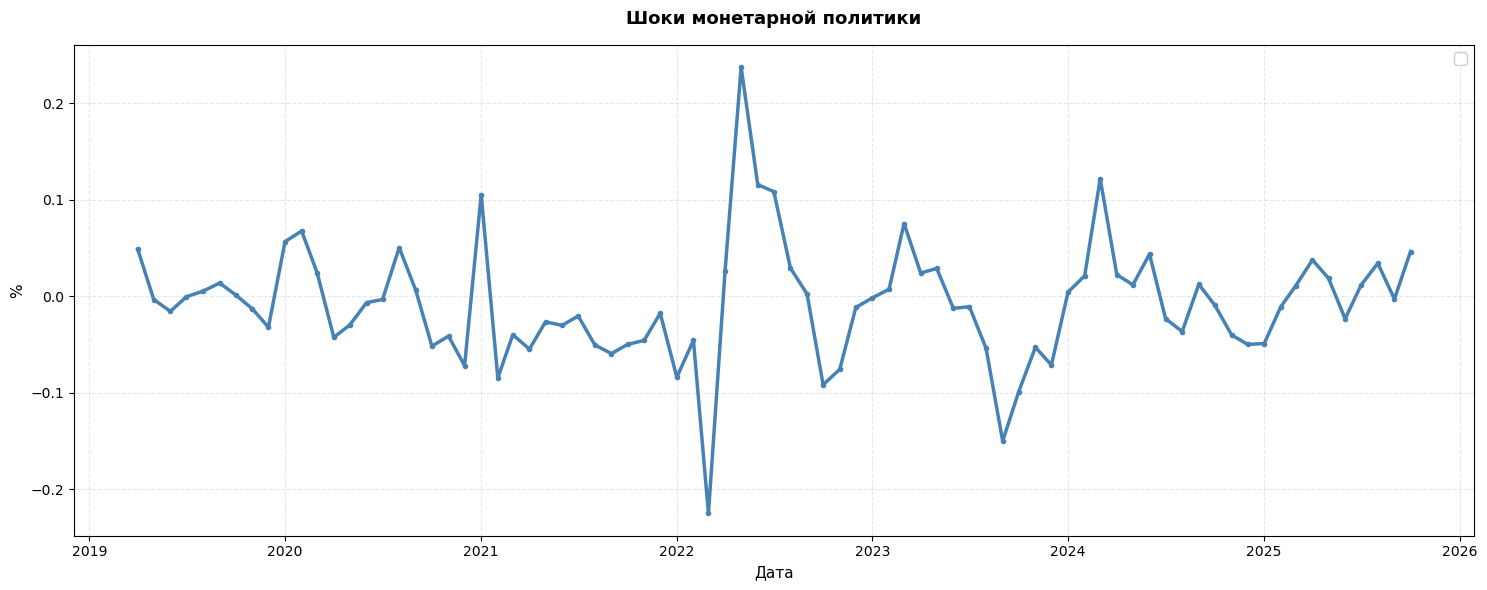


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ШОКИ МОНЕТАРНОЙ ПОЛИТИКИ
           Mon_Shock
Среднее    -0.007308
Медиана    -0.009178
Ст. откл.   0.061867
Мин.       -0.224779
Макс.       0.237499


In [798]:
###############################
# ВЫДЕЛЕНИЕ ШОКОВ МОНЕТАРНОЙ ПОЛИТИКИ
###############################
df_taylor['Taylor_Predicted'] = model9.fittedvalues
df_taylor['Mon_Shock'] = df_taylor['D_log_Nominal_Percent_Rate'] - df_taylor['Taylor_Predicted']

print("\n" + "="*60)
print("Визуализация шоков монетарной политики")
print("="*60)

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df_taylor['Date'], df_taylor['Mon_Shock'], 
         linewidth=2.5, color='steelblue', linestyle='-', marker='o', markersize=3)
ax1.set_title('Шоки монетарной политики', 
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.95)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylabel('%', fontsize=11)
ax1.set_xlabel('Дата', fontsize=11)
ax1.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.show()

###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ
###############################
# ИСПРАВЛЕНИЕ: descriptive_df это Series, работаем с ней как с Series
shock_series = df_taylor['Mon_Shock'].dropna()

desc_stats = {
    'Среднее': shock_series.mean(),
    'Медиана': shock_series.median(),
    'Ст. откл.': shock_series.std(),
    'Мин.': shock_series.min(),
    'Макс.': shock_series.max()
}

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ШОКИ МОНЕТАРНОЙ ПОЛИТИКИ")
print("="*60)

desc_df = pd.DataFrame(desc_stats, index=['Mon_Shock']).T
print(desc_df.round(6).to_string())

In [799]:
###############################
    #Тест на стационарность для шоков монетарной политики
###############################
variables_to_test = ['Mon_Shock']

df_test = df_taylor[variables_to_test]

stationarity_results = []
for var in variables_to_test:
    result = stationarity_tests(df_taylor[var], var)
    stationarity_results.append(result)

stationarity_df = pd.DataFrame(stationarity_results)
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ДЛЯ ШОКОВ")
print("="*60)
print(stationarity_df.to_string())


РЕЗУЛЬТАТЫ ТЕСТОВ ДЛЯ ШОКОВ
    Variable  ADF_Statistic   ADF_p_value  ADF_Critical_1%  ADF_Critical_5%  ADF_Critical_10%  ADF_Stationary  KPSS_Statistic  KPSS_p_value  KPSS_Critical_1%  KPSS_Critical_5%  KPSS_Critical_10%  KPSS_Stationary  DF_GLS_Statistic  DF_GLS_p_value  DF_GLS_Critical_1%  DF_GLS_Critical_5%  DF_GLS_Critical_10%  DF_GLS_Stationary
0  Mon_Shock      -5.689983  8.113084e-07        -3.517114        -2.899375         -2.586955            True        0.053837           0.1             0.739             0.463              0.347             True          -4.72405        0.000004            -2.80509           -2.184101            -1.873412               True


In [800]:
##############################
# Тест Фридмана на сезонность
##############################
variables_for_analysis = [
    ('Mon_Shock', 'Шоки монетарной политики')]
friedman_results = []

for var_col, var_name in variables_for_analysis:
    if var_col in df_taylor.columns:
        result = friedman_seasonality_test(df_taylor, date_col='Date', 
                                          value_col=var_col, 
                                          test_name=var_name)
        if result:
            friedman_results.append(result)

# Сохраняем результаты Фридмана
friedman_summary = pd.DataFrame([
    {
        'Variable': r['variable'],
        'Chi_Squared': r['chi_squared'],
        'P_Value': r['p_value'],
        'Has_Seasonality': r['has_seasonality'],
        'N_Years': r['n_years'],
        'N_Months': r['n_months']
    } 
    for r in friedman_results
])

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА")
print("="*80)
print(friedman_summary.to_string(index=False))


РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                Variable  Chi_Squared  P_Value  Has_Seasonality  N_Years  N_Months
Шоки монетарной политики    14.753846 0.194046            False        5        12



ЯДЕРНАЯ ОЦЕНКА ПЛОТНОСТИ РАСПРЕДЕЛЕНИЯ ОСТАТКОВ МОДЕЛИ


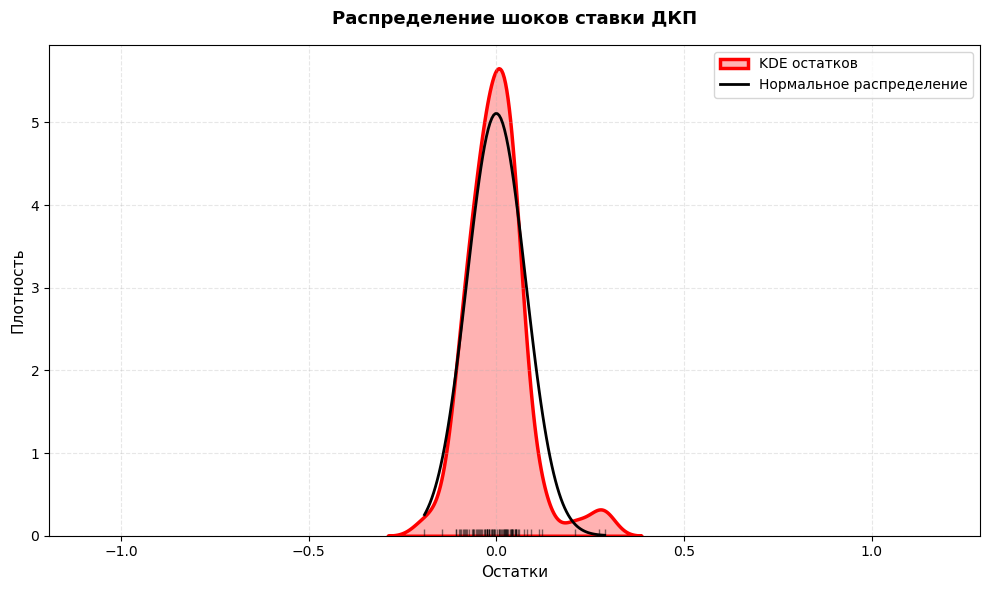


Параметры распределения:
  Среднее остатков: -0.000000
  Стд. отклонение: 0.078086
  Асимметрия (Skewness): 1.0940
  Эксцесс (Kurtosis): 3.2527
  N наблюдений: 79


In [801]:
###############################
# Ядерная оценка плотности распределения остатков
###############################
from scipy import stats
# Получаем остатки из лучшей модели
residuals = model9.resid

print("\n" + "="*80)
print("ЯДЕРНАЯ ОЦЕНКА ПЛОТНОСТИ РАСПРЕДЕЛЕНИЯ ОСТАТКОВ МОДЕЛИ")
print("="*80)

fig, ax = plt.subplots(figsize=(10, 6))

# KDE + гистограмма
sns.kdeplot(residuals, fill=True, color='red', alpha=0.3, linewidth=2.5, label='KDE остатков')

# Нормальное распределение для сравнения
mu = residuals.mean()
sigma = residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
normal_dist = stats.norm.pdf(x, mu, sigma)
ax.plot(x, normal_dist, 'k-', linewidth=2, label='Нормальное распределение')

# Галочки остатков внизу оси X
for residual in residuals:
    ax.plot(residual, 0, '|', color='black', markersize=10, alpha=0.5)

ax.set_title('Распределение шоков ставки ДКП', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Остатки', fontsize=11)
ax.set_ylabel('Плотность', fontsize=11)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim(residuals.min() - 1, residuals.max() + 1)

plt.tight_layout()
plt.show()

print(f"\nПараметры распределения:")
print(f"  Среднее остатков: {residuals.mean():.6f}")
print(f"  Стд. отклонение: {residuals.std():.6f}")
print(f"  Асимметрия (Skewness): {stats.skew(residuals):.4f}")
print(f"  Эксцесс (Kurtosis): {stats.kurtosis(residuals):.4f}")
print(f"  N наблюдений: {len(residuals)}")


In [802]:
###############################
# Переходим к анализу панельных данных
###############################

if isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.reset_index() 

# Преобразуем Date
df_reg['Date'] = pd.to_datetime(df_reg['Date'])

# ============ ФЕДЕРАЛЬНЫЕ ПЕРЕМЕННЫЕ ============

df_shocks = df_taylor[['Date', 'Mon_Shock']].copy()
df_reg = df_reg.merge(df_shocks, on='Date', how='left')

df_exc = df_RF[['Date', 'exc_rate_diff']].copy()
df_reg = df_reg.merge(df_exc, on='Date', how='left')

df_infl = df_RF[['Date', 'Inflation_Expectations']].copy()
df_reg = df_reg.merge(df_infl, on='Date', how='left')

df_bond = df_RF[['Date', 'Bonds_Rate_Correct_5Y']].copy()
df_reg = df_reg.merge(df_bond, on='Date', how='left')

# Переименование
df_reg.rename(columns={'exc_rate_diff': 'd_exc_rate'}, inplace=True)

# Создаем лаги
df_reg['Int_Rate_FL_lag1'] = df_reg.groupby('Region')['Int_Rate_FL'].shift(1)
df_reg['Int_Rate_Mort_lag1'] = df_reg.groupby('Region')['Int_Rate_Mort'].shift(1)
df_reg['Int_Rate_ConsCred_lag1'] = df_reg.groupby('Region')['Int_Rate_ConsCred'].shift(1)

# СПИСОК ПЕРЕМЕННЫХ
initial_vars = [
    'Int_Rate_FL',
    'Int_Rate_FL_lag1',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_Mort_lag1',
    'Int_Rate_ConsCred',
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
   # 'New_Loans_Progr',
    'New_Loans_Fl',
    'New_Loans_Mort',
    'New_Loans_ConsCred',
    'Mon_Shock',
    'd_exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y'
]

df_reg_analys = df_reg[['Region', 'Date'] + initial_vars].copy()


In [803]:
df_reg_analys = df_reg_analys[df_reg['Region'] != 'Москва']
df_reg_analys = df_reg_analys[df_reg['Region'] != 'Чеченская Республика']

In [804]:
df_reg_analys['Region'].unique()

array(['Белгородская область', 'Брянская область', 'Владимирская область',
       'Воронежская область', 'Ивановская область', 'Тверская область',
       'Калужская область', 'Костромская область', 'Курская область',
       'Липецкая область', 'г. Москва', 'Московская область',
       'Орловская область', 'Рязанская область', 'Смоленская область',
       'Тамбовская область', 'Тульская область', 'Ярославская область',
       'Архангельская область', 'в том числе Ненецкий автономный округ',
       'Вологодская область', 'Калининградская область',
       'г. Санкт-Петербург', 'Ленинградская область',
       'Мурманская область', 'Новгородская область', 'Псковская область',
       'Республика Карелия', 'Республика Коми', 'Краснодарский край',
       'Астраханская область', 'Волгоградская область', 'Республика Крым',
       'г. Севастополь', 'Ростовская область', 'Республика Адыгея',
       'Республика Калмыкия', 'Нижегородская область',
       'Кировская область', 'Самарская область', 'Ор

In [805]:
#df_reg_analys = df_reg_analys.dropna()

In [806]:
df_reg_analys.head()

,Region,Date,Int_Rate_FL,Int_Rate_FL_lag1,Int_Rate_Mort,Credit_impulse,Int_Rate_Mort_lag1,Int_Rate_ConsCred,Int_Rate_ConsCred_lag1,Cred_nagr,...,Def_Zadolg_Mort,Def_Zadolg_ConsCred,New_Loans_Progr,New_Loans_Fl,New_Loans_Mort,New_Loans_ConsCred,Mon_Shock,d_exc_rate,Inflation_Expectations,Bonds_Rate_Correct_5Y
0,Белгородская область,2019-02-01,13.637133,NaN,9.822596,-2.177079,NaN,14.919927,NaN,0.327789,...,0.806700,7.814290,NaN,7.772274e+06,1.283299e+06,6.488975e+06,NaN,-0.702019,10.362319,0.274500
1,Белгородская область,2019-03-01,13.764491,13.637133,10.119091,0.715653,9.822596,15.090566,14.919927,0.332653,...,0.781257,7.793962,NaN,8.598020e+06,1.581850e+06,7.016170e+06,NaN,-0.718268,10.144295,0.292500
2,Белгородская область,2019-04-01,13.988365,13.764491,10.431156,1.734442,10.119091,15.022465,15.090566,0.336535,...,0.771662,7.140479,NaN,9.938011e+06,1.535489e+06,8.402522e+06,0.049088,-0.489152,9.004132,0.316818
3,Белгородская область,2019-05-01,13.975779,13.988365,10.629171,2.897391,10.431156,14.943737,15.022465,0.341271,...,0.768352,7.078234,NaN,1.042482e+07,1.654725e+06,8.770090e+06,-0.003213,0.215601,9.416996,0.295714
4,Белгородская область,2019-06-01,14.197338,13.975779,10.697008,2.214858,10.629171,15.138499,14.943737,0.342186,...,0.771485,7.024847,NaN,9.595191e+06,1.375143e+06,8.220047e+06,-0.015468,-0.649656,9.280142,0.197895


In [807]:
df_reg_analys.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6804 entries, 0 to 6803
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Region                  6804 non-null   object        
 1   Date                    6804 non-null   datetime64[ns]
 2   Int_Rate_FL             6804 non-null   float64       
 3   Int_Rate_FL_lag1        6720 non-null   float64       
 4   Int_Rate_Mort           6804 non-null   float64       
 5   Credit_impulse          6804 non-null   float64       
 6   Int_Rate_Mort_lag1      6720 non-null   float64       
 7   Int_Rate_ConsCred       6804 non-null   float64       
 8   Int_Rate_ConsCred_lag1  6720 non-null   float64       
 9   Cred_nagr               6636 non-null   float64       
 10  D_top5_rozn             6804 non-null   float64       
 11  Fin_Dostup              6804 non-null   float64       
 12  Cred_structure          6804 non-null   float64      

In [824]:
print("\n" + "="*70)
print("ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR")
print("="*70)

def detect_outlier_regions_iqr(df, key_vars, min_obs=60, max_na_pct=0.3):
    """
    Определение выбросов по IQR (межквартильный размах)
    """
    region_stats = []
    
    for region in df['Region'].unique():
        reg_data = df[df['Region'] == region][key_vars].dropna()
        
        # 1. Минимум наблюдений
        n_obs = len(reg_data)
        if n_obs < min_obs:
            region_stats.append({
                'Region': region,
                'N_obs': n_obs,
                'Reason': f'Мало данных (<{min_obs})',
                'Status': 'EXCLUDE'
            })
            continue
        
        # 2. % пропусков
        total_rows = len(df[df['Region'] == region])
        na_pct = 1 - (n_obs / total_rows)
        if na_pct > max_na_pct:
            region_stats.append({
                'Region': region,
                'N_obs': n_obs,
                'NA_pct': f'{na_pct:.1%}',
                'Reason': f'Много пропусков (>{max_na_pct*100}%)',
                'Status': 'EXCLUDE'
            })
            continue
        
        # 3. IQR по переменным
        iqr_outliers = []
        for col in key_vars:
            if col in reg_data.columns:
                data = reg_data[col].dropna()
                if len(data) > 0:
                    Q1 = data.quantile(0.2)
                    Q3 = data.quantile(0.8)
                    IQR = Q3 - Q1
                    lower_bound = Q1 - 1.5 * IQR
                    upper_bound = Q3 + 1.5 * IQR
                    outliers = ((data < lower_bound) | (data > upper_bound)).sum()
                    iqr_outliers.append(outliers)
        
        iqr_total = sum(iqr_outliers)
        iqr_pct = iqr_total / n_obs if n_obs > 0 else 0
        
        # РЕШЕНИЕ
        status = 'KEEP'
        reasons = []
        
        if iqr_pct > 0.2:  # >20% выбросов по IQR
            reasons.append(f'Много выбросов по IQR ({iqr_pct:.1%})')
            status = 'EXCLUDE'
        
        region_stats.append({
            'Region': region,
            'N_obs': n_obs,
            'NA_pct': f'{na_pct:.1%}',
            'IQR_outliers': iqr_total,
            'IQR_pct': f'{iqr_pct:.1%}',
            'Reasons': '; '.join(reasons),
            'Status': status
        })
    
    return pd.DataFrame(region_stats)

# АНАЛИЗ РЕГИОНОВ ПО IQR
region_quality_iqr = detect_outlier_regions_iqr(df_reg_analys, key_vars, min_obs=60, max_na_pct=0.3)

print(f"\n АНАЛИЗ {len(region_quality_iqr)} РЕГИОНОВ (IQR)")
print(region_quality_iqr.to_string(index=False))

# СТАТИСТИКА
exclude_count = len(region_quality_iqr[region_quality_iqr['Status'] == 'EXCLUDE'])
keep_count = len(region_quality_iqr) - exclude_count

print(f"\n СТАТИСТИКА:")
print(f"Всего регионов: {len(region_quality_iqr)}")
print(f"Исключено: {exclude_count} ({exclude_count/len(region_quality_iqr)*100:.1f}%)")
print(f"Оставлено: {keep_count}")

# СПИСОК ХОРОШИХ РЕГИОНОВ
good_regions_iqr = region_quality_iqr[region_quality_iqr['Status'] == 'KEEP']['Region'].tolist()
print(f"\n Хороших регионов ({len(good_regions_iqr)}):")
print(", ".join(good_regions_iqr[:10]), "..." if len(good_regions_iqr) > 10 else "")

# ФИЛЬТРАЦИЯ ДАННЫХ
df_reg_analys = df_reg_analys[df_reg_analys['Region'].isin(good_regions_iqr)].copy()
print(f"\n Форма после очистки (IQR): {df_reg_clean_iqr.shape}")


ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR

 АНАЛИЗ 84 РЕГИОНОВ (IQR)
                                              Region  N_obs NA_pct  IQR_outliers IQR_pct                       Reasons  Status
                                Белгородская область     77   4.9%             7    9.1%                                  KEEP
                                    Брянская область     77   4.9%             7    9.1%                                  KEEP
                                Владимирская область     77   4.9%             6    7.8%                                  KEEP
                                 Воронежская область     77   4.9%             6    7.8%                                  KEEP
                                  Ивановская область     77   4.9%             6    7.8%                                  KEEP
                                    Тверская область     77   4.9%             6    7.8%                                  KEEP
                                   Калужская область

In [825]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
###############################
descriptive_df = df_reg_analys[[
    'Int_Rate_FL',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_ConsCred',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
    'New_Loans_Progr',
    'New_Loans_Fl',
    'New_Loans_Mort',
    'New_Loans_ConsCred',
    'Mon_Shock',
    'd_exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y'      
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
                             Среднее       Медиана     ст. откл.        Мин.  \
Int_Rate_FL             1.440200e+01  1.328900e+01  3.492000e+00       9.100   
Int_Rate_Mort           8.335000e+00  8.154000e+00  1.258000e+00       3.327   
Credit_impulse         -7.560000e-01 -3.310000e-01  6.461000e+00     -59.204   
Int_Rate_ConsCred       1.819500e+01  1.599100e+01  5.629000e+00      10.494   
Cred_nagr               3.510000e-01  3.590000e-01  9.100000e-02       0.050   
D_top5_rozn             7.830000e-01  7.800000e-01  6.400000e-02       0.614   
Fin_Dostup              1.894200e+01  1.850100e+01  6.408000e+00       2.084   
Cred_structure          4.660000e-01  4.710000e-01  6.700000e-02       0.169   
Def_Zadolg_Fl           4.388000e+00  4.239000e+00  1.599000e+00       1.407   
Def_Zadolg_Mort         6.610000e-01  4.970000e-01  6.560000e-01       0.043   
Def_Zadolg_ConsCred     7.624000e+00  7.507000e+00  2.006000e+00   

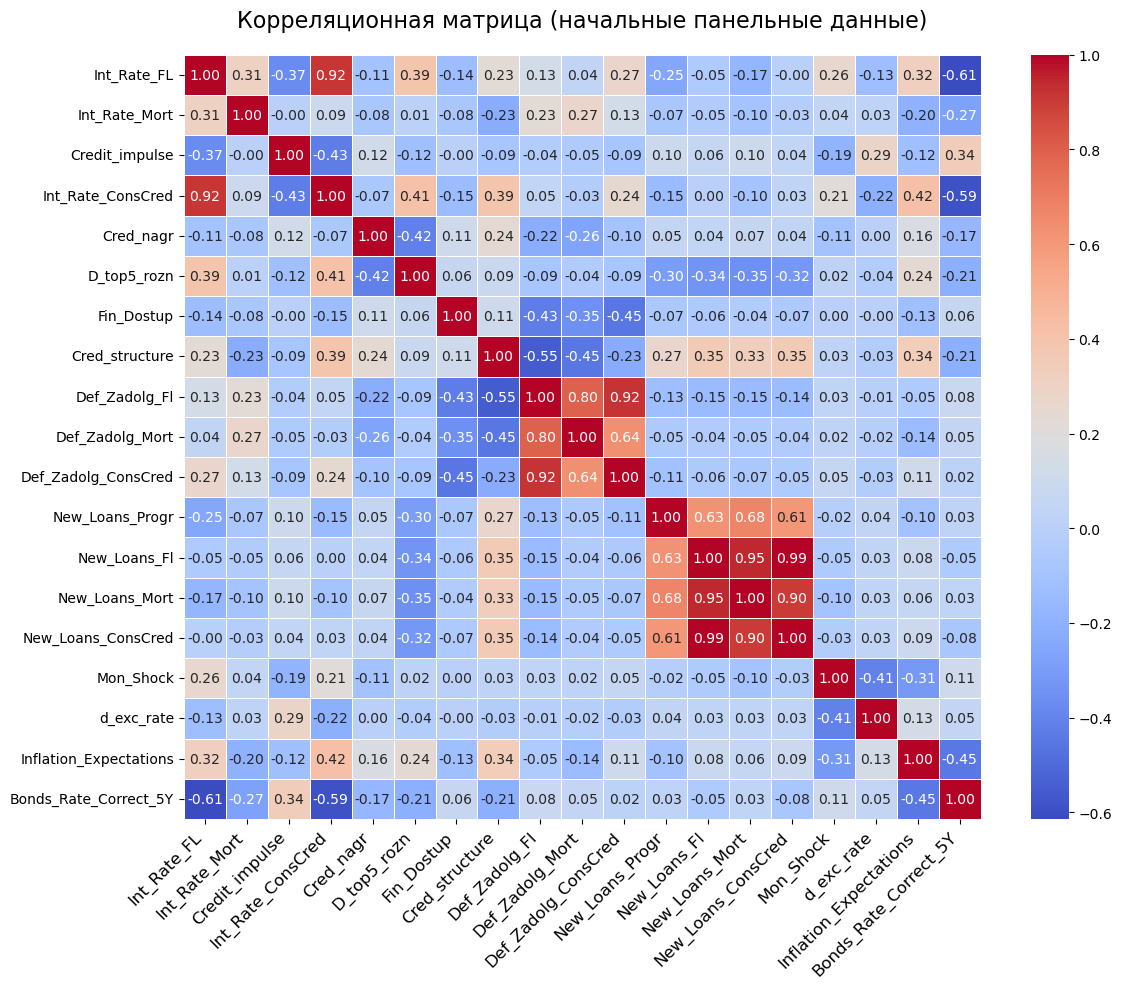

In [826]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (начальные панельные данные)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [830]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 1
###############################

vif_variables = [
    'Int_Rate_FL_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'New_Loans_Progr',
    'Mon_Shock',
    'New_Loans_Fl',
    'Bonds_Rate_Correct_5Y',
    'd_exc_rate',
    'Inflation_Expectations'
]
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 1")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 1
              Variable      VIF
         Def_Zadolg_Fl 2.798503
        Cred_structure 2.544697
 Bonds_Rate_Correct_5Y 2.538509
          New_Loans_Fl 2.099473
Inflation_Expectations 2.087646
             Mon_Shock 1.954449
      Int_Rate_FL_lag1 1.954346
           D_top5_rozn 1.929283
        Credit_impulse 1.797090
             Cred_nagr 1.792544
            d_exc_rate 1.729110
       New_Loans_Progr 1.603186
            Fin_Dostup 1.468798


In [831]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 2
###############################

vif_variables = [
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_ConsCred',
    'New_Loans_Progr',
    'Mon_Shock',
    'New_Loans_ConsCred',
    'Bonds_Rate_Correct_5Y',
    'd_exc_rate',
    'Inflation_Expectations'
]
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 2")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 2
              Variable      VIF
Int_Rate_ConsCred_lag1 2.877053
 Bonds_Rate_Correct_5Y 2.492966
   Def_Zadolg_ConsCred 2.338913
Inflation_Expectations 2.294315
    New_Loans_ConsCred 2.004930
           D_top5_rozn 1.988858
        Credit_impulse 1.972961
        Cred_structure 1.863376
             Mon_Shock 1.832369
             Cred_nagr 1.806491
            d_exc_rate 1.709077
       New_Loans_Progr 1.553823
            Fin_Dostup 1.453414


In [832]:
###############################
    #VIF-анализ - начальные панельные данные спецификация 3
###############################

vif_variables = [
    'Int_Rate_Mort_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Credit_impulse',
    'Cred_structure',
    'Def_Zadolg_Mort',
    'New_Loans_Progr',
    'New_Loans_Mort',
    'Mon_Shock',
    'Bonds_Rate_Correct_5Y',
    'd_exc_rate',
    'Inflation_Expectations'
]
 
df_vif = df_reg_analys[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 3")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ СПЕЦИФИКАЦИЯ 3
              Variable      VIF
 Bonds_Rate_Correct_5Y 2.620018
        New_Loans_Mort 2.376418
       Def_Zadolg_Mort 2.157477
Inflation_Expectations 2.058112
           D_top5_rozn 1.883512
             Mon_Shock 1.871834
    Int_Rate_Mort_lag1 1.843188
        Cred_structure 1.805708
       New_Loans_Progr 1.788396
             Cred_nagr 1.757659
        Credit_impulse 1.670034
            d_exc_rate 1.550412
            Fin_Dostup 1.363370


In [ ]:
# ===== СЕЗОННАЯ КОРРЕКТИРОВКА ДЛЯ ПАНЕЛЬНЫХ ДАННЫХ =====


from statsmodels.tsa.x13 import x13_arima_analysis
import warnings
import tempfile
import uuid

# Заглушаем предупреждения
warnings.filterwarnings('ignore')

# Путь к бинарнику X-13
X13_PATH = 'C:\\Program Files (x86)\\x13as'

# Проверка, что бинарник доступен
if not os.path.exists(X13_PATH):
    raise FileNotFoundError(f"X-13 binary not found at {X13_PATH}")

# Если X13_PATH — полный путь к бинарнику, берем его директорию для x12path
x13_dir = X13_PATH if os.path.isdir(X13_PATH) else os.path.dirname(X13_PATH)

# Создаем папку для логов
os.makedirs("x13_logs", exist_ok=True)

# ============ ОПРЕДЕЛЕНИЕ ПЕРЕМЕННЫХ ДЛЯ КОРРЕКТИРОВКИ ============

# ФЕДЕРАЛЬНЫЕ переменные (одна серия для всех регионов)
federal_variables = {
    'Mon_Shock': 'Монетарный шок',
    'd_exc_rate': 'Курс рубля', 
    'Inflation_Expectations': 'Инфляционные ожидания',
    'Bonds_Rate_Correct_5Y': 'Ставки на облигации скорректированные 5Y'
}

# РЕГИОНАЛЬНЫЕ переменные (серии по каждому региону)
regional_variables = {
    'Int_Rate_FL': 'Ставка на кредиты ФЛ',
    'Int_Rate_Mort': 'Ставка на ипотеку',
    'Int_Rate_ConsCred': 'Ставка на потребительский кредит',
    'Cred_nagr': 'Кредитная нагрузка',
    'New_Loans_Fl': 'Новые кредиты ФЛ',
    'New_Loans_Mort': 'Новые кредиты ипотека',
    'New_Loans_ConsCred': 'Новые кредиты потребит.',
}

# ============ ФУНКЦИЯ ДЛЯ СЕЗОННОЙ КОРРЕКТИРОВКИ ОДНОЙ СЕРИИ ============

def seasonal_adjust_panel_series(series_data, variable_name, region_name=None, min_obs=24):
    """
    Выполнить X-13 сезонную корректировку для одной серии (панельные данные)
    
    Parameters:
    -----------
    series_data : pd.Series
        Временной ряд с DatetimeIndex
    variable_name : str
        Название переменной
    region_name : str, optional
        Название региона (для региональных переменных)
    min_obs : int
        Minimum number of observations
    
    Returns:
    --------
    dict с результатами или None при ошибке
    """
    try:
        # Проверка данных
        if len(series_data) < min_obs:
            return None
        
        # Убедиться, что индекс - DatetimeIndex
        if not isinstance(series_data.index, pd.DatetimeIndex):
            series_data.index = pd.to_datetime(series_data.index)
        
        # Установить частоту на месячную
        ts_regular = series_data.asfreq('MS').dropna()
        
        if len(ts_regular) < min_obs:
            return None
        
        # Информация о данных
        start_date = ts_regular.index[0]
        end_date = ts_regular.index[-1]
        
        # Создаем уникальную временную папку для каждого вызова X-13
        # чтобы избежать конфликтов файлов
        temp_dir = tempfile.mkdtemp(prefix=f"x13_{uuid.uuid4().hex[:8]}_")
        
        # Запуск X-13 с указанием уникальной временной директории
        try:
            res = x13_arima_analysis(
                endog=ts_regular,
                x12path=x13_dir,
                prefer_x13=True,
                outlier=True,
                trading=False,
                print_stdout=False
            )
            
            # Извлечение компонент
            adj = res.seasadj
            trend = res.trend
            seas = ts_regular - adj
            
        except Exception as e:
            # Если X-13 не сработал, попробуем без outlier
            try:
                res = x13_arima_analysis(
                    endog=ts_regular,
                    x12path=x13_dir,
                    prefer_x13=True,
                    outlier=False,  # Без определения выбросов
                    trading=False,
                    print_stdout=False
                )
                
                adj = res.seasadj
                trend = res.trend
                seas = ts_regular - adj
                
            except Exception as e2:
                # Если все еще не работает, пропускаем
                return None
        
        # Расчёт эффективности
        original_std = ts_regular.std()
        adj_std = adj.std()
        reduction = 100 * (1 - adj_std / original_std) if original_std > 0 else 0
        
        # Удаляем временную директорию
        try:
            import shutil
            shutil.rmtree(temp_dir, ignore_errors=True)
        except:
            pass
        
        return {
            'dates': ts_regular.index,
            'adj': adj.values,
            'trend': trend.values,
            'seasonal': seas.values,
            'reduction': reduction
        }
        
    except Exception as e:
        # Подавляем вывод ошибок
        return None

# ============ ОБРАБОТКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ ============

print("\n" + "="*70)
print("СЕЗОННАЯ КОРРЕКТИРОВКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ")
print("="*70)

federal_adjusted = {}

for col, name in federal_variables.items():
    if col not in df_reg_analys.columns:
        print(f"\n⚠️  {name} ({col}): столбец не найден. Пропуск.")
        continue
    
    print(f"\n{name} ({col}):")
    
    # Для федеральных переменных берем уникальные значения по датам
    fed_data = df_reg_analys[['Date', col]].copy().dropna()
    
    if len(fed_data) == 0:
        print(f"  ✗ Нет данных. Пропуск.")
        continue
    
    # Убедиться, что одно значение на дату
    fed_data = fed_data.drop_duplicates('Date')
    fed_data = fed_data.set_index('Date')[col].sort_index()
    
    # Сезонная корректировка
    result = seasonal_adjust_panel_series(fed_data, col, region_name=None)
    
    if result is not None:
        federal_adjusted[col] = result
        print(f"  ✓ Успешно скорректировано, снижение волатильности: {result['reduction']:.1f}%")
        
        # Добавляем результаты обратно в df_reg_analys
        for date, adj_val, trend_val, seas_val in zip(
            result['dates'], result['adj'], result['trend'], result['seasonal']
        ):
            mask = df_reg_analys['Date'] == date
            df_reg_analys.loc[mask, f'{col}_adj'] = adj_val
            df_reg_analys.loc[mask, f'{col}_trend'] = trend_val
            df_reg_analys.loc[mask, f'{col}_seasonal'] = seas_val
    else:
        print(f"  ✗ Не удалось скорректировать")

# ============ ОБРАБОТКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ ============

print("\n" + "="*70)
print("СЕЗОННАЯ КОРРЕКТИРОВКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ")
print("="*70)

regional_adjusted = {}

for col, name in regional_variables.items():
    if col not in df_reg_analys.columns:
        print(f"\n⚠️  {name} ({col}): столбец не найден. Пропуск.")
        continue
    
    print(f"\n{name} ({col}):")
    
    # Получаем список регионов
    regions = df_reg_analys['Region'].unique()
    print(f"  Обрабатываю {len(regions)} регионов...")
    
    regional_adjusted[col] = {}
    successful_regions = 0
    
    for region in regions:
        # Фильтруем данные по региону
        region_data = df_reg_analys[df_reg_analys['Region'] == region][['Date', col]].copy().dropna()
        
        if len(region_data) < 24:
            continue  # Пропускаем регионы с недостаточным количеством данных
        
        # Подготавливаем временной ряд
        region_series = region_data.set_index('Date')[col].sort_index()
        
        # Сезонная корректировка
        result = seasonal_adjust_panel_series(region_series, col, region_name=region, min_obs=24)
        
        if result is not None:
            regional_adjusted[col][region] = result
            successful_regions += 1
            
            # Добавляем результаты в df_reg_analys
            for date, adj_val, trend_val, seas_val in zip(
                result['dates'], result['adj'], result['trend'], result['seasonal']
            ):
                mask = (df_reg_analys['Region'] == region) & (df_reg_analys['Date'] == date)
                if mask.any():
                    df_reg_analys.loc[mask, f'{col}_adj'] = adj_val
                    df_reg_analys.loc[mask, f'{col}_trend'] = trend_val
                    df_reg_analys.loc[mask, f'{col}_seasonal'] = seas_val
    
    print(f"  ✓ Успешно скорректировано {successful_regions}/{len(regions)} регионов")

# ============ ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ ============

print("\n" + "="*70)
print("ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ")
print("="*70)

all_variables = list(regional_variables.keys()) + list(federal_variables.keys())
added_columns = []

for col in all_variables:
    for suffix in ['_adj', '_trend', '_seasonal']:
        new_col = f'{col}{suffix}'
        if new_col in df_reg_analys.columns:
            added_columns.append(new_col)
            non_na_count = df_reg_analys[new_col].notna().sum()
            print(f"✓ {new_col}: {non_na_count} не-NaN значений")

print(f"\n✓ Всего добавлено столбцов: {len(added_columns)}")

# ============ СВОДКА РЕЗУЛЬТАТОВ ============

print("\n" + "="*70)
print("СВОДКА РЕЗУЛЬТАТОВ СЕЗОННОЙ КОРРЕКТИРОВКИ")
print("="*70)

# Федеральные переменные
print("\nФедеральные переменные:")
print("-" * 50)
print(f"{'Переменная':<30} {'Волатильность ↓':<15}")
print("-" * 50)

for col in federal_variables:
    adj_col = f'{col}_adj'
    if adj_col in df_reg_analys.columns and col in federal_adjusted:
        reduction = federal_adjusted[col]['reduction']
        print(f"{federal_variables[col]:<30} {reduction:>14.1f}%")

# Региональные переменные (среднее по регионам)
print("\n\nРегиональные переменные (среднее по регионам):")
print("-" * 50)
print(f"{'Переменная':<30} {'Волатильность ↓':<15}")
print("-" * 50)

for col in regional_variables:
    adj_col = f'{col}_adj'
    if adj_col in df_reg_analys.columns and col in regional_adjusted:
        # Рассчитываем среднее снижение волатильности
        reductions = []
        for region_data in regional_adjusted[col].values():
            reductions.append(region_data['reduction'])
        
        if reductions:
            avg_reduction = np.mean(reductions)
            print(f"{regional_variables[col]:<30} {avg_reduction:>14.1f}%")

# ============ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ============

print("\n" + "="*70)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ (ПРИМЕРЫ)")
print("="*70)

# Выбираем несколько регионов для визуализации
sample_regions = df_reg_analys['Region'].unique()[:3]  # Первые 3 региона

# Визуализация для нескольких переменных
for col in list(regional_variables.keys())[:2]:  # Первые 2 региональные переменные
    adj_col = f'{col}_adj'
    
    if adj_col not in df_reg_analys.columns:
        continue
    
    for region in sample_regions:
        # Фильтруем данные для региона
        region_mask = (df_reg_analys['Region'] == region) & df_reg_analys[adj_col].notna()
        region_data = df_reg_analys[region_mask]
        
        if len(region_data) == 0:
            continue
        
        # Создаем график
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        
        # График 1: Исходный vs скорректированный
        ax = axes[0, 0]
        dates = region_data['Date']
        ax.plot(dates, region_data[col], label='Исходный', alpha=0.6, linewidth=1)
        ax.plot(dates, region_data[adj_col], label='Сезонно скорр.', linewidth=1.5)
        ax.set_title(f'{regional_variables[col]}\nРегион: {region}')
        ax.legend()
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        
        # График 2: Сезонная компонента
        ax = axes[0, 1]
        seasonal_col = f'{col}_seasonal'
        if seasonal_col in region_data.columns:
            ax.plot(dates, region_data[seasonal_col], color='red', linewidth=1.5)
            ax.axhline(0, color='black', linestyle='--', alpha=0.3)
            ax.set_title('Сезонная компонента')
            ax.grid(alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
        
        # График 3: Тренд
        ax = axes[1, 0]
        trend_col = f'{col}_trend'
        if trend_col in region_data.columns:
            ax.plot(dates, region_data[trend_col], color='green', linewidth=1.5)
            ax.set_title('Тренд')
            ax.grid(alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
        
        # График 4: Статистика
        ax = axes[1, 1]
        ax.axis('off')
        
        # Расчет статистик
        if len(region_data) > 0:
            original_std = region_data[col].std()
            adj_std = region_data[adj_col].std()
            reduction = 100 * (1 - adj_std / original_std) if original_std > 0 else 0
            
            stats_text = f"Статистика для {region}:\n\n"
            stats_text += f"Период: {region_data['Date'].min().strftime('%Y-%m')} - {region_data['Date'].max().strftime('%Y-%m')}\n"
            stats_text += f"Наблюдений: {len(region_data)}\n"
            stats_text += f"Снижение волатильности: {reduction:.1f}%\n"
            stats_text += f"Стд. откл. до: {original_std:.4f}\n"
            stats_text += f"Стд. откл. после: {adj_std:.4f}"
            
            ax.text(0.1, 0.5, stats_text, fontsize=10, va='center', linespacing=1.5)
        
        plt.tight_layout()
        
        # Сохраняем график
        region_safe = region.replace('/', '_').replace('\\', '_').replace(':', '_')
        filename = f'x13_logs/panel_{col}_{region_safe}_seasonal.png'
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

# Визуализация для федеральных переменных
print("\nГрафики федеральных переменных...")

for col, name in federal_variables.items():
    adj_col = f'{col}_adj'
    
    if adj_col not in df_reg_analys.columns:
        continue
    
    # Фильтруем данные
    fed_mask = df_reg_analys[adj_col].notna()
    fed_data = df_reg_analys[fed_mask].drop_duplicates('Date')
    
    if len(fed_data) == 0:
        continue
    
    # Создаем график
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # График 1: Исходный vs скорректированный
    ax = axes[0, 0]
    dates = fed_data['Date']
    ax.plot(dates, fed_data[col], label='Исходный', alpha=0.6, linewidth=1)
    ax.plot(dates, fed_data[adj_col], label='Сезонно скорр.', linewidth=1.5)
    ax.set_title(f'{name}\nФедеральная переменная')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    # График 2: Сезонная компонента
    ax = axes[0, 1]
    seasonal_col = f'{col}_seasonal'
    if seasonal_col in fed_data.columns:
        ax.plot(dates, fed_data[seasonal_col], color='red', linewidth=1.5)
        ax.axhline(0, color='black', linestyle='--', alpha=0.3)
        ax.set_title('Сезонная компонента')
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    # График 3: Тренд
    ax = axes[1, 0]
    trend_col = f'{col}_trend'
    if trend_col in fed_data.columns:
        ax.plot(dates, fed_data[trend_col], color='green', linewidth=1.5)
        ax.set_title('Тренд')
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    # График 4: Статистика
    ax = axes[1, 1]
    ax.axis('off')
    
    # Расчет статистик
    if len(fed_data) > 0 and col in federal_adjusted:
        reduction = federal_adjusted[col]['reduction']
        original_std = fed_data[col].std()
        adj_std = fed_data[adj_col].std()
        
        stats_text = f"Статистика для {name}:\n\n"
        stats_text += f"Период: {fed_data['Date'].min().strftime('%Y-%m')} - {fed_data['Date'].max().strftime('%Y-%m')}\n"
        stats_text += f"Наблюдений: {len(fed_data)}\n"
        stats_text += f"Снижение волатильности: {reduction:.1f}%\n"
        stats_text += f"Стд. откл. до: {original_std:.4f}\n"
        stats_text += f"Стд. откл. после: {adj_std:.4f}"
        
        ax.text(0.1, 0.5, stats_text, fontsize=10, va='center', linespacing=1.5)
    
    plt.tight_layout()
    
    # Сохраняем график
    filename = f'x13_logs/federal_{col}_seasonal.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# ============ ФИНАЛЬНАЯ СТАТИСТИКА ============

print("\n" + "="*70)
print("ФИНАЛЬНАЯ СТАТИСТИКА")
print("="*70)

print(f"\nОбработано федеральных переменных: {len(federal_adjusted)}/{len(federal_variables)}")
print(f"Обработано региональных переменных: {len(regional_adjusted)}/{len(regional_variables)}")
print(f"Общее количество добавленных столбцов: {len(added_columns)}")
print(f"Форма df_reg_analys: {df_reg_analys.shape}")

# Проверяем наличие столбцов с суффиксами
adj_columns = [col for col in df_reg_analys.columns if col.endswith('_adj')]
trend_columns = [col for col in df_reg_analys.columns if col.endswith('_trend')]
seasonal_columns = [col for col in df_reg_analys.columns if col.endswith('_seasonal')]

print(f"\nСтолбцов _adj: {len(adj_columns)}")
print(f"Столбцов _trend: {len(trend_columns)}")
print(f"Столбцов _seasonal: {len(seasonal_columns)}")

print("\n✓ Скорректированные ряды добавлены в df_reg_analys")
print("✓ Столбцы с суффиксами: _adj (скорр.), _trend (тренд), _seasonal (сезон)")

# Сортируем по дате и региону
df_reg_analys = df_reg_analys.sort_values(['Region', 'Date']).reset_index(drop=True)


СЕЗОННАЯ КОРРЕКТИРОВКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ

Монетарный шок (Mon_Shock):
  ✓ Успешно скорректировано, снижение волатильности: 5.9%

Курс рубля (d_exc_rate):
  ✓ Успешно скорректировано, снижение волатильности: 2.8%

Инфляционные ожидания (Inflation_Expectations):
  ✓ Успешно скорректировано, снижение волатильности: 4.5%

Ставки на облигации скорректированные 5Y (Bonds_Rate_Correct_5Y):
  ✓ Успешно скорректировано, снижение волатильности: 2.6%

СЕЗОННАЯ КОРРЕКТИРОВКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ

Ставка на кредиты ФЛ (Int_Rate_FL):
  Обрабатываю 77 регионов...
  ✓ Успешно скорректировано 34/77 регионов

Ставка на ипотеку (Int_Rate_Mort):
  Обрабатываю 77 регионов...
  ✓ Успешно скорректировано 38/77 регионов

Ставка на потребительский кредит (Int_Rate_ConsCred):
  Обрабатываю 77 регионов...
  ✓ Успешно скорректировано 35/77 регионов

Кредитная нагрузка (Cred_nagr):
  Обрабатываю 77 регионов...
  ✓ Успешно скорректировано 28/77 регионов

Новые кредиты ФЛ (New_Loans_Fl):
  Обрабатываю 77 ре

In [ ]:
with (robjects.default_converter + pandas2ri.converter).context():
  r_from_pd_df = robjects.conversion.get_conversion().py2rpy(df_reg_analys)

r_from_pd_df

In [ ]:
#utils = importr('utils')

# Установить все зависимости
#robjects.r('''
#packages <- c('rbibutils', 'bdsmatrix', 'collapse', 'zoo', 'sandwich', 'lmtest', 'Formula', 'maxLik', 'plm')
#install.packages(packages)
#''')


#plm = importr('plm')

In [ ]:
df_reg_analys.info()

In [ ]:
###############################
    #Анализ стационарности панельных данных 
###############################
def safe_decode_output(x):
    if isinstance(x, bytes):
        for encoding in ['utf-8', 'windows-1251', 'cp1252', 'latin-1']:
            try:
                return x.decode(encoding)
            except:
                continue
        return x.decode('utf-8', errors='replace')
    return x

rpy2.rinterface_lib.callbacks.consolewrite_print = safe_decode_output
rpy2.rinterface_lib.callbacks.consolewrite_warnerror = safe_decode_output

robjects.r('''
    options(encoding = "UTF-8")
    Sys.setenv(LANG = "en_US.UTF-8")
''')

base_converter = robjects.default_converter + pandas2ri.converter

# === ПЕРЕДАЧА ДАННЫХ В R ===
with localconverter(base_converter):
    r_from_pd_df = robjects.conversion.py2rpy(df_reg_analys)

globalenv['r_from_pd_df'] = r_from_pd_df

utils = importr('utils')

# Установка необходимых пакетов
robjects.r('''
packages <- c('plm', 'urca', 'lmtest', 'sandwich', 'tseries')
for (pkg in packages) {
  if (!require(pkg, character.only = TRUE)) {
    install.packages(pkg)
  }
}
''')

plm = importr('plm')
tseries = importr('tseries')

# === ПОЛУЧЕНИЕ ПЕРЕМЕННЫХ ===
panel_vars = [col for col in df_reg_analys.columns if col not in ['Date', 'Region', 'Mon_Shock', 'Int_Rate_FL_lag1', 'Int_Rate_Mort_lag1', 'Int_Rate_ConsCred_lag1', 'd_exc_rate']]
print(f"Testing {len(panel_vars)} variables for unit roots")
print("="*70)

panel_vars_r = 'c({})'.format(', '.join(f'"{v}"' for v in panel_vars))

# === ПРОВЕДЕНИЕ ТЕСТОВ (с PP и DF-GLS) ===
robjects.r(f'''
library(plm)
library(urca)
library(tseries)

pdf <- pdata.frame(r_from_pd_df, index = c("Region", "Date"))
panel_vars <- {panel_vars_r}

results_df <- data.frame(
  Variable = character(),
  Hadri_Test_Stat = numeric(),
  Hadri_PValue = numeric(),
  PP_Individual_Mean = numeric(),
  PP_Individual_Median = numeric(),
  PP_Rejections = numeric(),
  DFGLS_Individual_Mean = numeric(),
  DFGLS_Individual_Median = numeric(),
  DFGLS_Rejections = numeric(),
  stringsAsFactors = FALSE
)

for (var in panel_vars) {{
  
  tryCatch({{
    x <- pdf[[var]]
    x_clean <- na.omit(x)
    
    if (length(x_clean) > 10) {{
      
      # Hadri тест (панельный тест на стационарность)
      hadri_stat <- NA
      hadri_pval <- NA
      tryCatch({{
        # Для Hadri теста можно использовать исходный вектор
        hadri_res <- purtest(x_clean, exo = "trend", test = "hadri")
        hadri_stat <- as.numeric(hadri_res$statistic$statistic)
        hadri_pval <- as.numeric(hadri_res$statistic$p.value)
      }}, error = function(e) {{
        cat("Hadri test error for", var, ":", e$message, "\\n")
      }})
      
      # PP тест по регионам (Phillips-Perron)
      pp_stats <- c()
      pp_pvalues <- c()
      pp_rejections <- 0
      regions <- unique(pdf$Region)
      
      for (region in regions) {{
        region_data <- pdf[pdf$Region == region, var]
        region_data <- na.omit(as.numeric(region_data))
        
        if (length(region_data) > 5) {{  # минимум 5 наблюдений
          tryCatch({{
            # PP тест
            pp_test <- pp.test(region_data)
            pp_stat <- pp_test$statistic
            pp_pval <- pp_test$p.value
            
            pp_stats <- c(pp_stats, pp_stat)
            pp_pvalues <- c(pp_pvalues, pp_pval)
            
            # Считаем отвержения H0 (единичный корень) на уровне 5%
            if (pp_pval < 0.05) {{
              pp_rejections <- pp_rejections + 1
            }}
          }}, error = function(e) {{}})
        }}
      }}
      
      # DF-GLS тест по регионам
      dfgls_stats <- c()
      dfgls_rejections <- 0
      
      for (region in regions) {{
        region_data <- pdf[pdf$Region == region, var]
        region_data <- na.omit(as.numeric(region_data))
        
        if (length(region_data) > 5) {{  # минимум 5 наблюдений
          tryCatch({{
            # Используем ur.ers для DF-GLS
            max_lags <- min(4, floor(length(region_data)/3))
            dfgls_test <- ur.ers(region_data, 
                               type = "DF-GLS", 
                               model = "constant",
                               lag.max = max_lags)
            
            if (!is.null(dfgls_test@teststat) && length(dfgls_test@teststat) > 0) {{
              dfgls_stat <- dfgls_test@teststat[1]
              dfgls_stats <- c(dfgls_stats, dfgls_stat)
              
              # Считаем отвержения H0 (единичный корень) на уровне 5%
              # Критическое значение -2.86 для 5% уровня
              if (dfgls_stat < -2.86) {{
                dfgls_rejections <- dfgls_rejections + 1
              }}
            }}
          }}, error = function(e) {{}})
        }}
      }}
      
      # Вычисляем агрегированные статистики
      pp_mean <- NA
      pp_median <- NA
      pp_rejection_rate <- NA
      
      if (length(pp_stats) > 0) {{
        pp_mean <- mean(pp_stats, na.rm = TRUE)
        pp_median <- median(pp_stats, na.rm = TRUE)
        pp_rejection_rate <- (pp_rejections / length(pp_stats)) * 100
      }}
      
      dfgls_mean <- NA
      dfgls_median <- NA
      dfgls_rejection_rate <- NA
      
      if (length(dfgls_stats) > 0) {{
        dfgls_mean <- mean(dfgls_stats, na.rm = TRUE)
        dfgls_median <- median(dfgls_stats, na.rm = TRUE)
        dfgls_rejection_rate <- (dfgls_rejections / length(dfgls_stats)) * 100
      }}
      
      # Добавляем результаты
      new_row <- data.frame(
        Variable = var,
        Hadri_Test_Stat = hadri_stat,
        Hadri_PValue = hadri_pval,
        PP_Individual_Mean = pp_mean,
        PP_Individual_Median = pp_median,
        PP_Rejections = pp_rejection_rate,
        DFGLS_Individual_Mean = dfgls_mean,
        DFGLS_Individual_Median = dfgls_median,
        DFGLS_Rejections = dfgls_rejection_rate,
        stringsAsFactors = FALSE
      )
      
      results_df <- rbind(results_df, new_row)
    }}
  }}, error = function(e) {{
    cat("General error for", var, ":", e$message, "\\n")
  }})
}}

write.csv(results_df, "panel_unit_root_tests_pp_dfgls.csv", row.names = FALSE)
print(results_df)
''')

results = pd.read_csv("panel_unit_root_tests_pp_dfgls.csv")

print("\n" + "="*70)
print("PANEL UNIT ROOT TEST RESULTS (Hadri + PP + DF-GLS)")
print("="*70)

# Интерпретация результатов
results['Hadri_Stationary'] = results['Hadri_PValue'] >= 0.05  # H0: все серии стационарны
results['PP_Stationary'] = results['PP_Rejections'] >= 50  # Более 50% регионов стационарны
results['DFGLS_Stationary'] = results['DFGLS_Rejections'] >= 50  # Более 50% регионов стационарны

# Добавляем общее решение по большинству тестов
results['Overall_Stationary'] = (
    (results['Hadri_Stationary'].astype(int) + 
     results['PP_Stationary'].astype(int) + 
     results['DFGLS_Stationary'].astype(int)) >= 2
)

print(results.to_string(index=False))

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Total variables tested: {len(results)}")
print(f"Hadri test (H0: stationary): {results['Hadri_Stationary'].sum()} stationary")
print(f"PP test: {results['PP_Stationary'].sum()} stationary (≥50% regions)")
print(f"DF-GLS test: {results['DFGLS_Stationary'].sum()} stationary (≥50% regions)")
print(f"Overall (≥2 tests): {results['Overall_Stationary'].sum()} stationary")

In [ ]:
###############################
# Переход к первым разностям панельных данных
# С логарифмированием переменных выдач
###############################

if isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.reset_index()

# ============ ЛОГАРИФМИРОВАНИЕ ВЫДАЧ ============

loan_vars = ['New_Loans_Progr', 'New_Loans_Fl', 'New_Loans_Mort', 'New_Loans_ConsCred']


for var in loan_vars:
    if var in df_reg.columns:
        df_reg[f'ln_{var}'] = np.log(df_reg[var])

# ============ СОЗДАНИЕ ПЕРВЫХ РАЗНОСТЕЙ ============

exclude_cols = ['Region', 'Date', 'Mon_Shock', 'd_exc_rate']
ln_loan_vars = [f'ln_{var}' for var in loan_vars if f'ln_{var}' in df_reg.columns]

# Все остальные переменные (кроме выдач и логарифмов)
initial_vars = [col for col in df_reg.columns 
                if col not in exclude_cols 
                and col not in loan_vars
                and not col.startswith('d_')
                and not col.startswith('ln_')]


# Разности для обычных переменных
for var in initial_vars:
    if var in df_reg.columns:
        df_reg[f'd_{var}'] = df_reg.groupby('Region')[var].diff()

# Разности для логарифмов выдач
print("Создание разностей логарифмов выдач:")
for var in ln_loan_vars:
    d_var = f'd_{var}'  
    if var in df_reg.columns:
        df_reg[d_var] = df_reg.groupby('Region')[var].diff()


# ============ СПИСОК ЭКЗОГЕННЫХ ПЕРЕМЕННЫХ ============

exog_vars = [
    'd_Int_Rate_FL',
    'd_Int_Rate_FL_lag1',
    'd_Int_Rate_Mort',
    'd_Credit_impulse',
    'd_Int_Rate_Mort_lag1',
    'd_Int_Rate_ConsCred',
    'd_Int_Rate_ConsCred_lag1',
    'd_Cred_nagr',
    'd_D_top5_rozn',
    'd_Fin_Dostup',
    'd_Cred_structure',
    'd_Def_Zadolg_Fl',
    'd_Def_Zadolg_Mort',
    'd_Def_Zadolg_ConsCred',
    'd_ln_New_Loans_Progr',     
    'd_ln_New_Loans_Fl',         
    'd_ln_New_Loans_Mort',       
    'd_ln_New_Loans_ConsCred',   
    'd_Inflation_Expectations',
    'd_Bonds_Rate_Correct_5Y',
    'Mon_Shock',
    'd_exc_rate'
]

df_exog = df_reg[['Region', 'Date'] + exog_vars].copy()
df_exog = df_exog.dropna()


In [616]:
df_exog.head()

,Region,Date,d_Int_Rate_FL,d_Int_Rate_FL_lag1,d_Int_Rate_Mort,d_Credit_impulse,d_Int_Rate_Mort_lag1,d_Int_Rate_ConsCred,d_Int_Rate_ConsCred_lag1,d_Cred_nagr,...,d_Def_Zadolg_Mort,d_Def_Zadolg_ConsCred,d_ln_New_Loans_Progr,d_ln_New_Loans_Fl,d_ln_New_Loans_Mort,d_ln_New_Loans_ConsCred,d_Inflation_Expectations,d_Bonds_Rate_Correct_5Y,Mon_Shock,d_exc_rate
61,Белгородская область,2024-03-01,0.953198,4.422236,1.535858,1.650188,0.277513,-0.054464,2.054362,-0.002337,...,0.004178,-0.040008,-0.114279,0.122779,0.076272,0.130523,-0.48,0.198000,0.121941,0.213378
62,Белгородская область,2024-04-01,-1.447260,0.953198,-1.219314,-1.122855,1.535858,-0.269291,-0.054464,-0.004392,...,0.013536,-0.062766,0.620013,0.178234,0.377576,0.141832,-0.56,0.029435,0.022506,1.226933
63,Белгородская область,2024-05-01,-0.393966,-1.447260,-0.177608,1.267953,-1.219314,-0.303073,-0.269291,0.001721,...,0.014517,-0.061703,-2.212626,0.103611,0.110114,0.102272,-0.40,-0.395197,0.011987,-2.351414
64,Белгородская область,2024-06-01,-0.758745,-0.393966,-0.301980,-0.181387,-0.177608,-0.402516,-0.303073,0.004322,...,-0.002758,0.062915,2.547891,0.115357,0.185543,0.100212,0.64,-0.291028,0.043849,-2.850273
65,Белгородская область,2024-07-01,-1.300406,-0.758745,-0.486991,0.419354,-0.301980,1.000912,-0.402516,0.007354,...,-0.004373,-0.160939,-1.807337,0.077303,0.411918,-0.016434,0.10,-0.062906,-0.023131,-0.265230


In [617]:
df_exog.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1530 entries, 61 to 6882
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Region                    1530 non-null   object        
 1   Date                      1530 non-null   datetime64[ns]
 2   d_Int_Rate_FL             1530 non-null   float64       
 3   d_Int_Rate_FL_lag1        1530 non-null   float64       
 4   d_Int_Rate_Mort           1530 non-null   float64       
 5   d_Credit_impulse          1530 non-null   float64       
 6   d_Int_Rate_Mort_lag1      1530 non-null   float64       
 7   d_Int_Rate_ConsCred       1530 non-null   float64       
 8   d_Int_Rate_ConsCred_lag1  1530 non-null   float64       
 9   d_Cred_nagr               1530 non-null   float64       
 10  d_D_top5_rozn             1530 non-null   float64       
 11  d_Fin_Dostup              1530 non-null   float64       
 12  d_Cred_structure        

In [618]:

###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ
###############################
descriptive_df = df_exog[[
    'd_Int_Rate_FL',
    'd_Int_Rate_Mort',
    'd_Credit_impulse',
    'd_Int_Rate_ConsCred',
    'd_Cred_nagr',
    'd_D_top5_rozn',
    'd_Fin_Dostup',
    'd_Cred_structure',
    'd_Def_Zadolg_Fl',
    'd_Def_Zadolg_Mort',
    'd_Def_Zadolg_ConsCred',
    'd_ln_New_Loans_Progr',     
    'd_ln_New_Loans_Fl',         
    'd_ln_New_Loans_Mort',       
    'd_ln_New_Loans_ConsCred',   
    'd_Inflation_Expectations',
    'd_Bonds_Rate_Correct_5Y',
    'Mon_Shock',
    'd_exc_rate'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ
                          Среднее  Медиана  ст. откл.    Мин.   Макс.
d_Int_Rate_FL               0.047   -0.233      1.847  -8.684  11.884
d_Int_Rate_Mort            -0.064   -0.173      1.109  -6.453   7.387
d_Credit_impulse           -0.217   -0.109      7.095 -44.967  38.978
d_Int_Rate_ConsCred         0.269    0.279      2.254 -48.815  39.622
d_Cred_nagr                -0.008   -0.010      0.011  -0.250   0.130
d_D_top5_rozn               0.003    0.002      0.004  -0.024   0.052
d_Fin_Dostup               -0.037   -0.002      0.380  -5.367   3.658
d_Cred_structure            0.001    0.000      0.005  -0.022   0.024
d_Def_Zadolg_Fl             0.087    0.069      0.152  -0.211   1.548
d_Def_Zadolg_Mort           0.035    0.020      0.080  -0.176   1.343
d_Def_Zadolg_ConsCred       0.152    0.125      0.258  -0.472   2.512
d_ln_New_Loans_Progr        0.022    0.098      2.364  -8.514   9.216
d_ln_New_Loans_Fl          

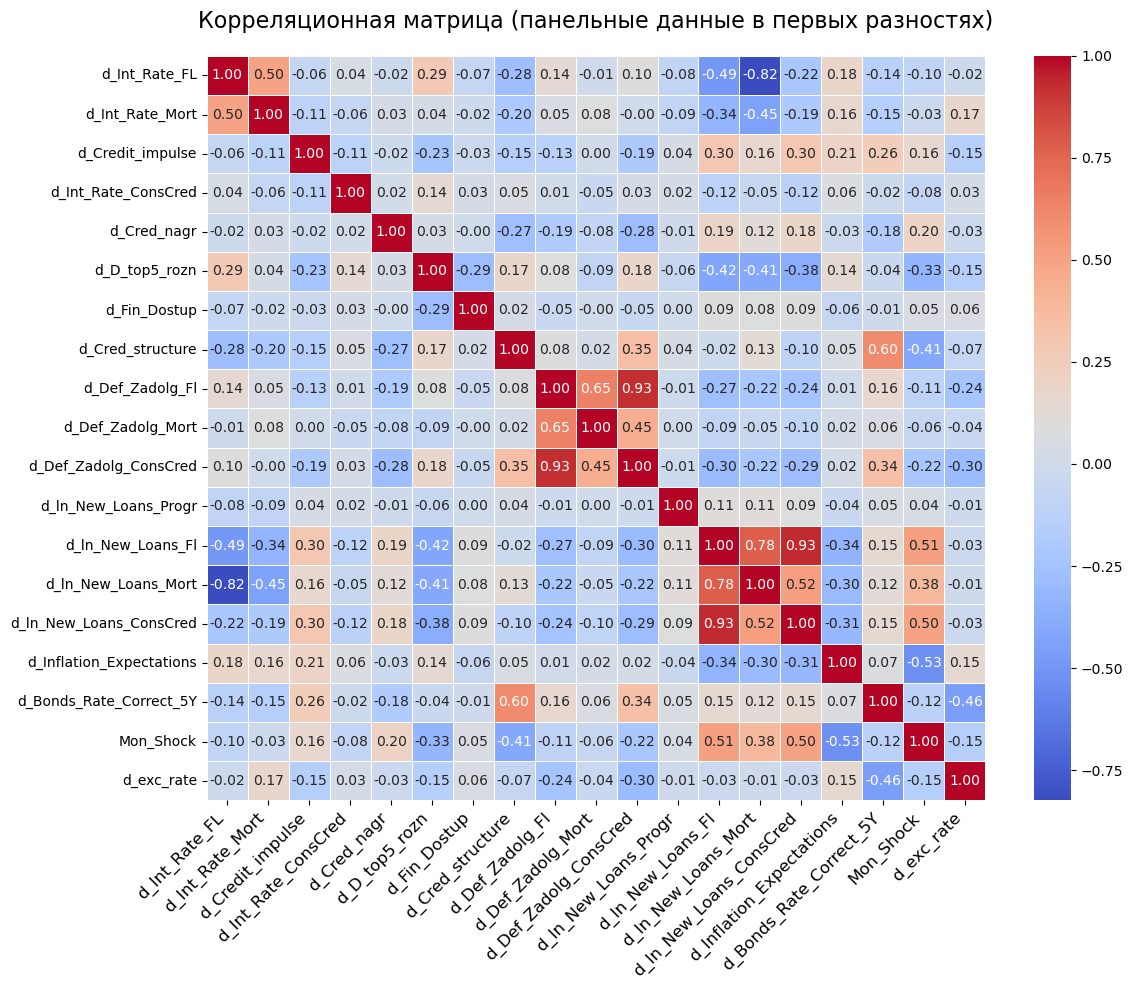

In [619]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [620]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 1 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1',
    'd_Cred_nagr',
    'd_D_top5_rozn',
    'd_Fin_Dostup',
    'd_Credit_impulse',
    'd_Cred_structure',
    'd_Def_Zadolg_Fl',
    'd_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_Fl',
    'd_Bonds_Rate_Correct_5Y',
    'd_exc_rate',
    'd_Inflation_Expectations'                   
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 1")
print("="*60) 
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 1
                Variable      VIF
 d_Bonds_Rate_Correct_5Y 3.046422
        d_Cred_structure 2.654205
               Mon_Shock 2.635512
       d_ln_New_Loans_Fl 2.070891
d_Inflation_Expectations 1.767515
              d_exc_rate 1.738926
        d_Credit_impulse 1.622725
           d_D_top5_rozn 1.584259
      d_Int_Rate_FL_lag1 1.294720
         d_Def_Zadolg_Fl 1.254622
             d_Cred_nagr 1.231555
            d_Fin_Dostup 1.116418
    d_ln_New_Loans_Progr 1.015433


In [621]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 2 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1',
    'd_Cred_nagr',
    'd_D_top5_rozn',
    'd_Fin_Dostup',
    'd_Credit_impulse',
    'd_Cred_structure',
    'd_Def_Zadolg_ConsCred',
    'd_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_ConsCred',
    'd_Bonds_Rate_Correct_5Y',
    'd_exc_rate',
    'd_Inflation_Expectations'                   
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 2")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 2
                Variable      VIF
 d_Bonds_Rate_Correct_5Y 3.054857
        d_Cred_structure 2.551606
               Mon_Shock 2.245521
 d_ln_New_Loans_ConsCred 1.829463
              d_exc_rate 1.798179
d_Inflation_Expectations 1.796522
        d_Credit_impulse 1.603217
   d_Def_Zadolg_ConsCred 1.509887
           d_D_top5_rozn 1.504902
             d_Cred_nagr 1.230463
            d_Fin_Dostup 1.114090
d_Int_Rate_ConsCred_lag1 1.087433
    d_ln_New_Loans_Progr 1.015551


In [622]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 3 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1',
    'd_Cred_nagr',
    'd_D_top5_rozn',
    'd_Fin_Dostup',
    'd_Credit_impulse',
    'd_Cred_structure',
    'd_Def_Zadolg_Mort',
    'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y',
    'd_exc_rate',
    'd_Inflation_Expectations'                     
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 3")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 3
                Variable      VIF
        d_Cred_structure 2.940942
 d_Bonds_Rate_Correct_5Y 2.895087
               Mon_Shock 2.290127
d_Inflation_Expectations 1.774337
           d_D_top5_rozn 1.699169
     d_ln_New_Loans_Mort 1.694787
              d_exc_rate 1.688079
        d_Credit_impulse 1.526845
             d_Cred_nagr 1.181128
            d_Fin_Dostup 1.117563
    d_Int_Rate_Mort_lag1 1.114715
       d_Def_Zadolg_Mort 1.030933
    d_ln_New_Loans_Progr 1.015466


In [385]:
###############################
    #Анализ стационарности панельных данных в первых разностях
###############################
def safe_decode_output(x):
    if isinstance(x, bytes):
        for encoding in ['utf-8', 'windows-1251', 'cp1252', 'latin-1']:
            try:
                return x.decode(encoding)
            except:
                continue
        return x.decode('utf-8', errors='replace')
    return x

rpy2.rinterface_lib.callbacks.consolewrite_print = safe_decode_output
rpy2.rinterface_lib.callbacks.consolewrite_warnerror = safe_decode_output

robjects.r('''
    options(encoding = "UTF-8")
    Sys.setenv(LANG = "en_US.UTF-8")
''')

base_converter = robjects.default_converter + pandas2ri.converter

# === ПЕРЕДАЧА ДАННЫХ В R ===
with localconverter(base_converter):
    r_from_pd_df = robjects.conversion.py2rpy(df_exog)

globalenv['r_from_pd_df'] = r_from_pd_df

utils = importr('utils')

# Установка необходимых пакетов
robjects.r('''
packages <- c('plm', 'urca', 'lmtest', 'sandwich', 'tseries')
for (pkg in packages) {
  if (!require(pkg, character.only = TRUE)) {
    install.packages(pkg)
  }
}
''')

plm = importr('plm')
tseries = importr('tseries')

# === ПОЛУЧЕНИЕ ПЕРЕМЕННЫХ ===
panel_vars = [col for col in df_exog.columns if col not in ['Date', 'Region', 'Mon_Shock', 'd_Int_Rate_FL_lag1', 'd_Int_Rate_Mort_lag1', 'd_Int_Rate_ConsCred_lag1']]
print(f"Testing {len(panel_vars)} variables for unit roots in first differences")
print("="*70)

# Выводим список переменных для проверки
print("Variables to test:", panel_vars)

panel_vars_r = 'c({})'.format(', '.join(f'"{v}"' for v in panel_vars))

# === ПРОВЕДЕНИЕ ТЕСТОВ (с PP и DF-GLS) ===
robjects.r(f'''
library(plm)
library(urca)
library(tseries)

pdf <- pdata.frame(r_from_pd_df, index = c("Region", "Date"))
panel_vars <- {panel_vars_r}

results_df <- data.frame(
  Variable = character(),
  Hadri_Test_Stat = numeric(),
  Hadri_PValue = numeric(),
  PP_Individual_Mean = numeric(),
  PP_Individual_Median = numeric(),
  PP_Rejections = numeric(),
  DFGLS_Individual_Mean = numeric(),
  DFGLS_Individual_Median = numeric(),
  DFGLS_Rejections = numeric(),
  stringsAsFactors = FALSE
)

for (var in panel_vars) {{
  
  cat("\\nTesting variable:", var, "\\n")
  
  tryCatch({{
    x <- pdf[[var]]
    x_clean <- na.omit(x)
    
    if (length(x_clean) > 10) {{
      
      cat("Observations:", length(x_clean), "\\n")
      
      # Hadri тест (панельный тест на стационарность)
      # Для первых разностей используем модель без тренда (only intercept)
      hadri_stat <- NA
      hadri_pval <- NA
      tryCatch({{
        # Для первых разностей используем exo = "intercept" (без тренда)
        hadri_res <- purtest(x_clean, exo = "intercept", test = "hadri")
        hadri_stat <- as.numeric(hadri_res$statistic$statistic)
        hadri_pval <- as.numeric(hadri_res$statistic$p.value)
        cat("Hadri test: statistic =", hadri_stat, "p-value =", hadri_pval, "\\n")
      }}, error = function(e) {{
        cat("Hadri test error for", var, ":", e$message, "\\n")
      }})
      
      # PP тест по регионам (Phillips-Perron)
      pp_stats <- c()
      pp_pvalues <- c()
      pp_rejections <- 0
      regions <- unique(pdf$Region)
      regions_tested_pp <- 0
      
      cat("Regions to test for PP:", length(regions), "\\n")
      
      for (region in regions) {{
        region_data <- pdf[pdf$Region == region, var]
        region_data <- na.omit(as.numeric(region_data))
        
        if (length(region_data) > 5) {{  # минимум 5 наблюдений
          tryCatch({{
            # PP тест для первых разностей: используем type="trend" или "drift" в зависимости от данных
            # Для первых разностей обычно достаточно константы (type="constant")
            pp_test <- pp.test(region_data)
            pp_stat <- pp_test$statistic
            pp_pval <- pp_test$p.value
            
            pp_stats <- c(pp_stats, pp_stat)
            pp_pvalues <- c(pp_pvalues, pp_pval)
            regions_tested_pp <- regions_tested_pp + 1
            
            # Считаем отвержения H0 (единичный корень) на уровне 5%
            if (pp_pval < 0.05) {{
              pp_rejections <- pp_rejections + 1
            }}
          }}, error = function(e) {{
            # Бесшумно пропускаем ошибки для отдельных регионов
          }})
        }}
      }}
      
      cat("PP test: regions tested =", regions_tested_pp, "rejections =", pp_rejections, "\\n")
      
      # DF-GLS тест по регионам
      dfgls_stats <- c()
      dfgls_rejections <- 0
      regions_tested_dfgls <- 0
      
      for (region in regions) {{
        region_data <- pdf[pdf$Region == region, var]
        region_data <- na.omit(as.numeric(region_data))
        
        if (length(region_data) > 5) {{  # минимум 5 наблюдений
          tryCatch({{
            # Используем ur.ers для DF-GLS
            # Для первых разностей используем model = "constant" (константа без тренда)
            max_lags <- min(4, floor(length(region_data)/3))
            dfgls_test <- ur.ers(region_data, 
                               type = "DF-GLS", 
                               model = "constant",
                               lag.max = max_lags)
            
            if (!is.null(dfgls_test@teststat) && length(dfgls_test@teststat) > 0) {{
              dfgls_stat <- dfgls_test@teststat[1]
              dfgls_stats <- c(dfgls_stats, dfgls_stat)
              regions_tested_dfgls <- regions_tested_dfgls + 1
              
              # Считаем отвержения H0 (единичный корень) на уровне 5%
              # Критическое значение -2.86 для 5% уровня для модели с константой
              if (dfgls_stat < -2.86) {{
                dfgls_rejections <- dfgls_rejections + 1
              }}
            }}
          }}, error = function(e) {{
            # Бесшумно пропускаем ошибки для отдельных регионов
          }})
        }}
      }}
      
      cat("DF-GLS test: regions tested =", regions_tested_dfgls, "rejections =", dfgls_rejections, "\\n")
      
      # Вычисляем агрегированные статистики
      pp_mean <- NA
      pp_median <- NA
      pp_rejection_rate <- NA
      
      if (length(pp_stats) > 0) {{
        pp_mean <- mean(pp_stats, na.rm = TRUE)
        pp_median <- median(pp_stats, na.rm = TRUE)
        pp_rejection_rate <- (pp_rejections / length(pp_stats)) * 100
      }}
      
      dfgls_mean <- NA
      dfgls_median <- NA
      dfgls_rejection_rate <- NA
      
      if (length(dfgls_stats) > 0) {{
        dfgls_mean <- mean(dfgls_stats, na.rm = TRUE)
        dfgls_median <- median(dfgls_stats, na.rm = TRUE)
        dfgls_rejection_rate <- (dfgls_rejections / length(dfgls_stats)) * 100
      }}
      
      # Добавляем результаты
      new_row <- data.frame(
        Variable = var,
        Hadri_Test_Stat = hadri_stat,
        Hadri_PValue = hadri_pval,
        PP_Individual_Mean = pp_mean,
        PP_Individual_Median = pp_median,
        PP_Rejections = pp_rejection_rate,
        DFGLS_Individual_Mean = dfgls_mean,
        DFGLS_Individual_Median = dfgls_median,
        DFGLS_Rejections = dfgls_rejection_rate,
        stringsAsFactors = FALSE
      )
      
      results_df <- rbind(results_df, new_row)
      
    }} else {{
      cat("Skipping", var, "- insufficient observations:", length(x_clean), "\\n")
    }}
  }}, error = function(e) {{
    cat("General error for", var, ":", e$message, "\\n")
  }})
}}

write.csv(results_df, "panel_unit_root_tests_first_diff.csv", row.names = FALSE)
cat("\\nResults:\\n")
print(results_df)
''')

# Читаем результаты
results = pd.read_csv("panel_unit_root_tests_first_diff.csv")

print("\n" + "="*70)
print("PANEL UNIT ROOT TEST RESULTS FOR FIRST DIFFERENCES (Hadri + PP + DF-GLS)")
print("="*70)

# Интерпретация результатов для первых разностей
# Для первых разностей мы ожидаем стационарность, поэтому:
# 1. Hadri: H0 - все серии стационарны (p-value >= 0.05 - стационарны)
# 2. PP: H0 - есть единичный корень (p-value < 0.05 - стационарны)
# 3. DF-GLS: статистика < -2.86 - стационарны

results['Hadri_Stationary'] = results['Hadri_PValue'] >= 0.05  # H0: все серии стационарны
# Для PP и DF-GLS используем порог 50% регионов стационарны
results['PP_Stationary'] = results['PP_Rejections'] >= 50  # Более 50% регионов стационарны
results['DFGLS_Stationary'] = results['DFGLS_Rejections'] >= 50  # Более 50% регионов стационарны

# Добавляем общее решение по большинству тестов
results['Overall_Stationary'] = (
    (results['Hadri_Stationary'].astype(int) + 
     results['PP_Stationary'].astype(int) + 
     results['DFGLS_Stationary'].astype(int)) >= 2
)

# Добавляем информацию о том, пройдена ли стационарность в первых разностях
results['I(1)_Becomes_I(0)'] = results['Overall_Stationary']

print(results.to_string(index=False))

print("\n" + "="*70)
print("SUMMARY - FIRST DIFFERENCES")
print("="*70)
print(f"Total variables tested: {len(results)}")
print(f"Hadri test (H0: stationary): {results['Hadri_Stationary'].sum()} stationary")
print(f"PP test: {results['PP_Stationary'].sum()} stationary (≥50% regions)")
print(f"DF-GLS test: {results['DFGLS_Stationary'].sum()} stationary (≥50% regions)")
print(f"Overall (≥2 tests): {results['Overall_Stationary'].sum()} stationary")


Testing 18 variables for unit roots in first differences
Variables to test: ['d_Int_Rate_FL', 'd_Int_Rate_Mort', 'd_Credit_impulse', 'd_Int_Rate_ConsCred', 'd_Cred_nagr', 'd_D_top5_rozn', 'd_Fin_Dostup', 'd_Cred_structure', 'd_Def_Zadolg_Fl', 'd_Def_Zadolg_Mort', 'd_Def_Zadolg_ConsCred', 'd_ln_New_Loans_Progr', 'd_ln_New_Loans_Fl', 'd_ln_New_Loans_Mort', 'd_ln_New_Loans_ConsCred', 'd_Inflation_Expectations', 'd_Bonds_Rate_Correct_5Y', 'd_exc_rate']

PANEL UNIT ROOT TEST RESULTS FOR FIRST DIFFERENCES (Hadri + PP + DF-GLS)
                Variable  Hadri_Test_Stat  Hadri_PValue  PP_Individual_Mean  PP_Individual_Median  PP_Rejections  DFGLS_Individual_Mean  DFGLS_Individual_Median  DFGLS_Rejections  Hadri_Stationary  PP_Stationary  DFGLS_Stationary  Overall_Stationary  I(1)_Becomes_I(0)
           d_Int_Rate_FL        -6.180018  1.000000e+00          -22.116782            -22.239618      94.117647              -2.288850                -2.156149         18.823529              True        

In [386]:
df_exog.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1530 entries, 61 to 6882
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Region                    1530 non-null   object        
 1   Date                      1530 non-null   datetime64[ns]
 2   d_Int_Rate_FL             1530 non-null   float64       
 3   d_Int_Rate_FL_lag1        1530 non-null   float64       
 4   d_Int_Rate_Mort           1530 non-null   float64       
 5   d_Credit_impulse          1530 non-null   float64       
 6   d_Int_Rate_Mort_lag1      1530 non-null   float64       
 7   d_Int_Rate_ConsCred       1530 non-null   float64       
 8   d_Int_Rate_ConsCred_lag1  1530 non-null   float64       
 9   d_Cred_nagr               1530 non-null   float64       
 10  d_D_top5_rozn             1530 non-null   float64       
 11  d_Fin_Dostup              1530 non-null   float64       
 12  d_Cred_structure        

In [387]:
###############################
# Построение линейных моделей на панельных данных
# (d_Int_Rate_FL зависимая переменная)
###############################

print("="*70)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE")
print("Зависимая переменная: d_Int_Rate_FL")
print("="*70)

exog_vars_initial = [
    'd_Int_Rate_FL_lag1',
    'd_Cred_nagr',
    'd_D_top5_rozn',
    'd_Fin_Dostup',
    'd_Credit_impulse',
    'd_Cred_structure',
    'd_Def_Zadolg_Fl',
    'd_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_Fl',
    'd_Bonds_Rate_Correct_5Y',
    'd_exc_rate',
    'd_Inflation_Expectations'                          
]

dependent_var = 'd_Int_Rate_FL'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ: POOL + FE + RE
Зависимая переменная: d_Int_Rate_FL

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:          d_Int_Rate_FL   R-squared:                        0.4651
Estimator:                  PooledOLS   R-squared (Between):             -4.4135
No. Observations:                1530   R-squared (Within):               0.4728
Date:                 Ср, дек 10 2025   R-squared (Overall):              0.4651
Time:                        15:31:45   Log-likelihood                   -2631.4
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      101.45
Entities:                          85   P-value                           0.0000
Avg Obs:                       18.000   Distribution:                 F(13,1517)
Min Obs:                       18.000                                           
Max Obs:       

In [388]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 1.1213
p-значение: 0.999992
df: 13

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 784.2259
p-значение: 0.000000
N (регионов): 85, T (периодов): 18

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -0.0372
p-значение: 1.000000
df: (84, 1432)

Вывод: p >= 0.05 - Pooled адекватна


In [389]:
###############################
# Построение линейных моделей на панельных данных
# (d_Int_Rate_ConsCred зависимая переменная)
###############################

print("="*60)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ POOL + КЛАСТЕРИЗОВАННЫЕ SE; ЗАВИСИМАЯ ПЕРЕМЕННАЯ d_Int_Rate_ConsCred")
print("="*60)

exog_vars_initial = [
    'd_Int_Rate_ConsCred_lag1',
    'd_Cred_nagr',
    'd_D_top5_rozn',
    'd_Fin_Dostup',
    'd_Credit_impulse',
    'd_Cred_structure',
    'd_Def_Zadolg_ConsCred',
    'd_ln_New_Loans_Progr',
    'Mon_Shock',
    'd_ln_New_Loans_ConsCred',
    'd_Bonds_Rate_Correct_5Y',
    'd_exc_rate',
    'd_Inflation_Expectations'                          
]

dependent_var = 'd_Int_Rate_ConsCred'

# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ POOL + КЛАСТЕРИЗОВАННЫЕ SE; ЗАВИСИМАЯ ПЕРЕМЕННАЯ d_Int_Rate_ConsCred

МОДЕЛЬ 1: POOLED OLS
                           PooledOLS Estimation Summary                          
Dep. Variable:     d_Int_Rate_ConsCred   R-squared:                        0.1756
Estimator:                   PooledOLS   R-squared (Between):              0.1420
No. Observations:                 1530   R-squared (Within):               0.1762
Date:                  Ср, дек 10 2025   R-squared (Overall):              0.1756
Time:                         15:31:46   Log-likelihood                   -3277.3
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      24.852
Entities:                           85   P-value                           0.0000
Avg Obs:                        18.000   Distribution:                 F(13,1517)
Min Obs:                        18.000                               

In [390]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: -32.9640
p-значение: 1.000000
df: 13

Вывод: p >= 0.05 - Используйте RANDOM EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 779.7964
p-значение: 0.000000
N (регионов): 85, T (периодов): 18

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -0.4020
p-значение: 1.000000
df: (84, 1432)

Вывод: p >= 0.05 - Pooled адекватна


In [391]:
###############################
# Построение линейных моделей на панельных данных
# (d_Int_Rate_Mort зависимая переменная)
###############################

print("="*60)
print("ПАНЕЛЬНАЯ РЕГРЕССИЯ POOL + КЛАСТЕРИЗОВАННЫЕ SE; ЗАВИСИМАЯ ПЕРЕМЕННАЯ d_Int_Rate_Mort")
print("="*60)

exog_vars_initial = [
    'd_Int_Rate_Mort_lag1',
    'd_Cred_nagr',
    'd_D_top5_rozn',
    'd_Fin_Dostup',
    'd_Credit_impulse',
    'd_Cred_structure',
    'd_Def_Zadolg_Mort',
    'd_ln_New_Loans_Progr',
    'd_ln_New_Loans_Mort',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y',
    'd_exc_rate',
    'd_Inflation_Expectations'                        
]

dependent_var = 'd_Int_Rate_Mort'


# Создаем копию df_exog для работы
df_clean = df_exog.copy()

# Приводим df_reg к формату с Region и Date как столбцами
if isinstance(df_reg.index, pd.MultiIndex):
    df_reg_temp = df_reg.reset_index()
else:
    df_reg_temp = df_reg.copy()

# Проверяем наличие зависимой переменной

if dependent_var in df_reg_temp.columns:
    
    # Присоединяем зависимую переменную по Region и Date
    df_clean = df_clean.merge(
        df_reg_temp[['Region', 'Date', dependent_var]],
        on=['Region', 'Date'],
        how='left',
        suffixes=('', '_from_reg')
    )
else:
    print(f"ERROR - {dependent_var} отсутствует в df_reg_temp")

# Проверяем независимые переменные
exog_vars_for_regression = []
for var in exog_vars_initial:
    if var in df_clean.columns:
        exog_vars_for_regression.append(var)
    else:
        print(f"  WARNING: {var} исключена")

# Удаляем NaN
cols_to_check = [dependent_var] + exog_vars_for_regression
df_clean = df_clean.dropna(subset=cols_to_check)


# ===== Установка панельного индекса =====
df_clean = df_clean.set_index(['Region', 'Date']).sort_index()

# ===== Подготовка Y и X =====
y = df_clean[[dependent_var]]
X = df_clean[exog_vars_for_regression]


# ===== POOLED OLS =====
print("\n" + "="*70)
print("МОДЕЛЬ 1: POOLED OLS")
print("="*70)

try:
    pooled_mod = PooledOLS(y, X)
    pooled_res = pooled_mod.fit(cov_type='clustered')
    print(pooled_res.summary)
    pooled_success = True
except Exception as e:
    print(f"ERROR: {e}")
    pooled_success = False

# ===== FIXED EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 2: FIXED EFFECTS (WITHIN)")
print("="*70)

try:
    fe_mod = PanelOLS(y, X, entity_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print(fe_res.summary)
    fe_success = True
except Exception as e:
    print(f"ERROR: {e}")
    fe_success = False

# ===== RANDOM EFFECTS =====
print("\n" + "="*70)
print("МОДЕЛЬ 3: RANDOM EFFECTS")
print("="*70)

try:
    re_mod = RandomEffects(y, X)
    re_res = re_mod.fit(cov_type='clustered')
    print(re_res.summary)
    re_success = True
except Exception as e:
    print(f"ERROR: {e}")
    re_success = False

ПАНЕЛЬНАЯ РЕГРЕССИЯ POOL + КЛАСТЕРИЗОВАННЫЕ SE; ЗАВИСИМАЯ ПЕРЕМЕННАЯ d_Int_Rate_Mort

МОДЕЛЬ 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:        d_Int_Rate_Mort   R-squared:                        0.4701
Estimator:                  PooledOLS   R-squared (Between):             -0.4313
No. Observations:                1530   R-squared (Within):               0.4742
Date:                 Ср, дек 10 2025   R-squared (Overall):              0.4701
Time:                        15:31:46   Log-likelihood                   -1846.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      103.52
Entities:                          85   P-value                           0.0000
Avg Obs:                       18.000   Distribution:                 F(13,1517)
Min Obs:                       18.000                                           
Ma

In [392]:
# ===== ТЕСТЫ СПЕЦИФИКАЦИИ =====
print("\n" + "="*70)
print("ТЕСТЫ СПЕЦИФИКАЦИИ")
print("="*70)

# ТЕСТ ХАУСМАНА
print("\n ТЕСТ ХАУСМАНА (FE vs RE)")
print("-"*70)

if fe_success and re_success:
    try:
        coef_diff = (fe_res.params - re_res.params).dropna()
        
        var_fe = fe_res.cov.loc[coef_diff.index, coef_diff.index]
        var_re = re_res.cov.loc[coef_diff.index, coef_diff.index]
        var_diff = var_fe - var_re
        
        try:
            inv_var_diff = np.linalg.inv(var_diff.values)
        except np.linalg.LinAlgError:
            print("Матрица сингулярна, используется pseudo-inverse")
            inv_var_diff = np.linalg.pinv(var_diff.values)
        
        H = coef_diff.values @ inv_var_diff @ coef_diff.values
        p_val = 1 - chi2.cdf(H, df=len(coef_diff))
        
        print(f"H-статистика: {H:.4f}")
        print(f"p-значение: {p_val:.6f}")
        print(f"df: {len(coef_diff)}")
        
        if p_val < 0.05:
            print("\nВывод: p < 0.05 - Используйте FIXED EFFECTS")
        else:
            print("\nВывод: p >= 0.05 - Используйте RANDOM EFFECTS")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести (требуются обе модели)")

# ТЕСТ БРЕУША-ПАГАНА
print("\n ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)")
print("-"*70)

if re_success and pooled_success:
    try:
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        sigma_u_sq = (u_pooled**2).sum() / len(u_pooled)
        
        regions = df_clean.index.get_level_values('Region').unique()
        N = len(regions)
        T = len(df_clean) // N
        
        sum_mean_u_sq = 0
        for region in regions:
            u_region = u_pooled[df_clean.index.get_level_values('Region') == region]
            mean_u = u_region.mean()
            sum_mean_u_sq += mean_u**2
        
        LM = (N * T**2) / (2 * (T - 1)) * (sum_mean_u_sq / (sigma_u_sq * N) - 1)**2
        p_val_bp = 1 - chi2.cdf(LM, df=1)
        
        print(f"LM статистика: {LM:.4f}")
        print(f"p-значение: {p_val_bp:.6f}")
        print(f"N (регионов): {N}, T (периодов): {T}")
        
        if p_val_bp < 0.05:
            print("\nВывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)")
        else:
            print("\nВывод: p >= 0.05 - Нет эффектов (адекватна Pooled)")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")

# F-ТЕСТ
print("\n F-ТЕСТ (FE vs Pooled)")
print("-"*70)

if fe_success and pooled_success:
    try:
        N = df_clean.index.get_level_values('Region').nunique()
        T = df_clean.index.get_level_values('Date').nunique()
        k = len(exog_vars_for_regression)
        
        u_pooled = (y.values - X.values @ pooled_res.params.values.reshape(-1, 1)).flatten()
        u_fe = (y.values - X.values @ fe_res.params.values.reshape(-1, 1)).flatten()
        
        SSR_pooled = (u_pooled**2).sum()
        SSR_fe = (u_fe**2).sum()
        
        F_stat = ((SSR_pooled - SSR_fe) / (N - 1)) / (SSR_fe / (N*T - N - k))
        p_val_f = 1 - f.cdf(F_stat, N-1, N*T - N - k)
        
        print(f"F-статистика: {F_stat:.4f}")
        print(f"p-значение: {p_val_f:.6f}")
        print(f"df: ({N-1}, {N*T - N - k})")
        
        if p_val_f < 0.05:
            print("\nВывод: p < 0.05 - FE значимо лучше чем Pooled")
        else:
            print("\nВывод: p >= 0.05 - Pooled адекватна")
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("Невозможно провести")


ТЕСТЫ СПЕЦИФИКАЦИИ

 ТЕСТ ХАУСМАНА (FE vs RE)
----------------------------------------------------------------------
H-статистика: 81.0097
p-значение: 0.000000
df: 13

Вывод: p < 0.05 - Используйте FIXED EFFECTS

 ТЕСТ БРЕУША-ПАГАНА (RE vs Pooled)
----------------------------------------------------------------------
LM статистика: 790.1248
p-значение: 0.000000
N (регионов): 85, T (периодов): 18

Вывод: p < 0.05 - Есть региональные эффекты (используй RE или FE)

 F-ТЕСТ (FE vs Pooled)
----------------------------------------------------------------------
F-статистика: -0.2014
p-значение: 1.000000
df: (84, 1432)

Вывод: p >= 0.05 - Pooled адекватна


In [393]:
df_clean.head()

d_Int_Rate_FL  d_Int_Rate_FL_lag1  d_Int_Rate_Mort  \
Region         Date                                                             
Алтайский край 2024-03-01       0.860901            4.267191         0.551442   
               2024-04-01      -1.353041            0.860901        -1.076773   
               2024-05-01      -0.196362           -1.353041         0.246894   
               2024-06-01      -0.255877           -0.196362        -0.174107   
               2024-07-01      -1.219356           -0.255877        -0.767771   

                           d_Credit_impulse  d_Int_Rate_Mort_lag1  \
Region         Date                                                 
Алтайский край 2024-03-01          0.491561              0.781702   
               2024-04-01          0.614382              0.551442   
               2024-05-01          0.425908             -1.076773   
               2024-06-01         -1.313494              0.246894   
               2024-07-01         -1.369732             -0.174107   

                           d_Int_Rate_ConsCred  d_Int_Rate_ConsCred_lag1  \
Region         Date                                                        
Алтайский край 2024-03-01             1.753713                  1.880871   
               2024-04-01            -0.997709                  1.753713   
               2024-05-01            -0.674069                 -0.997709   
               2024-06-01             0.107902                 -0.674069   
               2024-07-01             1.154593                  0.107902   

                           d_Cred_nagr  d_D_top5_rozn  d_Fin_Dostup  ...  \
Region         Date                                                  ...   
Алтайский край 2024-03-01    -0.002550       0.000074      0.016428  ...   
               2024-04-01    -0.002704       0.000975     -0.030923  ...   
               2024-05-01    -0.000099       0.006103     -0.078362  ...   
               2024-06-01     0.000614       0.007612      0.111210  ...   
               2024-07-01     0.003440       0.005607     -0.125907  ...   

                           d_Def_Zadolg_ConsCred  d_ln_New_Loans_Progr  \
Region         Date                                                      
Алтайский край 2024-03-01               0.019172              7.180716   
               2024-04-01              -0.075931             -1.844022   
               2024-05-01              -0.064310              2.307440   
               2024-06-01              -0.007048              0.165691   
               2024-07-01              -0.093610             -1.853943   

                           d_ln_New_Loans_Fl  d_ln_New_Loans_Mort  \
Region         Date                                                 
Алтайский край 2024-03-01           0.122982             0.305700   
               2024-04-01           0.238434             0.321495   
               2024-05-01           0.029192             0.026342   
               2024-06-01           0.093436             0.148337   
               2024-07-01           0.074091             0.339687   

                           d_ln_New_Loans_ConsCred  d_Inflation_Expectations  \
Region         Date                                                            
Алтайский край 2024-03-01                 0.092661                     -0.48   
               2024-04-01                 0.222339                     -0.56   
               2024-05-01                 0.029771                     -0.40   
               2024-06-01                 0.081921                      0.64   
               2024-07-01                 0.005864                      0.10   

                           d_Bonds_Rate_Correct_5Y  Mon_Shock  d_exc_rate  \
Region         Date                                                         
Алтайский край 2024-03-01                 0.198000   0.121941    0.213378   
               2024-04-01                 0.029435   0.022506    1.226933   
               2024-05-01            

In [394]:
###############################
# Построение PVAR S-GMM моделей
###############################
from pydynpd import regression


df_for_gmm = df_clean.reset_index()
df_for_gmm = df_for_gmm.sort_values(['Region', 'Date'])

# System GMM 
           
# Часть 1: зависимая переменная и регрессоры
# Часть 2: спецификация инструментов
# Часть 3: дополнительные опции
command_str_system = (
    'd_Int_Rate_FL L1.d_Int_Rate_FL '
    'd_Cred_nagr d_D_top5_rozn '
    'Mon_Shock d_Bonds_Rate_Correct_5Y d_exc_rate | '
    'gmm(d_Int_Rate_FL, 2:4) '
    'iv(d_Cred_nagr d_D_top5_rozn Mon_Shock d_Bonds_Rate_Correct_5Y d_exc_rate) | '
    'timedumm collapse'
)

try:
    # System GMM оценка
    mydpd_system = regression.abond(command_str_system, df_for_gmm, ['Region', 'Date'])
        
except Exception as e:
    print(f"ERROR в System GMM: {e}")

 Dynamic panel-data estimation, two-step system GMM
 Group variable: Region                           Number of obs = 1360     
 Time variable: Date                              Min obs per group: 16    
 Number of instruments = 26                       Max obs per group: 16    
 Number of groups = 85                            Avg obs per group: 16.00 
+--------------------------+-------------+---------------------+-------------+-----------+-----+
|      d_Int_Rate_FL       |    coef.    | Corrected Std. Err. |      z      |   P>|z|   |     |
+--------------------------+-------------+---------------------+-------------+-----------+-----+
|     L1.d_Int_Rate_FL     |  -0.2116072 |      0.0738501      |  -2.8653618 | 0.0041653 |  ** |
|       d_Cred_nagr        | -11.5534556 |      5.2532745      |  -2.1992865 | 0.0278576 |  *  |
|      d_D_top5_rozn       | -19.0587606 |      13.3108387     |  -1.4318227 | 0.1521946 |     |
|        Mon_Shock         |  -0.5020870 |      0.0366854     